LOGIC

Task: logic
time_horizon: (1000,) [0..100.0]
num scenarios: 8
first 3 u: [array([0., 0., 0.], dtype=float32), array([0., 0., 1.], dtype=float32), array([0., 1., 0.], dtype=float32)]

[run 0] Loaded 30 CRNs from hall_of_fame_2025-11-28 09:21:30.pth
Saved checkpoint: /local0/rossin/git/CRN-GenerativeAI/FINAL_nicolo/LogicCircuit_4s_5r_SIL/LogicCircuit_4s_5r_SIL_run0.pkl
[run 0] Saved trainer checkpoint -> /local0/rossin/git/CRN-GenerativeAI/FINAL_nicolo/LogicCircuit_4s_5r_SIL/LogicCircuit_4s_5r_SIL_run0.pkl
Task: logic
time_horizon: (1000,) [0..100.0]
num scenarios: 8
first 3 u: [array([0., 0., 0.], dtype=float32), array([0., 0., 1.], dtype=float32), array([0., 1., 0.], dtype=float32)]

[run 1] Loaded 30 CRNs from hall_of_fame_2025-12-05 15:58:05.pth
Saved checkpoint: /local0/rossin/git/CRN-GenerativeAI/FINAL_nicolo/LogicCircuit_4s_5r_SIL/LogicCircuit_4s_5r_SIL_run1.pkl
[run 1] Saved trainer checkpoint -> /local0/rossin/git/CRN-GenerativeAI/FINAL_nicolo/LogicCircuit_4s_5r_SIL/LogicCircuit

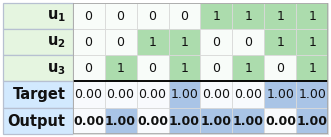


--- Inspecting run 1 ---
Best CRN loss: 0.0023284919994567984
Inputs: ['u_1', 'u_2', 'u_3'] 
Species: ['OUT', 'X_1', 'X_2', 'X_3'] 
Output Species: ['OUT'] 
∅ ----> X_1;  [MAK(1.0, u_1)]
∅ ----> X_2;  [MAK(1.0, u_2)]
∅ ----> X_3;  [MAK(1.0, u_3)]
X_3 ----> OUT + OUT;  [MAK(0.551835834980011)]
X_1 + X_1 ----> OUT + OUT;  [MAK(0.48253002762794495)]
X_1 + X_2 ----> X_2;  [MAK(0.9329349994659424)]
X_3 + X_3 ----> OUT + X_2;  [MAK(0.9226119518280029)]
OUT + OUT ----> ∅;  [MAK(0.4995313882827759)]


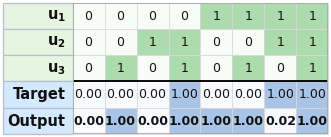

In [17]:
import os
import glob
import json
import torch
import copy
import numpy as np

# IMPORTANT: importing default_tasks ensures TaskKinds (incl. logic) are registered.
from RL4CRN.utils.default_tasks import LogicTaskKind  # noqa: F401

from RL4CRN.utils.input_interface import (
    Configurator,
    make_task,
    make_session_and_trainer,
    print_task_summary,
)
from RL4CRN.utils.crn_builders import build_logic_IOCRN
from RL4CRN.utils.library_builders import build_MAK_library


# -------------------------
# 1) TASK-SPECIFIC SETTINGS (EDIT THESE PER APP)
# -------------------------
target_directory = "/local0/rossin/git/CRN-GenerativeAI/FINAL_nicolo/LogicCircuit_4s_5r_SIL"

preset = "paper"
n_inputs = 3
include_dilution = False
mak_order = 2

t_f = 100
n_t = 1000
ic = ("constant", 0.0)          # set per task
weights = "transient"            # set per task
max_added_reactions = 6
seed = 0

# logic function for THIS app
logic_fn = lambda u: (u[0] and u[1]) or (u[1] and u[2]) 

# optional: stored in meta only
TASK_TAG = "logic"


# -------------------------
# 2) Generic helpers (HoF loading + injection)
# -------------------------
def _extract_crn(obj):
    if hasattr(obj, "state"):
        crn = obj.state
        rew = None
        if hasattr(obj, "reward"):
            rew = getattr(obj, "reward")
        elif hasattr(obj, "perf"):
            rew = getattr(obj, "perf")
        return crn, rew

    if isinstance(obj, tuple) and len(obj) >= 1:
        crn = obj[0]
        rew = obj[1] if len(obj) > 1 else None
        return crn, rew

    if isinstance(obj, dict):
        for k in ["state", "crn", "iocrn"]:
            if k in obj:
                crn = obj[k]
                rew = obj.get("reward", obj.get("perf", None))
                return crn, rew

    return obj, None


def load_old_hof_file(hof_file, map_location="cpu"):
    """Load a SINGLE HoF file into a list of CRNs."""
    data = torch.load(hof_file, map_location=map_location, weights_only=False)
    crns = []
    for entry in data:
        crn, rew = _extract_crn(entry)
        if crn is None:
            continue
        if getattr(crn, "last_task_info", None) is None:
            crn.last_task_info = {}
        if rew is not None:
            crn.last_task_info["reward"] = float(rew)
        crns.append(crn)
    return crns


class _EnvStateWrapper:
    """Minimal wrapper so trainer expects items with `.state` (as in Trainer.load())."""
    def __init__(self, state):
        self.state = state


def _safe_copy_last_task_info(info):
    """
    Best-effort deepcopy of last_task_info:
    - try deepcopy
    - fallback to shallow copy + copy numpy arrays
    """
    if info is None:
        return {}
    try:
        return copy.deepcopy(info)
    except Exception:
        out = dict(info)
        for k, v in list(out.items()):
            if isinstance(v, np.ndarray):
                out[k] = v.copy()
        return out


def inject_hof_into_trainer(trainer, crns, max_size=None):
    """
    Inject CRNs into trainer.s.mult_env.hall_of_fame as env-like items with `.state`,
    while patching required task context into each CRN's last_task_info.
    """
    if max_size is None:
        max_size = int(getattr(trainer.s.cfg.train, "hall_of_fame_size", len(crns)))

    task = trainer.s.task
    u_list_task = task.u_list
    time_horizon_task = task.time_horizon
    logic_fn_task = getattr(task, "logic_fn", None) or (
        task.params.get("logic_fn", None) if hasattr(task, "params") else None
    )

    def loss_of(crn):
        info = getattr(crn, "last_task_info", {}) or {}
        r = info.get("reward", None)
        return float(r) if r is not None else float("inf")

    crns_sorted = sorted(crns, key=loss_of)[:max_size]

    for c in crns_sorted:
        old_info = getattr(c, "last_task_info", None)
        c.last_task_info = _safe_copy_last_task_info(old_info)

        # NEW task context wins (needed for plotting)
        c.last_task_info["u_list"] = u_list_task
        c.last_task_info["time_horizon"] = time_horizon_task
        if logic_fn_task is not None:
            c.last_task_info["logic_fn"] = logic_fn_task
        c.last_task_info["task_kind"] = task.kind

        # keep reward if present somewhere
        if "reward" not in c.last_task_info and old_info is not None:
            try:
                if "reward" in old_info:
                    c.last_task_info["reward"] = float(old_info["reward"])
            except Exception:
                pass

    trainer.s.mult_env.hall_of_fame = [_EnvStateWrapper(c) for c in crns_sorted]


# -------------------------
# 3) Build trainer matching this app/task
# -------------------------
def build_trainer_for_logic_task():
    cfg = Configurator.preset(preset)
    cfg.train.max_added_reactions = max_added_reactions
    cfg.train.epochs = 1
    cfg.train.seed = seed

    crn, species_labels = build_logic_IOCRN(
        n_inputs=n_inputs,
        include_dilution=include_dilution,
        solver=cfg.solver,
    )

    library_components = build_MAK_library(crn, species_labels, order=mak_order)

    task = make_task(
        template_crn=crn,
        library_components=library_components,
        kind="logic",
        species_labels=species_labels,
        params={
            "n_inputs": n_inputs,
            "t_f": t_f,
            "n_t": n_t,
            "ic": ic,
            "weights": weights,
            "logic_fn": logic_fn,
        },
    )

    print_task_summary(task)
    trainer = make_session_and_trainer(cfg, task, logger=None)
    return trainer


# -------------------------
# 4) One-app conversion: ONE trainer per HoF file
# -------------------------
def convert_one_app_many_trainers(target_directory: str):
    hof_dir = os.path.join(target_directory, "hof")
    hof_files = sorted(glob.glob(os.path.join(hof_dir, "hall_of_fame_*.pth")))
    if not hof_files:
        raise FileNotFoundError(f"No HoF files found: {os.path.join(hof_dir, 'hall_of_fame_*.pth')}")

    base = os.path.basename(os.path.normpath(target_directory))
    trainers = []

    for i, hof_file in enumerate(hof_files):
        # Build a fresh trainer per HoF file
        trainer = build_trainer_for_logic_task()

        # Load CRNs from this HoF file only
        crns = load_old_hof_file(hof_file, map_location="cpu")
        print(f"[run {i}] Loaded {len(crns)} CRNs from {os.path.basename(hof_file)}")

        # Inject and save
        inject_hof_into_trainer(trainer, crns, max_size=trainer.s.cfg.train.hall_of_fame_size)

        ckpt_path = os.path.join(target_directory, f"{base}_run{i}.pkl")
        trainer.save(ckpt_path)

        meta = {
            "target_directory": target_directory,
            "hof_file": hof_file,
            "n_loaded_crns": len(crns),
            "task_tag": TASK_TAG,
            "preset": preset,
            "n_inputs": n_inputs,
            "include_dilution": include_dilution,
            "mak_order": mak_order,
            "t_f": t_f,
            "n_t": n_t,
            "ic": ic,
            "weights": weights,
            "max_added_reactions": max_added_reactions,
            "seed": seed,
            "checkpoint_path": ckpt_path,
            "run_index": i,
        }
        with open(os.path.join(target_directory, f"{base}_run{i}.meta.json"), "w") as f:
            json.dump(meta, f, indent=2)

        print(f"[run {i}] Saved trainer checkpoint -> {ckpt_path}")

        trainers.append(trainer)

    return trainers


if __name__ == "__main__":
    trainers = convert_one_app_many_trainers(target_directory)

    # Optional: inspect best from each trainer
    for i, tr in enumerate(trainers):
        print(f"\n--- Inspecting run {i} ---")
        tr.inspect_best(plot=True)

LOGICHF

Task: logic
time_horizon: (1000,) [0..100.0]
num scenarios: 16
first 3 u: [array([0., 0., 0., 0.], dtype=float32), array([0., 0., 0., 1.], dtype=float32), array([0., 0., 1., 0.], dtype=float32)]

[run 0] Loaded 30 CRNs from hall_of_fame_2026-02-17 15:36:48.pth
Saved checkpoint: /local0/rossin/git/CRN-GenerativeAI/apps_results_HF_REINFORCE/logic_4inputs_1output_6species_6rxns/logic_4inputs_1output_6species_6rxns_run0.pkl
[run 0] Saved trainer checkpoint -> /local0/rossin/git/CRN-GenerativeAI/apps_results_HF_REINFORCE/logic_4inputs_1output_6species_6rxns/logic_4inputs_1output_6species_6rxns_run0.pkl

--- Inspecting run 0 ---
Best CRN loss: 0.0011383940233864634
Inputs: ['u_1', 'u_2', 'u_3', 'u_4'] 
Species: ['OUT', 'X_1', 'X_2', 'X_3', 'X_4', 'X_5'] 
Output Species: ['OUT'] 
∅ ----> X_1;  [HILLProd(b = 9.078950711227662e-07, Vm = 1.4107640981674194,    (Ka, na) = X_3(0.005682345945388079, 1);    (Kr, nr) = X_5(0.004884011577814817, 1))]
∅ ----> X_1;  [HILLProd(b = 1.7598452473066573e-07,

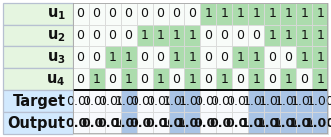

In [18]:
import os
import glob
import json
import torch
import copy
import numpy as np

# IMPORTANT: importing default_tasks ensures TaskKinds (incl. logic) are registered.
from RL4CRN.utils.default_tasks import LogicTaskKind  # noqa: F401

from RL4CRN.utils.input_interface import (
    Configurator,
    make_task,
    make_session_and_trainer,
    print_task_summary,
)

# CRN / library building (HF kinetics)
from RL4CRN.iocrns.iocrn import IOCRN
from RL4CRN.iocrns.reactions import MassAction
from RL4CRN.iocrns.reaction_library import construct_hill_production_library


# -------------------------
# 1) TASK-SPECIFIC SETTINGS (EDIT THESE PER APP)
# -------------------------
target_directory = "/local0/rossin/git/CRN-GenerativeAI/apps_results_HF_REINFORCE/logic_4inputs_1output_6species_6rxns"

preset = "paper"

# HF task specifics
n_inputs = 4
species_labels = [f"X_{i+1}" for i in range(n_inputs)] + ["X_5", "OUT"]  # 6 species total

# solver tolerances from old code
rtol = 1e-6
atol = 1e-6

# training/task knobs
t_f = 100
n_t = 1000
ic = ("constant", 0.01)        # old IC was 0.01 for all species
weights = "steady_state"       # old w was only final timepoint (=> steady_state)
max_added_reactions = 6
seed = 0

# logic function for THIS app (same as old logic_target)
logic_fn = lambda u: (u[0] and u[1]) or (u[1] and u[2]) or (u[2] and u[3])

TASK_TAG = "logic_hf"


# -------------------------
# 2) Generic helpers (HoF loading + injection)
# -------------------------
def _extract_crn(obj):
    if hasattr(obj, "state"):
        crn = obj.state
        rew = None
        if hasattr(obj, "reward"):
            rew = getattr(obj, "reward")
        elif hasattr(obj, "perf"):
            rew = getattr(obj, "perf")
        return crn, rew

    if isinstance(obj, tuple) and len(obj) >= 1:
        crn = obj[0]
        rew = obj[1] if len(obj) > 1 else None
        return crn, rew

    if isinstance(obj, dict):
        for k in ["state", "crn", "iocrn"]:
            if k in obj:
                crn = obj[k]
                rew = obj.get("reward", obj.get("perf", None))
                return crn, rew

    return obj, None


def load_old_hof_file(hof_file, map_location="cpu"):
    """Load a SINGLE HoF file into a list of CRNs."""
    data = torch.load(hof_file, map_location=map_location, weights_only=False)
    crns = []
    for entry in data:
        crn, rew = _extract_crn(entry)
        if crn is None:
            continue
        if getattr(crn, "last_task_info", None) is None:
            crn.last_task_info = {}
        if rew is not None:
            crn.last_task_info["reward"] = float(rew)
        crns.append(crn)
    return crns


class _EnvStateWrapper:
    """Minimal wrapper so trainer expects items with `.state` (as in Trainer.load())."""
    def __init__(self, state):
        self.state = state


def _safe_copy_last_task_info(info):
    """
    Best-effort deepcopy of last_task_info:
    - try deepcopy
    - fallback to shallow copy + copy numpy arrays
    """
    if info is None:
        return {}
    try:
        return copy.deepcopy(info)
    except Exception:
        out = dict(info)
        for k, v in list(out.items()):
            if isinstance(v, np.ndarray):
                out[k] = v.copy()
        return out


def inject_hof_into_trainer(trainer, crns, max_size=None):
    """
    Inject CRNs into trainer.s.mult_env.hall_of_fame as env-like items with `.state`,
    while patching required task context into each CRN's last_task_info.
    """
    if max_size is None:
        max_size = int(getattr(trainer.s.cfg.train, "hall_of_fame_size", len(crns)))

    task = trainer.s.task
    u_list_task = task.u_list
    time_horizon_task = task.time_horizon
    logic_fn_task = getattr(task, "logic_fn", None) or (
        task.params.get("logic_fn", None) if hasattr(task, "params") else None
    )

    def loss_of(crn):
        info = getattr(crn, "last_task_info", {}) or {}
        r = info.get("reward", None)
        return float(r) if r is not None else float("inf")

    crns_sorted = sorted(crns, key=loss_of)[:max_size]

    for c in crns_sorted:
        old_info = getattr(c, "last_task_info", None)
        c.last_task_info = _safe_copy_last_task_info(old_info)

        # NEW task context wins (needed for plotting)
        c.last_task_info["u_list"] = u_list_task
        c.last_task_info["time_horizon"] = time_horizon_task
        if logic_fn_task is not None:
            c.last_task_info["logic_fn"] = logic_fn_task
        c.last_task_info["task_kind"] = task.kind

        # keep reward if present somewhere
        if "reward" not in c.last_task_info and old_info is not None:
            try:
                if "reward" in old_info:
                    c.last_task_info["reward"] = float(old_info["reward"])
            except Exception:
                pass

    trainer.s.mult_env.hall_of_fame = [_EnvStateWrapper(c) for c in crns_sorted]


# -------------------------
# 3) Build HF template + HF library_components
# -------------------------
def build_hf_template_and_library(cfg):
    """
    Recreate your OLD HF setup:
      - template: input-driven productions for X1..X4
      - dilutions for X1..X4 (fixed), plus X5 and OUT (controllable True)
      - hill production library with max_product_order=1, max_num_regulators=2
      - add template reactions + a zero reaction
      - masks dict compatible with new policy builder
    """
    # template reactions
    productions = []
    dilutions = []

    # inputs X1..X4
    input_species = [f"X_{i+1}" for i in range(n_inputs)]
    for i, s in enumerate(input_species):
        productions.append(
            MassAction(
                reactant_labels=[],
                product_labels=[s],
                input_channels=[f"u_{i+1}"],
                params=[1.0],
                params_controllability=[True],
            )
        )
        dilutions.append(
            MassAction(
                reactant_labels=[s],
                product_labels=[],
                input_channels=[None],
                params=[1.0],
                params_controllability=[False],
            )
        )

    # extra species X5 and OUT
    dilutions.append(
        MassAction(
            reactant_labels=["X_5"],
            product_labels=[],
            input_channels=[None],
            params=[1.0],
            params_controllability=[True],
        )
    )
    dilutions.append(
        MassAction(
            reactant_labels=["OUT"],
            product_labels=[],
            input_channels=[None],
            params=[1.0],
            params_controllability=[True],
        )
    )

    crn_template = IOCRN(productions + dilutions, output_labels=["OUT"])
    crn_template.compile()

    # align solver tolerances with your old code
    # (these attributes exist on IOCRN in your old script)
    crn_template.rtol = float(rtol)
    crn_template.atol = float(atol)

    # library
    library = construct_hill_production_library(
        species_labels=species_labels,
        max_product_order=1,
        max_num_regulators=2,
    )
    library.add_reactions(productions + dilutions)

    # zero reaction (∅ -> ∅)
    zero_reaction = MassAction(
        reactant_labels=[],
        product_labels=[],
        input_channels=[None],
        params=[1.0],
        params_controllability=[False],
    )
    library.add_reactions(zero_reaction)

    library.prepare_lookup_tables()
    crn_template.set_library_context(library)

    M = len(library.reactions)
    K = library.get_num_parameters()

    masks = {
        "continuous": library.get_parameter_mask(mode="continuous"),
        "discrete": library.get_parameter_mask(mode="discrete"),
        "logit": library.get_logit_mask(),
    }

    library_components = (library, M, K, masks)
    return crn_template, library_components


# -------------------------
# 4) Build trainer for HF logic task (new interface)
# -------------------------
def build_trainer_for_hf_logic_task():
    cfg = Configurator.preset(preset)

    # Set solver config too (used by some builders; template also gets rtol/atol above)
    cfg.solver.rtol = float(rtol)
    cfg.solver.atol = float(atol)

    # Training knobs needed for wiring
    cfg.train.max_added_reactions = max_added_reactions
    cfg.train.epochs = 1
    cfg.train.seed = seed

    # Build template + library_components (HF)
    crn_template, library_components = build_hf_template_and_library(cfg)

    # Build task (logic)
    task = make_task(
        template_crn=crn_template,
        library_components=library_components,
        kind="logic",
        species_labels=species_labels,
        params={
            "n_inputs": n_inputs,
            "t_f": t_f,
            "n_t": n_t,
            "ic": ic,
            "weights": weights,
            "logic_fn": logic_fn,
            # u_list for logic is auto-generated (0/1 grid) by TaskKind
        },
    )

    print_task_summary(task)
    trainer = make_session_and_trainer(cfg, task, logger=None)
    return trainer


# -------------------------
# 5) Conversion: ONE trainer per HoF file
# -------------------------
def convert_one_app_many_trainers(target_directory: str):
    hof_dir = os.path.join(target_directory, "hof")
    hof_files = sorted(glob.glob(os.path.join(hof_dir, "hall_of_fame_*.pth")))
    if not hof_files:
        raise FileNotFoundError(f"No HoF files found: {os.path.join(hof_dir, 'hall_of_fame_*.pth')}")

    base = os.path.basename(os.path.normpath(target_directory))
    trainers = []

    for i, hof_file in enumerate(hof_files):
        trainer = build_trainer_for_hf_logic_task()

        crns = load_old_hof_file(hof_file, map_location="cpu")
        print(f"[run {i}] Loaded {len(crns)} CRNs from {os.path.basename(hof_file)}")

        inject_hof_into_trainer(trainer, crns, max_size=trainer.s.cfg.train.hall_of_fame_size)

        ckpt_path = os.path.join(target_directory, f"{base}_run{i}.pkl")
        trainer.save(ckpt_path)

        meta = {
            "target_directory": target_directory,
            "hof_file": hof_file,
            "n_loaded_crns": len(crns),
            "task_tag": TASK_TAG,
            "preset": preset,
            "n_inputs": n_inputs,
            "species_labels": species_labels,
            "rtol": rtol,
            "atol": atol,
            "t_f": t_f,
            "n_t": n_t,
            "ic": ic,
            "weights": weights,
            "max_added_reactions": max_added_reactions,
            "seed": seed,
            "checkpoint_path": ckpt_path,
            "run_index": i,
        }
        with open(os.path.join(target_directory, f"{base}_run{i}.meta.json"), "w") as f:
            json.dump(meta, f, indent=2)

        print(f"[run {i}] Saved trainer checkpoint -> {ckpt_path}")
        trainers.append(trainer)

    return trainers


if __name__ == "__main__":
    trainers = convert_one_app_many_trainers(target_directory)

    # Optional: inspect best from each trainer
    for i, tr in enumerate(trainers):
        print(f"\n--- Inspecting run {i} ---")
        tr.inspect_best(plot=True)

RPA

In [ ]:
import os
import glob
import json
import torch
import copy
import numpy as np

from RL4CRN.utils import default_tasks  # noqa: F401
from RL4CRN.utils.default_tasks.TrackingTaskKind import TrackingTaskKind  # noqa: F401

from RL4CRN.utils.input_interface import (
    Configurator,
    make_task,
    make_session_and_trainer,
    print_task_summary,
)

from RL4CRN.utils.crn_builders import build_simple_IOCRN
from RL4CRN.utils.library_builders import build_MAK_library


# -------------------------
# 1) TASK-SPECIFIC SETTINGS
# -------------------------
target_directory = "/local0/rossin/git/CRN-GenerativeAI/apps_results_MAK_REINFORCE/RPA_2species_4rxns"
preset = "paper"

# Template matches old task: Z --(u1)-> ∅, X --(u2)-> ∅, output=X
species_labels = ["X", "Z"]
production_input_map = {}
degradation_input_map = {"Z": "u_1", "X": "u_2"}
dilution_map = {}
output_species = "X"

mak_order = 2

t_f = 100
n_t = 1000
u_values = [0.5, 1.0, 1.5]
ic_spec = ("values", [[0.01, 0.01]])
weights_spec = "transient"
norm = 1
LARGE_NUMBER = 1e4

max_added_reactions = 4
seed = 0

TASK_TAG = "rpa_tracking"

# TrackingTaskKind tutorial style: named arg resolved from input mapping
target = (lambda u_1: u_1)


# -------------------------
# 2) HoF load + safe deepcopy
# -------------------------
def _extract_crn(obj):
    if hasattr(obj, "state"):
        crn = obj.state
        rew = None
        if hasattr(obj, "reward"):
            rew = getattr(obj, "reward")
        elif hasattr(obj, "perf"):
            rew = getattr(obj, "perf")
        return crn, rew

    if isinstance(obj, tuple) and len(obj) >= 1:
        crn = obj[0]
        rew = obj[1] if len(obj) > 1 else None
        return crn, rew

    if isinstance(obj, dict):
        for k in ["state", "crn", "iocrn"]:
            if k in obj:
                crn = obj[k]
                rew = obj.get("reward", obj.get("perf", None))
                return crn, rew

    return obj, None


def load_old_hof_file(hof_file: str, map_location="cpu"):
    data = torch.load(hof_file, map_location=map_location, weights_only=False)
    crns = []
    for entry in data:
        crn, rew = _extract_crn(entry)
        if crn is None:
            continue
        if getattr(crn, "last_task_info", None) is None:
            crn.last_task_info = {}
        if rew is not None:
            crn.last_task_info["reward"] = float(rew)
        crns.append(crn)
    return crns


def _safe_copy_last_task_info(info):
    if info is None:
        return {}
    try:
        return copy.deepcopy(info)
    except Exception:
        out = dict(info)
        for k, v in list(out.items()):
            if isinstance(v, np.ndarray):
                out[k] = v.copy()
        return out


class _EnvStateWrapper:
    """Trainer expects HoF items with `.state` (same as Trainer.load())."""
    def __init__(self, state):
        self.state = state


# -------------------------
# 3) Build trainer (tutorial wiring)
# -------------------------
def build_trainer_for_rpa_task():
    cfg = Configurator.preset(preset)
    cfg.solver.algorithm = "CVODE"
    cfg.solver.rtol = 1e-10
    cfg.solver.atol = 1e-10

    cfg.train.max_added_reactions = max_added_reactions
    cfg.train.epochs = 1
    cfg.train.seed = seed

    crn, species_out = build_simple_IOCRN(
        species=species_labels,
        production_input_map=production_input_map,
        degradation_input_map=degradation_input_map,
        dilution_map=dilution_map,
        output_species=output_species,
        solver=cfg.solver,
    )

    library_components = build_MAK_library(crn, species_out, order=mak_order)

    task = make_task(
        template_crn=crn,
        library_components=library_components,
        kind="tracking",
        species_labels=species_out,
        params={
            "t_f": t_f,
            "n_t": n_t,
            "ic": ic_spec,
            "weights": weights_spec,
            "u_values": u_values,
            "target": target,          # must be callable with named args
            "norm": norm,
            "LARGE_NUMBER": LARGE_NUMBER,
        },
    )

    print_task_summary(task)
    trainer = make_session_and_trainer(cfg, task, logger=None)
    return trainer


# -------------------------
# 4) Patch solver fields on old CRNs (CRITICAL FIX)
# -------------------------
def patch_solver_fields(crns, template_crn):
    """
    Old HoF CRNs may miss attributes expected by current IOCRN.transient_response.
    Copy them from the new template CRN (solver + tolerances).
    """
    solver = getattr(template_crn, "solver", None)
    rtol = getattr(template_crn, "rtol", None)
    atol = getattr(template_crn, "atol", None)

    for c in crns:
        # If missing, add. If present, leave as-is.
        if not hasattr(c, "solver") and solver is not None:
            c.solver = solver
        if not hasattr(c, "rtol") and rtol is not None:
            c.rtol = rtol
        if not hasattr(c, "atol") and atol is not None:
            c.atol = atol


# -------------------------
# 5) Inject HoF, resimulate whole HoF, replace with resimulated CRNs
# -------------------------
def inject_hof(trainer, crns, max_size=None):
    if max_size is None:
        max_size = int(getattr(trainer.s.cfg.train, "hall_of_fame_size", len(crns)))

    task = trainer.s.task
    u_list_task = task.u_list
    time_horizon_task = task.time_horizon

    def loss_of(crn):
        info = getattr(crn, "last_task_info", {}) or {}
        r = info.get("reward", None)
        return float(r) if r is not None else float("inf")

    crns_sorted = sorted(crns, key=loss_of)[:max_size]

    for c in crns_sorted:
        old_info = getattr(c, "last_task_info", None)
        c.last_task_info = _safe_copy_last_task_info(old_info)
        c.last_task_info["u_list"] = u_list_task
        c.last_task_info["time_horizon"] = time_horizon_task
        c.last_task_info["task_kind"] = task.kind
        c.last_task_info["target"] = target

        if "reward" not in c.last_task_info and old_info is not None:
            try:
                if "reward" in old_info:
                    c.last_task_info["reward"] = float(old_info["reward"])
            except Exception:
                pass

    trainer.s.mult_env.hall_of_fame = [_EnvStateWrapper(c) for c in crns_sorted]


def resimulate_whole_hof_and_replace(trainer):
    hof_crns = [item.state for item in trainer.s.mult_env.hall_of_fame]
    if not hof_crns:
        return []

    # >>> CRITICAL: patch old CRNs so transient_response doesn't crash in workers
    patch_solver_fields(hof_crns, trainer.s.task.template_crn)

    task = trainer.s.task

    crns_new = trainer.resimulate(
        hof_crns,
        ic=task.ic_spec,
        weights=task.weights_spec,
        u_list=task.u_list,
    )

    # Ensure resimulated CRNs also carry the context needed for plotting
    wrapped = []
    for c in crns_new:
        if getattr(c, "last_task_info", None) is None:
            c.last_task_info = {}
        c.last_task_info["u_list"] = task.u_list
        c.last_task_info["time_horizon"] = task.time_horizon
        c.last_task_info["task_kind"] = task.kind
        c.last_task_info["target"] = target
        wrapped.append(_EnvStateWrapper(c))

    trainer.s.mult_env.hall_of_fame = wrapped
    return crns_new


# -------------------------
# 6) Convert: one trainer per HoF file, save RESIMULATED HoF into checkpoint
# -------------------------
def convert_one_app_many_trainers(target_directory: str):
    hof_dir = os.path.join(target_directory, "hof")
    hof_files = sorted(glob.glob(os.path.join(hof_dir, "hall_of_fame_*.pth")))
    if not hof_files:
        raise FileNotFoundError(f"No HoF files found: {os.path.join(hof_dir, 'hall_of_fame_*.pth')}")

    base = os.path.basename(os.path.normpath(target_directory))
    trainers = []

    for i, hof_file in enumerate(hof_files):
        trainer = build_trainer_for_rpa_task()

        # load CRNs from this HoF file
        crns = load_old_hof_file(hof_file, map_location="cpu")
        print(f"[run {i}] Loaded {len(crns)} CRNs from {os.path.basename(hof_file)}")

        # inject
        inject_hof(trainer, crns, max_size=trainer.s.cfg.train.hall_of_fame_size)

        # resimulate ALL HoF and replace (so saved trainer has resimulated networks)
        crns_resim = resimulate_whole_hof_and_replace(trainer)
        print(f"[run {i}] Resimulated HoF CRNs: {len(crns_resim)}")

        # save checkpoint (contains resimulated HoF CRNs)
        ckpt_path = os.path.join(target_directory, f"{base}_run{i}.pkl")
        trainer.save(ckpt_path)

        meta = {
            "target_directory": target_directory,
            "hof_file": hof_file,
            "n_loaded_crns": len(crns),
            "n_resimulated_crns": len(crns_resim),
            "task_tag": TASK_TAG,
            "preset": preset,
            "species_labels": species_labels,
            "mak_order": mak_order,
            "t_f": t_f,
            "n_t": n_t,
            "ic": ic_spec,
            "weights": weights_spec,
            "u_values": u_values,
            "max_added_reactions": max_added_reactions,
            "seed": seed,
            "checkpoint_path": ckpt_path,
            "run_index": i,
        }
        with open(os.path.join(target_directory, f"{base}_run{i}.meta.json"), "w") as f:
            json.dump(meta, f, indent=2)

        print(f"[run {i}] Saved trainer checkpoint -> {ckpt_path}")
        trainers.append(trainer)

    return trainers


if __name__ == "__main__":
    trainers = convert_one_app_many_trainers(target_directory)

    # Optional: confirm plots now show trajectories
    import matplotlib.pyplot as plt
    for i, tr in enumerate(trainers):
        print(f"\n--- Inspecting run {i} ---")
        tr.inspect_best(plot=True)
        plt.show()

3 species 5 reactions

Task: tracking
time_horizon: (1000,) [0..100.0]
num scenarios: 9
first 3 u: [array([0.5, 0.5], dtype=float32), array([0.5, 1. ], dtype=float32), array([0.5, 1.5], dtype=float32)]

[run 0] Loaded 30 CRNs from hall_of_fame_2025-11-23 12:31:07.pth
[run 0] Resimulated HoF CRNs: 30
Saved checkpoint: /local0/rossin/git/CRN-GenerativeAI/apps_results_MAK_REINFORCE/RPA_3species_5rxns/RPA_3species_5rxns_run0.pkl
[run 0] Saved trainer checkpoint -> /local0/rossin/git/CRN-GenerativeAI/apps_results_MAK_REINFORCE/RPA_3species_5rxns/RPA_3species_5rxns_run0.pkl
Task: tracking
time_horizon: (1000,) [0..100.0]
num scenarios: 9
first 3 u: [array([0.5, 0.5], dtype=float32), array([0.5, 1. ], dtype=float32), array([0.5, 1.5], dtype=float32)]

[run 1] Loaded 30 CRNs from hall_of_fame_2025-11-23 13:06:31.pth
[run 1] Resimulated HoF CRNs: 30
Saved checkpoint: /local0/rossin/git/CRN-GenerativeAI/apps_results_MAK_REINFORCE/RPA_3species_5rxns/RPA_3species_5rxns_run1.pkl
[run 1] Saved trainer checkpoint -> /local

/local0/rossin/git/CRN-GenerativeAI/RL4CRN/utils/plotting_style.py:120: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(**cfg.get("legend_kwargs", {}))


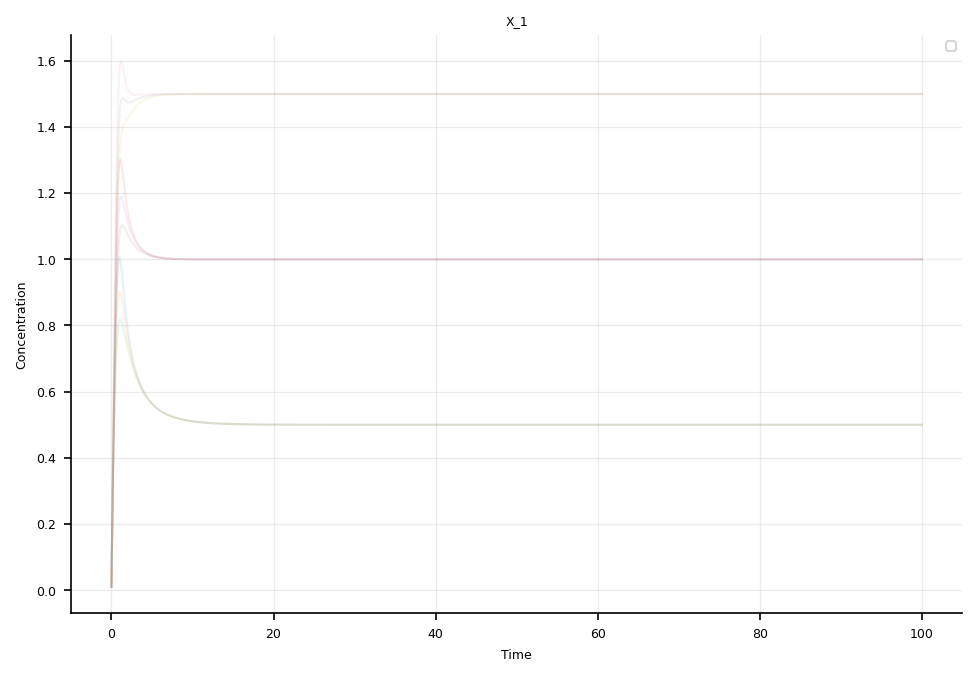


--- Inspecting run 1 ---
Best CRN loss: 0.0046883452227013634
Inputs: ['u_1', 'u_2'] 
Species: ['X_1', 'Z_1', 'Z_2'] 
Output Species: ['X_1'] 
∅ ----> Z_1;  [MAK(1.0, u_1)]
∅ ----> Z_2 + Z_2;  [MAK(1.1269365549087524)]
X_1 ----> ∅;  [MAK(1.0, u_2)]
X_1 ----> Z_2 + Z_2;  [MAK(0.992122232913971)]
Z_1 ----> X_1 + X_1;  [MAK(0.9895129203796387)]
X_1 + Z_2 ----> Z_2 + Z_2;  [MAK(1.143114686012268)]
Z_1 + Z_2 ----> X_1 + Z_1;  [MAK(1.1313401460647583)]


/local0/rossin/git/CRN-GenerativeAI/RL4CRN/utils/plotting_style.py:120: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(**cfg.get("legend_kwargs", {}))


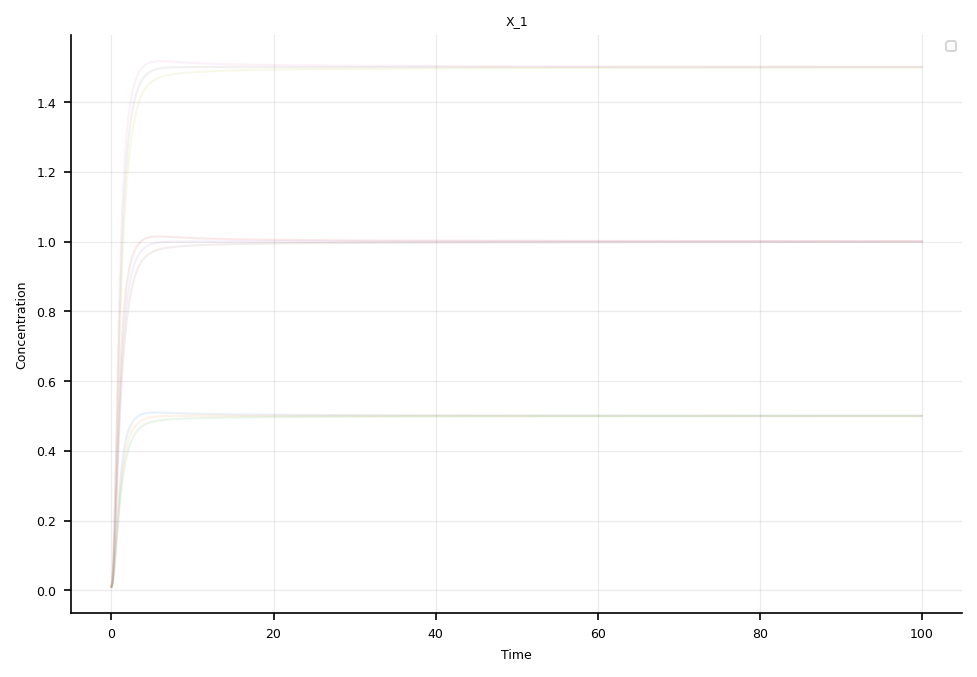


--- Inspecting run 2 ---
Best CRN loss: 0.004804350073941817
Inputs: ['u_1', 'u_2'] 
Species: ['X_1', 'Z_1', 'Z_2'] 
Output Species: ['X_1'] 
∅ ----> Z_1;  [MAK(1.0, u_1)]
∅ ----> Z_2 + Z_2;  [MAK(1.0255188941955566)]
X_1 ----> ∅;  [MAK(1.0, u_2)]
X_1 ----> Z_2 + Z_2;  [MAK(1.0243607759475708)]
Z_1 ----> X_1 + X_1;  [MAK(1.0920090675354004)]
X_1 + Z_2 ----> Z_2 + Z_2;  [MAK(1.029437780380249)]
Z_1 + Z_2 ----> X_1 + Z_1;  [MAK(1.1240376234054565)]


/local0/rossin/git/CRN-GenerativeAI/RL4CRN/utils/plotting_style.py:120: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(**cfg.get("legend_kwargs", {}))


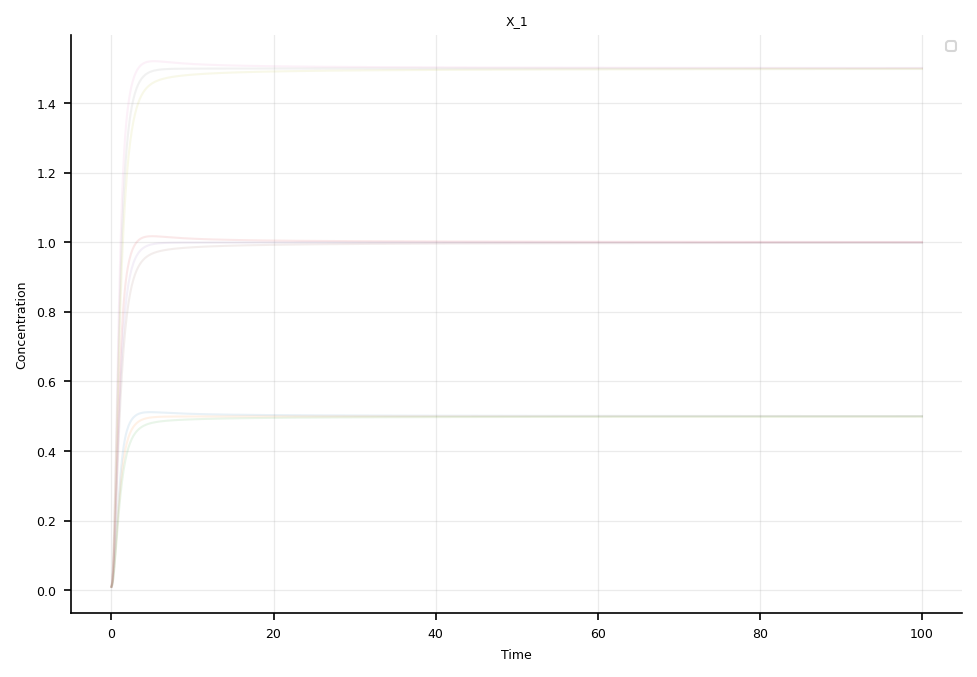

In [31]:
import os
import glob
import json
import torch
import copy
import numpy as np

from RL4CRN.utils import default_tasks  # noqa: F401
from RL4CRN.utils.default_tasks.TrackingTaskKind import TrackingTaskKind  # noqa: F401

from RL4CRN.utils.input_interface import (
    Configurator,
    make_task,
    make_session_and_trainer,
    print_task_summary,
)

from RL4CRN.utils.crn_builders import build_simple_IOCRN
from RL4CRN.utils.library_builders import build_MAK_library


# -------------------------
# 1) TASK-SPECIFIC SETTINGS
# -------------------------
target_directory = "/local0/rossin/git/CRN-GenerativeAI/apps_results_MAK_REINFORCE/RPA_3species_5rxns"
preset = "paper"

# Old-equivalent template:
#   ∅ --(u1)-> Z_1   (production input)
#   X_1 --(u2)-> ∅   (degradation input)
species_labels = ["X_1", "Z_1", "Z_2"]
production_input_map = {"Z_1": "u_1"}
degradation_input_map = {"X_1": "u_2"}
dilution_map = {}
output_species = "X_1"

mak_order = 2

t_f = 100
n_t = 1000
u_values = [0.5, 1.0, 1.5]
ic_spec = ("values", [[0.01, 0.01, 0.01]])  # X_1, Z_1, Z_2
weights_spec = "transient"
norm = 1
LARGE_NUMBER = 1e4

max_added_reactions = 5
seed = 0

TASK_TAG = "rpa_tracking"

# Old: r_list = [u[0]] -> target is u_1
target = (lambda u_1: u_1)


# -------------------------
# 2) HoF load + safe deepcopy
# -------------------------
def _extract_crn(obj):
    if hasattr(obj, "state"):
        crn = obj.state
        rew = None
        if hasattr(obj, "reward"):
            rew = getattr(obj, "reward")
        elif hasattr(obj, "perf"):
            rew = getattr(obj, "perf")
        return crn, rew

    if isinstance(obj, tuple) and len(obj) >= 1:
        crn = obj[0]
        rew = obj[1] if len(obj) > 1 else None
        return crn, rew

    if isinstance(obj, dict):
        for k in ["state", "crn", "iocrn"]:
            if k in obj:
                crn = obj[k]
                rew = obj.get("reward", obj.get("perf", None))
                return crn, rew

    return obj, None


def load_old_hof_file(hof_file: str, map_location="cpu"):
    data = torch.load(hof_file, map_location=map_location, weights_only=False)
    crns = []
    for entry in data:
        crn, rew = _extract_crn(entry)
        if crn is None:
            continue
        if getattr(crn, "last_task_info", None) is None:
            crn.last_task_info = {}
        if rew is not None:
            crn.last_task_info["reward"] = float(rew)
        crns.append(crn)
    return crns


def _safe_copy_last_task_info(info):
    if info is None:
        return {}
    try:
        return copy.deepcopy(info)
    except Exception:
        out = dict(info)
        for k, v in list(out.items()):
            if isinstance(v, np.ndarray):
                out[k] = v.copy()
        return out


class _EnvStateWrapper:
    def __init__(self, state):
        self.state = state


# -------------------------
# 3) Build trainer (tutorial wiring)
# -------------------------
def build_trainer_for_rpa_task():
    cfg = Configurator.preset(preset)
    cfg.solver.algorithm = "CVODE"
    cfg.solver.rtol = 1e-10
    cfg.solver.atol = 1e-10

    cfg.train.max_added_reactions = max_added_reactions
    cfg.train.epochs = 1
    cfg.train.seed = seed

    crn, species_out = build_simple_IOCRN(
        species=species_labels,
        production_input_map=production_input_map,
        degradation_input_map=degradation_input_map,
        dilution_map=dilution_map,
        output_species=output_species,
        solver=cfg.solver,
    )

    library_components = build_MAK_library(crn, species_out, order=mak_order)

    task = make_task(
        template_crn=crn,
        library_components=library_components,
        kind="tracking",
        species_labels=species_out,
        params={
            "t_f": t_f,
            "n_t": n_t,
            "ic": ic_spec,
            "weights": weights_spec,
            "u_values": u_values,
            "target": target,
            "norm": norm,
            "LARGE_NUMBER": LARGE_NUMBER,
        },
    )

    print_task_summary(task)
    trainer = make_session_and_trainer(cfg, task, logger=None)
    return trainer


# -------------------------
# 4) Patch solver fields on old CRNs (CRITICAL FIX)
# -------------------------
def patch_solver_fields(crns, template_crn):
    solver = getattr(template_crn, "solver", None)
    rtol = getattr(template_crn, "rtol", None)
    atol = getattr(template_crn, "atol", None)

    for c in crns:
        if not hasattr(c, "solver") and solver is not None:
            c.solver = solver
        if not hasattr(c, "rtol") and rtol is not None:
            c.rtol = rtol
        if not hasattr(c, "atol") and atol is not None:
            c.atol = atol


# -------------------------
# 5) Inject HoF, resimulate whole HoF, replace with resimulated CRNs
# -------------------------
def inject_hof(trainer, crns, max_size=None):
    if max_size is None:
        max_size = int(getattr(trainer.s.cfg.train, "hall_of_fame_size", len(crns)))

    task = trainer.s.task
    u_list_task = task.u_list
    time_horizon_task = task.time_horizon

    def loss_of(crn):
        info = getattr(crn, "last_task_info", {}) or {}
        r = info.get("reward", None)
        return float(r) if r is not None else float("inf")

    crns_sorted = sorted(crns, key=loss_of)[:max_size]

    for c in crns_sorted:
        old_info = getattr(c, "last_task_info", None)
        c.last_task_info = _safe_copy_last_task_info(old_info)
        c.last_task_info["u_list"] = u_list_task
        c.last_task_info["time_horizon"] = time_horizon_task
        c.last_task_info["task_kind"] = task.kind
        c.last_task_info["target"] = target

        if "reward" not in c.last_task_info and old_info is not None:
            try:
                if "reward" in old_info:
                    c.last_task_info["reward"] = float(old_info["reward"])
            except Exception:
                pass

    trainer.s.mult_env.hall_of_fame = [_EnvStateWrapper(c) for c in crns_sorted]


def resimulate_whole_hof_and_replace(trainer):
    hof_crns = [item.state for item in trainer.s.mult_env.hall_of_fame]
    if not hof_crns:
        return []

    patch_solver_fields(hof_crns, trainer.s.task.template_crn)

    task = trainer.s.task
    crns_new = trainer.resimulate(
        hof_crns,
        ic=task.ic_spec,
        weights=task.weights_spec,
        u_list=task.u_list,
    )

    wrapped = []
    for c in crns_new:
        if getattr(c, "last_task_info", None) is None:
            c.last_task_info = {}
        c.last_task_info["u_list"] = task.u_list
        c.last_task_info["time_horizon"] = task.time_horizon
        c.last_task_info["task_kind"] = task.kind
        c.last_task_info["target"] = target
        wrapped.append(_EnvStateWrapper(c))

    trainer.s.mult_env.hall_of_fame = wrapped
    return crns_new


# -------------------------
# 6) Convert: one trainer per HoF file
# -------------------------
def convert_one_app_many_trainers(target_directory: str):
    hof_dir = os.path.join(target_directory, "hof")
    hof_files = sorted(glob.glob(os.path.join(hof_dir, "hall_of_fame_*.pth")))
    if not hof_files:
        raise FileNotFoundError(f"No HoF files found: {os.path.join(hof_dir, 'hall_of_fame_*.pth')}")

    base = os.path.basename(os.path.normpath(target_directory))
    trainers = []

    for i, hof_file in enumerate(hof_files):
        trainer = build_trainer_for_rpa_task()

        crns = load_old_hof_file(hof_file, map_location="cpu")
        print(f"[run {i}] Loaded {len(crns)} CRNs from {os.path.basename(hof_file)}")

        inject_hof(trainer, crns, max_size=trainer.s.cfg.train.hall_of_fame_size)

        crns_resim = resimulate_whole_hof_and_replace(trainer)
        print(f"[run {i}] Resimulated HoF CRNs: {len(crns_resim)}")

        ckpt_path = os.path.join(target_directory, f"{base}_run{i}.pkl")
        trainer.save(ckpt_path)

        meta = {
            "target_directory": target_directory,
            "hof_file": hof_file,
            "n_loaded_crns": len(crns),
            "n_resimulated_crns": len(crns_resim),
            "task_tag": TASK_TAG,
            "preset": preset,
            "species_labels": species_labels,
            "mak_order": mak_order,
            "t_f": t_f,
            "n_t": n_t,
            "ic": ic_spec,
            "weights": weights_spec,
            "u_values": u_values,
            "max_added_reactions": max_added_reactions,
            "seed": seed,
            "checkpoint_path": ckpt_path,
            "run_index": i,
        }
        with open(os.path.join(target_directory, f"{base}_run{i}.meta.json"), "w") as f:
            json.dump(meta, f, indent=2)

        print(f"[run {i}] Saved trainer checkpoint -> {ckpt_path}")
        trainers.append(trainer)

    return trainers


if __name__ == "__main__":
    trainers = convert_one_app_many_trainers(target_directory)

    # Optional: verify plots
    import matplotlib.pyplot as plt
    for i, tr in enumerate(trainers):
        print(f"\n--- Inspecting run {i} ---")
        tr.inspect_best(plot=True)
        plt.show()

3s 8r

Task: tracking
time_horizon: (1000,) [0..100.0]
num scenarios: 27
first 3 u: [array([0.5, 0.5, 0.5], dtype=float32), array([0.5, 0.5, 1. ], dtype=float32), array([0.5, 0.5, 1.5], dtype=float32)]

[run 0] Loaded 30 CRNs from hall_of_fame_2026-01-10 10:29:01.pth
[run 0] Resimulated HoF CRNs: 30
Saved checkpoint: /local0/rossin/git/CRN-GenerativeAI/apps_results_MAK_REINFORCE/RPA_6species_8rxns/RPA_6species_8rxns_run0.pkl
[run 0] Saved trainer checkpoint -> /local0/rossin/git/CRN-GenerativeAI/apps_results_MAK_REINFORCE/RPA_6species_8rxns/RPA_6species_8rxns_run0.pkl
Task: tracking
time_horizon: (1000,) [0..100.0]
num scenarios: 27
first 3 u: [array([0.5, 0.5, 0.5], dtype=float32), array([0.5, 0.5, 1. ], dtype=float32), array([0.5, 0.5, 1.5], dtype=float32)]

[run 1] Loaded 30 CRNs from hall_of_fame_2026-01-10 17:25:49.pth
[run 1] Resimulated HoF CRNs: 30
Saved checkpoint: /local0/rossin/git/CRN-GenerativeAI/apps_results_MAK_REINFORCE/RPA_6species_8rxns/RPA_6species_8rxns_run1.pkl
[run 1] Sa

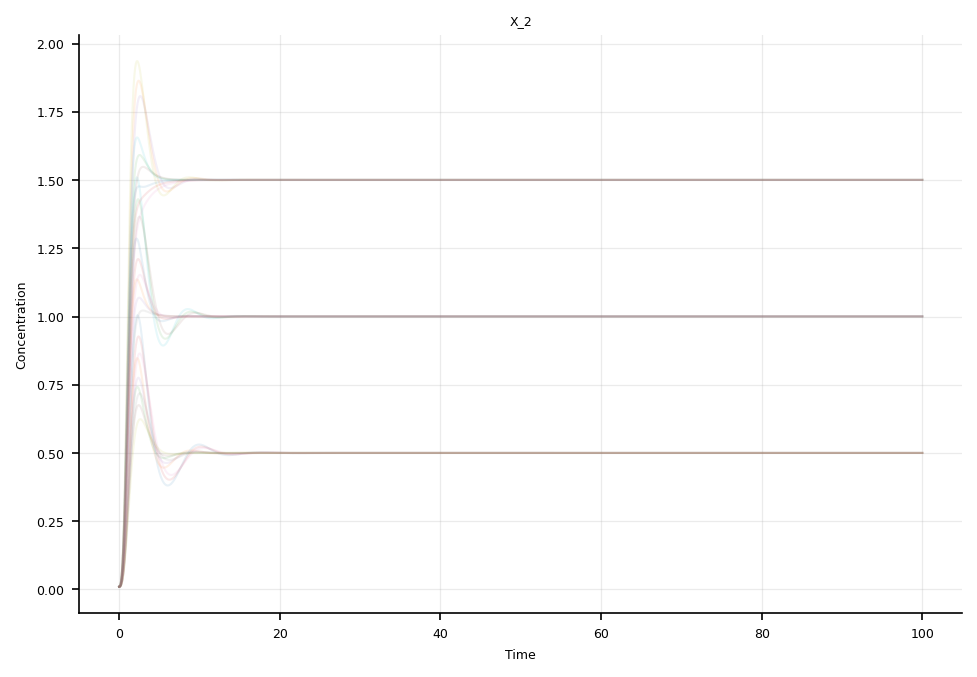


--- Inspecting run 1 ---
Best CRN loss: 0.005333039634042926
Inputs: ['u_1', 'u_2', 'u_3'] 
Species: ['X_1', 'X_2', 'Z_1', 'Z_2', 'Z_3', 'Z_4'] 
Output Species: ['X_2'] 
∅ ----> Z_1;  [MAK(1.0, u_1)]
X_1 ----> ∅;  [MAK(1.0, u_2)]
X_1 ----> X_1 + X_2;  [MAK(1.0)]
X_2 ----> ∅;  [MAK(1.0, u_3)]
X_2 ----> Z_4 + Z_4;  [MAK(0.499813050031662)]
Z_1 ----> X_1 + Z_1;  [MAK(2.5542006492614746)]
Z_2 ----> Z_3 + Z_3;  [MAK(0.2695524990558624)]
X_1 + Z_2 ----> Z_1;  [MAK(0.4784304201602936)]
X_1 + Z_4 ----> Z_4;  [MAK(3.4864890575408936)]
X_1 + Z_4 ----> Z_3 + Z_4;  [MAK(0.48552387952804565)]
Z_1 + Z_4 ----> Z_3;  [MAK(0.5644171237945557)]
Z_3 + Z_3 ----> ∅;  [MAK(0.874573290348053)]


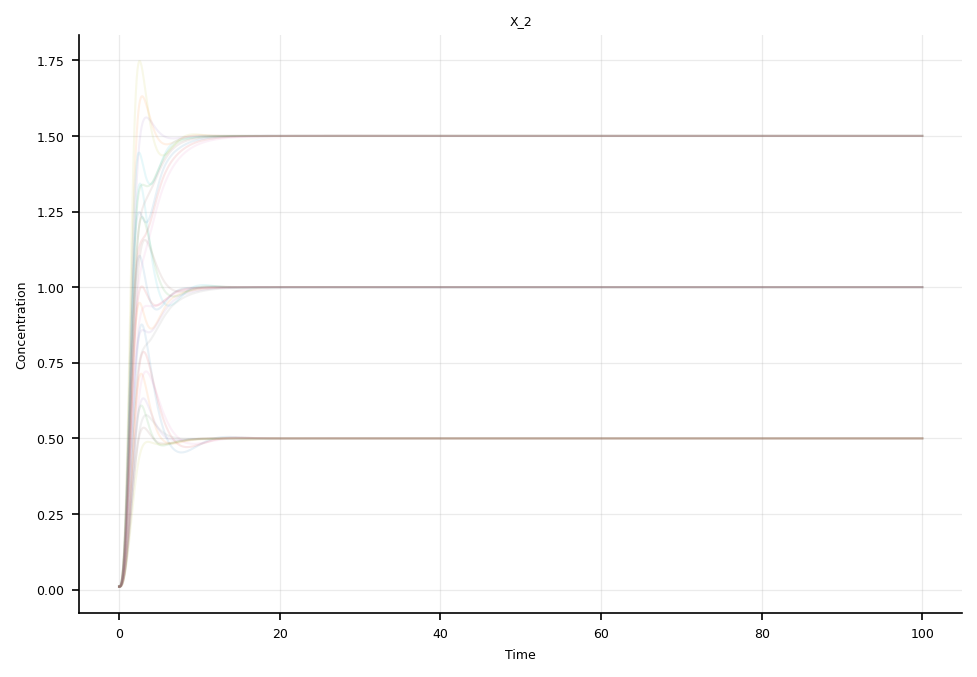


--- Inspecting run 2 ---
Best CRN loss: 0.005875907458490966
Inputs: ['u_1', 'u_2', 'u_3'] 
Species: ['X_1', 'X_2', 'Z_1', 'Z_2', 'Z_3', 'Z_4'] 
Output Species: ['X_2'] 
∅ ----> Z_1;  [MAK(1.0, u_1)]
X_1 ----> ∅;  [MAK(1.0, u_2)]
X_1 ----> X_1 + X_2;  [MAK(1.0)]
X_2 ----> ∅;  [MAK(1.0, u_3)]
X_2 ----> Z_3 + Z_4;  [MAK(1.0004535913467407)]
Z_1 ----> X_1 + Z_1;  [MAK(2.3706483840942383)]
X_1 + X_2 ----> X_2;  [MAK(1.0087286233901978)]
X_1 + Z_3 ----> Z_3;  [MAK(0.9102226495742798)]
Z_1 + Z_3 ----> ∅;  [MAK(1.4076555967330933)]
Z_1 + Z_3 ----> Z_2;  [MAK(0.8045167326927185)]
Z_1 + Z_3 ----> X_1 + X_1;  [MAK(4.376936912536621)]
Z_2 + Z_2 ----> ∅;  [MAK(1.669828176498413)]


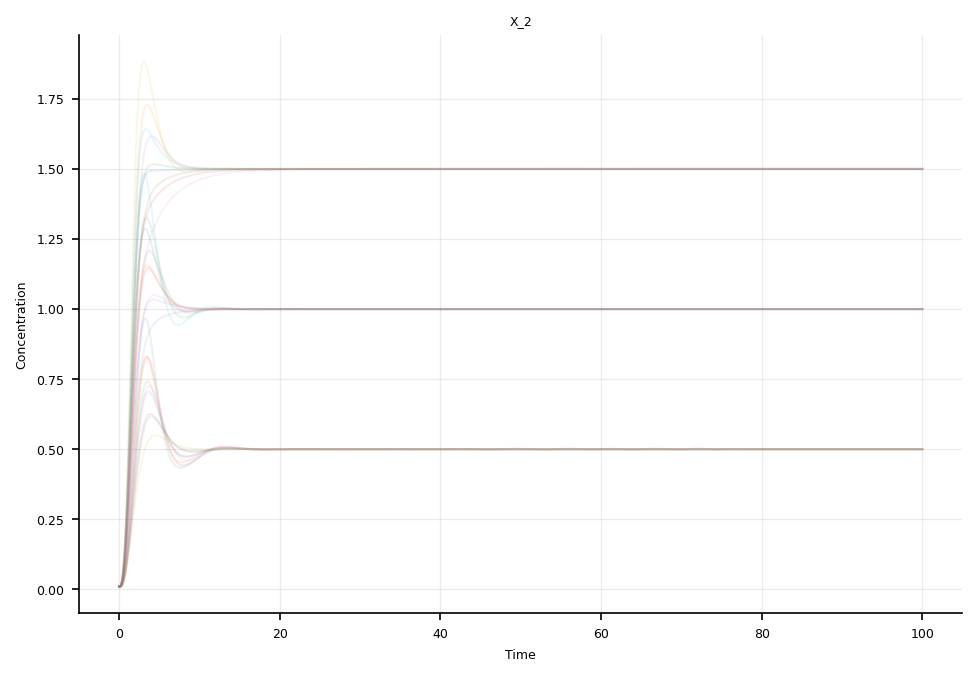

In [33]:
import os
import glob
import json
import torch
import copy
import numpy as np

from RL4CRN.utils import default_tasks  # noqa: F401
from RL4CRN.utils.default_tasks.TrackingTaskKind import TrackingTaskKind  # noqa: F401

from RL4CRN.utils.input_interface import (
    Configurator,
    make_task,
    make_session_and_trainer,
    print_task_summary,
)

from RL4CRN.utils.crn_builders import build_simple_IOCRN
from RL4CRN.utils.library_builders import build_MAK_library


# -------------------------
# 1) TASK-SPECIFIC SETTINGS
# -------------------------
target_directory = "/local0/rossin/git/CRN-GenerativeAI/apps_results_MAK_REINFORCE/RPA_6species_8rxns"
preset = "paper"

# Old template had 3 inputs: u_1, u_2, u_3
species_labels = ["X_1", "X_2", "Z_1", "Z_2", "Z_3", "Z_4"]

production_input_map = {"Z_1": "u_1"}                   # r1
degradation_input_map = {"X_1": "u_2", "X_2": "u_3"}    # r2 and r4 (important!)
dilution_map = {}
output_species = "X_2"

mak_order = 2

t_f = 100
n_t = 1000
u_values = [0.5, 1.0, 1.5]
ic_spec = ("values", [[0.01, 0.01, 0.01, 0.01, 0.01, 0.01]])
weights_spec = "transient"
norm = 1
LARGE_NUMBER = 1e4

max_added_reactions = 8
seed = 0

TASK_TAG = "rpa_tracking"

# target is u_1 (old r_list = [u[0]])
target = (lambda u_1: u_1)

# Reaction pruning list from old run
ids_to_remove = [2, 8, 13, 14, 15, 16, 17, 29, 30, 31, 32, 33, 34, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
51, 52, 53, 54, 56, 61, 63, 64, 65, 66, 67, 84, 89, 94, 95, 96, 97, 98, 111, 116, 121, 122, 123, 124, 125, 138,
143, 148, 149, 150, 151, 152, 165, 170, 175, 176, 177, 178, 179, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199,
200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 218, 220, 221, 222, 223, 224,
225, 226, 227, 228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239, 240, 241, 242, 243, 245, 246, 252, 256,
257, 258, 259, 260, 273, 279, 283, 284, 285, 286, 287, 300, 306, 307, 308, 309, 310, 311, 312, 313, 314, 326, 327,
333, 334, 335, 336, 337, 338, 339, 340, 341, 352, 353, 354, 361, 362, 363, 364, 392, 410, 419, 438, 446, 466, 473,
489, 495, 500, 501, 502, 503, 504, 516, 522, 527, 528, 529, 530, 531, 543, 549, 554, 555, 556, 557, 558, 570, 576,
581, 582, 583, 584, 585, 597, 603, 608, 609, 610, 611, 612, 624, 630, 635, 636, 637, 638, 639, 651, 657, 662, 663,
664, 665, 666, 678, 684, 689, 690, 691, 692, 693, 705, 711, 716, 717, 718, 719, 720, 732, 738, 743, 744, 745, 746, 747]


# -------------------------
# 2) HoF loading + safe deepcopy
# -------------------------
def _extract_crn(obj):
    if hasattr(obj, "state"):
        crn = obj.state
        rew = None
        if hasattr(obj, "reward"):
            rew = getattr(obj, "reward")
        elif hasattr(obj, "perf"):
            rew = getattr(obj, "perf")
        return crn, rew
    if isinstance(obj, tuple) and len(obj) >= 1:
        return obj[0], (obj[1] if len(obj) > 1 else None)
    if isinstance(obj, dict):
        for k in ["state", "crn", "iocrn"]:
            if k in obj:
                return obj[k], obj.get("reward", obj.get("perf", None))
    return obj, None


def load_old_hof_file(hof_file: str, map_location="cpu"):
    data = torch.load(hof_file, map_location=map_location, weights_only=False)
    crns = []
    for entry in data:
        crn, rew = _extract_crn(entry)
        if crn is None:
            continue
        if getattr(crn, "last_task_info", None) is None:
            crn.last_task_info = {}
        if rew is not None:
            crn.last_task_info["reward"] = float(rew)
        crns.append(crn)
    return crns


def _safe_copy_last_task_info(info):
    if info is None:
        return {}
    try:
        return copy.deepcopy(info)
    except Exception:
        out = dict(info)
        for k, v in list(out.items()):
            if isinstance(v, np.ndarray):
                out[k] = v.copy()
        return out


class _EnvStateWrapper:
    def __init__(self, state):
        self.state = state


# -------------------------
# 3) Build trainer (tutorial wiring) + prune library by ID
# -------------------------
def build_trainer_for_rpa_task():
    cfg = Configurator.preset(preset)
    cfg.solver.algorithm = "CVODE"
    cfg.solver.rtol = 1e-10
    cfg.solver.atol = 1e-10

    cfg.train.max_added_reactions = max_added_reactions
    cfg.train.epochs = 1
    cfg.train.seed = seed

    crn, species_out = build_simple_IOCRN(
        species=species_labels,
        production_input_map=production_input_map,
        degradation_input_map=degradation_input_map,
        dilution_map=dilution_map,
        output_species=output_species,
        solver=cfg.solver,
    )

    library_components = build_MAK_library(crn, species_out, order=mak_order)
    library, M, K, masks = library_components

    # prune as old run (best-effort)
    if hasattr(library, "remove_reactions"):
        library.remove_reactions(ids_to_remove, remove_by="ID")
        if hasattr(library, "prepare_lookup_tables"):
            library.prepare_lookup_tables()

    # re-pack (sizes changed)
    M = len(library.reactions)
    K = library.get_num_parameters()
    masks = {
        "continuous": library.get_parameter_mask(mode="continuous"),
        "discrete": library.get_parameter_mask(mode="discrete"),
        "logit": library.get_logit_mask(),
    }
    library_components = (library, M, K, masks)

    task = make_task(
        template_crn=crn,
        library_components=library_components,
        kind="tracking",
        species_labels=species_out,
        params={
            "t_f": t_f,
            "n_t": n_t,
            "ic": ic_spec,
            "weights": weights_spec,
            "u_values": u_values,
            "target": target,
            "norm": norm,
            "LARGE_NUMBER": LARGE_NUMBER,
        },
    )

    print_task_summary(task)
    trainer = make_session_and_trainer(cfg, task, logger=None)
    return trainer


# -------------------------
# 4) Patch solver fields on old CRNs (and keep input indices as-is)
# -------------------------
def patch_solver_fields(crns, template_crn):
    solver = getattr(template_crn, "solver", None)
    rtol = getattr(template_crn, "rtol", None)
    atol = getattr(template_crn, "atol", None)
    for c in crns:
        if not hasattr(c, "solver") and solver is not None:
            c.solver = solver
        if not hasattr(c, "rtol") and rtol is not None:
            c.rtol = rtol
        if not hasattr(c, "atol") and atol is not None:
            c.atol = atol


# -------------------------
# 5) Inject HoF + resimulate whole HoF + replace
# -------------------------
def inject_hof(trainer, crns, max_size=None):
    if max_size is None:
        max_size = int(getattr(trainer.s.cfg.train, "hall_of_fame_size", len(crns)))

    task = trainer.s.task
    u_list_task = task.u_list
    time_horizon_task = task.time_horizon

    def loss_of(crn):
        info = getattr(crn, "last_task_info", {}) or {}
        r = info.get("reward", None)
        return float(r) if r is not None else float("inf")

    crns_sorted = sorted(crns, key=loss_of)[:max_size]

    for c in crns_sorted:
        old_info = getattr(c, "last_task_info", None)
        c.last_task_info = _safe_copy_last_task_info(old_info)
        c.last_task_info["u_list"] = u_list_task
        c.last_task_info["time_horizon"] = time_horizon_task
        c.last_task_info["task_kind"] = task.kind
        c.last_task_info["target"] = target

        if "reward" not in c.last_task_info and old_info is not None:
            try:
                if "reward" in old_info:
                    c.last_task_info["reward"] = float(old_info["reward"])
            except Exception:
                pass

    trainer.s.mult_env.hall_of_fame = [_EnvStateWrapper(c) for c in crns_sorted]


def resimulate_whole_hof_and_replace(trainer):
    hof_crns = [item.state for item in trainer.s.mult_env.hall_of_fame]
    if not hof_crns:
        return []

    patch_solver_fields(hof_crns, trainer.s.task.template_crn)

    task = trainer.s.task
    crns_new = trainer.resimulate(
        hof_crns,
        ic=task.ic_spec,
        weights=task.weights_spec,
        u_list=task.u_list,   # IMPORTANT: u has length 3 now (u1,u2,u3)
    )

    wrapped = []
    for c in crns_new:
        if getattr(c, "last_task_info", None) is None:
            c.last_task_info = {}
        c.last_task_info["u_list"] = task.u_list
        c.last_task_info["time_horizon"] = task.time_horizon
        c.last_task_info["task_kind"] = task.kind
        c.last_task_info["target"] = target
        wrapped.append(_EnvStateWrapper(c))

    trainer.s.mult_env.hall_of_fame = wrapped
    return crns_new


# -------------------------
# 6) Convert: one trainer per HoF file
# -------------------------
def convert_one_app_many_trainers(target_directory: str):
    hof_dir = os.path.join(target_directory, "hof")
    hof_files = sorted(glob.glob(os.path.join(hof_dir, "hall_of_fame_*.pth")))
    if not hof_files:
        raise FileNotFoundError(f"No HoF files found: {os.path.join(hof_dir, 'hall_of_fame_*.pth')}")

    base = os.path.basename(os.path.normpath(target_directory))
    trainers = []

    for i, hof_file in enumerate(hof_files):
        trainer = build_trainer_for_rpa_task()

        crns = load_old_hof_file(hof_file, map_location="cpu")
        print(f"[run {i}] Loaded {len(crns)} CRNs from {os.path.basename(hof_file)}")

        inject_hof(trainer, crns, max_size=trainer.s.cfg.train.hall_of_fame_size)

        crns_resim = resimulate_whole_hof_and_replace(trainer)
        print(f"[run {i}] Resimulated HoF CRNs: {len(crns_resim)}")

        ckpt_path = os.path.join(target_directory, f"{base}_run{i}.pkl")
        trainer.save(ckpt_path)

        meta = {
            "target_directory": target_directory,
            "hof_file": hof_file,
            "n_loaded_crns": len(crns),
            "n_resimulated_crns": len(crns_resim),
            "task_tag": TASK_TAG,
            "preset": preset,
            "species_labels": species_labels,
            "mak_order": mak_order,
            "removed_reaction_ids": ids_to_remove,
            "t_f": t_f,
            "n_t": n_t,
            "ic": ic_spec,
            "weights": weights_spec,
            "u_values": u_values,
            "max_added_reactions": max_added_reactions,
            "seed": seed,
            "checkpoint_path": ckpt_path,
            "run_index": i,
        }
        with open(os.path.join(target_directory, f"{base}_run{i}.meta.json"), "w") as f:
            json.dump(meta, f, indent=2)

        print(f"[run {i}] Saved trainer checkpoint -> {ckpt_path}")
        trainers.append(trainer)

    return trainers


if __name__ == "__main__":
    trainers = convert_one_app_many_trainers(target_directory)

    import matplotlib.pyplot as plt
    for i, tr in enumerate(trainers):
        print(f"\n--- Inspecting run {i} ---")
        tr.inspect_best(plot=True)
        plt.show()

## Tunable freq

Task: oscillator_freq
time_horizon: (1000,) [0..100.0]
num scenarios: 3
first 3 u: [array([0.1], dtype=float32), array([0.06666667], dtype=float32), array([0.05], dtype=float32)]

[run 0] Loaded 30 CRNs from hall_of_fame_2026-01-02 08:55:10.pth

[cvHandleFailure, Error: -15] At t = 55.5664857001741, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 42.6842865517598, unable to satisfy inequality constraints.

[run 0] Resimulated HoF CRNs: 30
Saved checkpoint: /local0/rossin/git/CRN-GenerativeAI/apps_results_MAK_REINFORCE/oscillators_freq_3species_6rxns/oscillators_freq_3species_6rxns_run0.pkl
[run 0] Saved trainer checkpoint -> /local0/rossin/git/CRN-GenerativeAI/apps_results_MAK_REINFORCE/oscillators_freq_3species_6rxns/oscillators_freq_3species_6rxns_run0.pkl
Task: oscillator_freq
time_horizon: (1000,) [0..100.0]
num scenarios: 3
first 3 u: [array([0.1], dtype=float32), array([0.06666667], dtype=float32), array([0.05], dtype=float32)]

[run 1] Loaded 30 

/local0/rossin/git/CRN-GenerativeAI/RL4CRN/utils/plotting_style.py:120: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(**cfg.get("legend_kwargs", {}))
/local0/rossin/git/CRN-GenerativeAI/RL4CRN/utils/plotting_style.py:120: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(**cfg.get("legend_kwargs", {}))


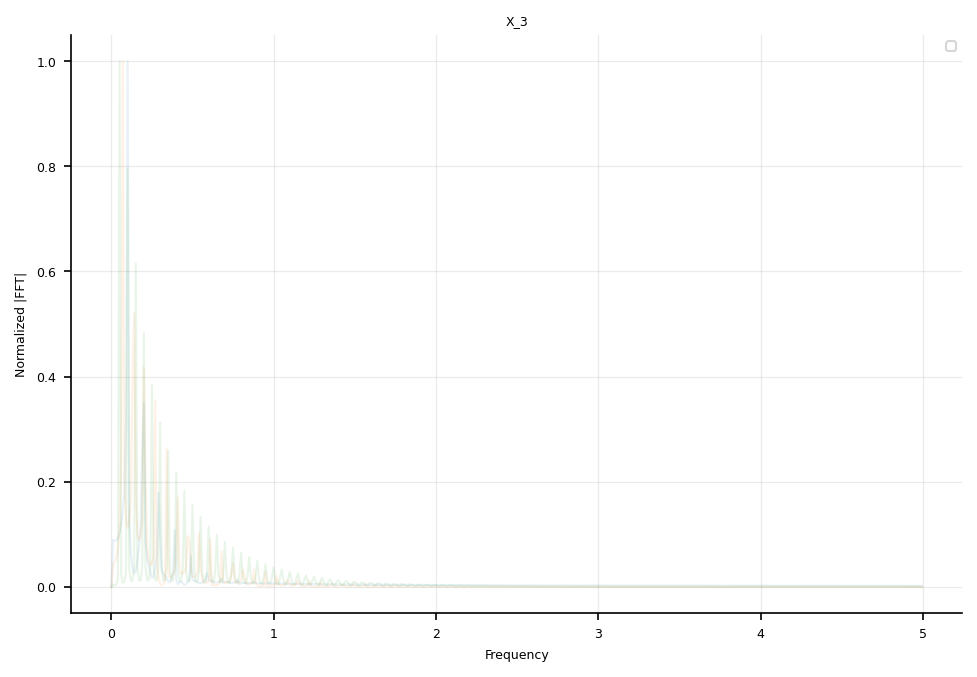

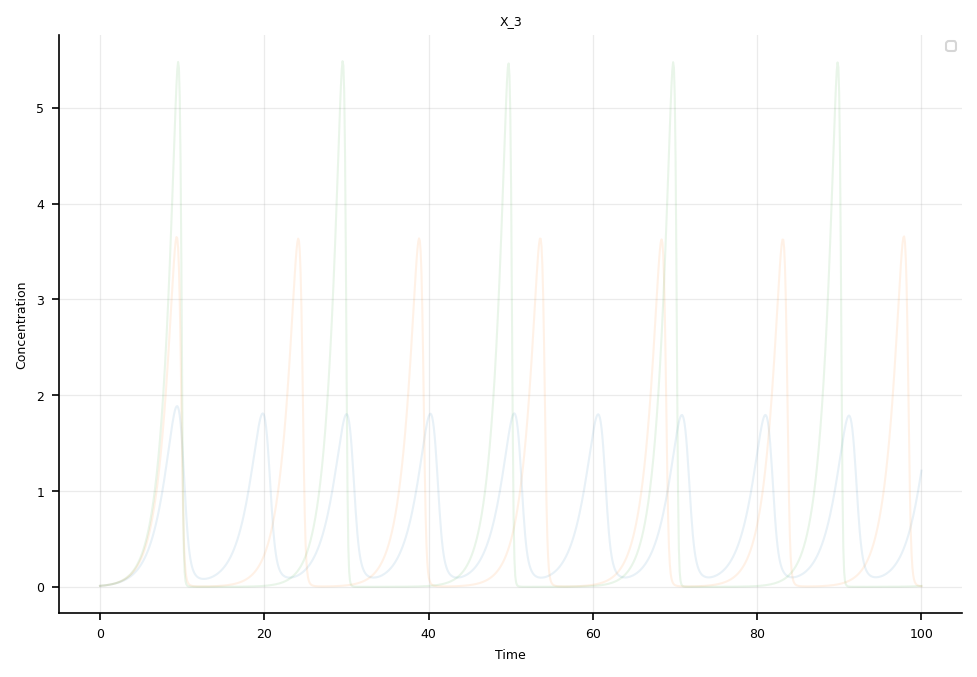


--- Inspecting run 1 ---
Best CRN loss: 0.07284084496291673
Inputs: ['u_1'] 
Species: ['X_1', 'X_2', 'X_3'] 
Output Species: ['X_3'] 
∅ ----> X_1;  [MAK(1.0, u_1)]
X_1 ----> ∅;  [MAK(1.0)]
X_2 ----> ∅;  [MAK(1.0)]
X_2 ----> X_2 + X_2;  [MAK(1.7595248222351074)]
X_3 ----> ∅;  [MAK(1.0)]
X_3 ----> X_2;  [MAK(2.469055414199829)]
X_1 + X_2 ----> X_1;  [MAK(3.030461549758911)]
X_1 + X_2 ----> X_1 + X_3;  [MAK(1.079802393913269)]
X_1 + X_3 ----> X_1 + X_1;  [MAK(2.3508706092834473)]
X_3 + X_3 ----> X_1 + X_3;  [MAK(0.885675847530365)]


/local0/rossin/git/CRN-GenerativeAI/RL4CRN/utils/plotting_style.py:120: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(**cfg.get("legend_kwargs", {}))
/local0/rossin/git/CRN-GenerativeAI/RL4CRN/utils/plotting_style.py:120: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(**cfg.get("legend_kwargs", {}))


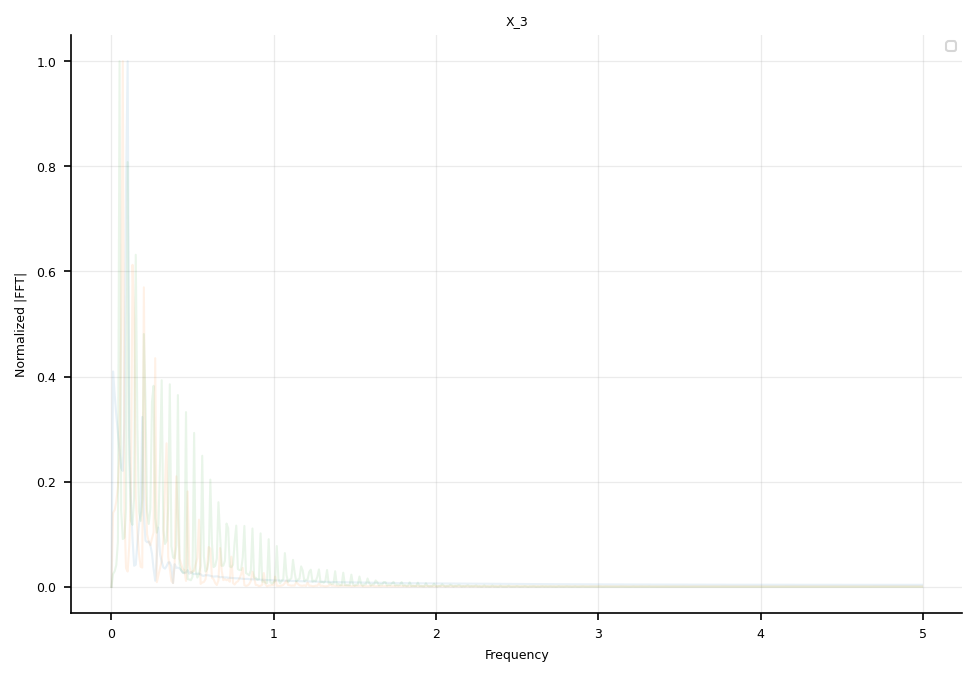

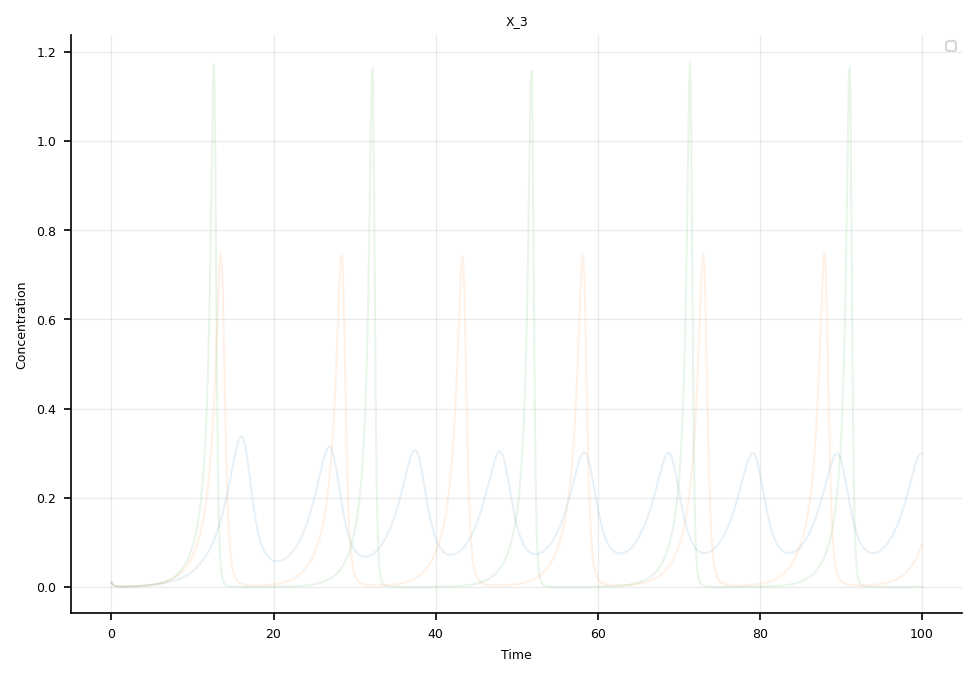


--- Inspecting run 2 ---
Best CRN loss: 0.07006075860415574
Inputs: ['u_1'] 
Species: ['X_1', 'X_2', 'X_3'] 
Output Species: ['X_3'] 
∅ ----> X_1;  [MAK(1.0, u_1)]
X_1 ----> ∅;  [MAK(1.0)]
X_2 ----> ∅;  [MAK(1.0)]
X_3 ----> ∅;  [MAK(1.0)]
X_3 ----> X_1 + X_3;  [MAK(2.5677499771118164)]
X_1 + X_1 ----> X_3 + X_3;  [MAK(3.4985501766204834)]
X_1 + X_2 ----> X_2;  [MAK(2.396301746368408)]
X_1 + X_3 ----> X_1 + X_1;  [MAK(2.9050073623657227)]
X_2 + X_3 ----> X_1 + X_2;  [MAK(3.487663745880127)]
X_2 + X_3 ----> X_2 + X_2;  [MAK(5.738595962524414)]


/local0/rossin/git/CRN-GenerativeAI/RL4CRN/utils/plotting_style.py:120: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(**cfg.get("legend_kwargs", {}))
/local0/rossin/git/CRN-GenerativeAI/RL4CRN/utils/plotting_style.py:120: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(**cfg.get("legend_kwargs", {}))


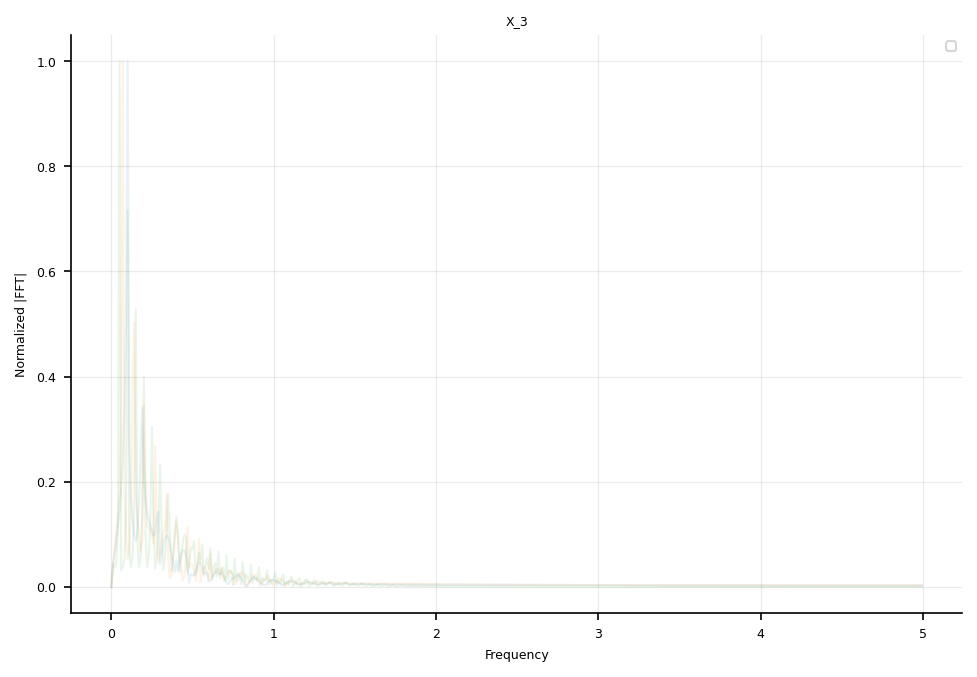

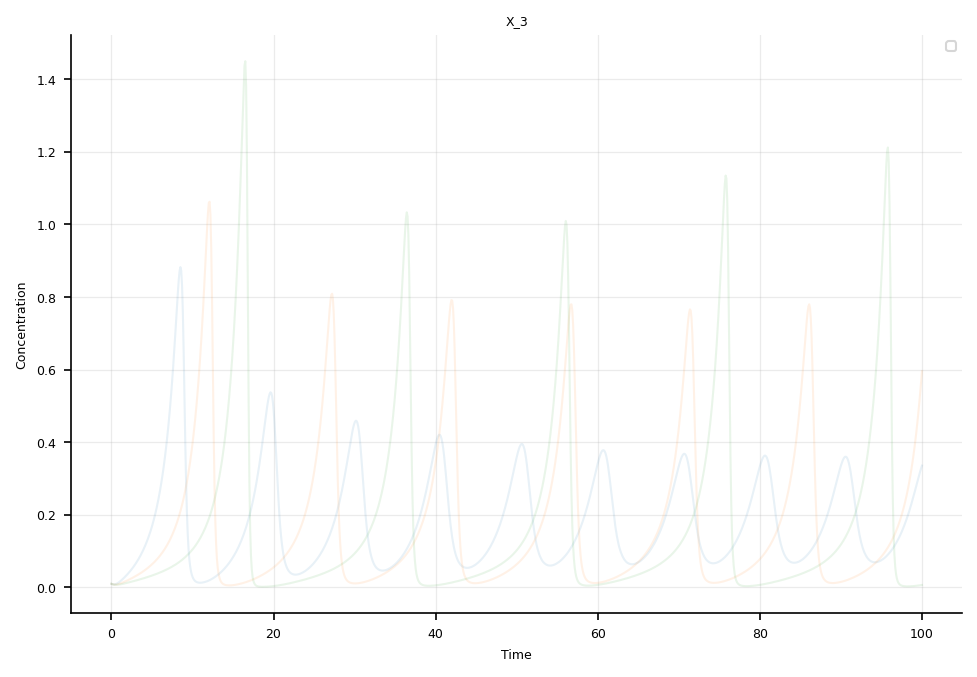

In [38]:
import os
import glob
import json
import torch
import copy
import numpy as np

from RL4CRN.utils import default_tasks  # noqa: F401
from RL4CRN.utils.default_tasks.OscillatorFreqTaskKind import OscillatorFreqTaskKind  # noqa: F401

from RL4CRN.utils.input_interface import (
    Configurator,
    make_task,
    make_session_and_trainer,
    print_task_summary,
)

from RL4CRN.utils.crn_builders import build_simple_IOCRN
from RL4CRN.utils.library_builders import build_MAK_library


# -------------------------
# 1) TASK-SPECIFIC SETTINGS
# -------------------------
target_directory = "/local0/rossin/git/CRN-GenerativeAI/apps_results_MAK_REINFORCE/oscillators_freq_3species_6rxns"
preset = "paper"

# Old-equivalent template (we'll build with simple builder)
species_labels = ["X_1", "X_2", "X_3"]
production_input_map = {"X_1": "u_1"}  # ∅ --(u1)-> X_1
degradation_input_map = {}             # base degradations are in dilution_map below
dilution_map = {"X_1": None, "X_2": None, "X_3": None}
output_species = "X_3"

mak_order = 2

# Task settings
t_f = 100
n_t = 1000
periods = [10, 15, 20]
u_list_custom = [np.array([1.0 / p], dtype=np.float32) for p in periods]  # u_1 = 1/period
ic_spec = ("values", [[0.01, 0.01, 0.01]])
t0 = 20.0
LARGE_NUMBER = 1e4

# Old w = [mean, freq, damping, periodicity]
osc_w = [0.0, 0.6, 0.1, 0.3]

# freq_target matches old f_list = u_list
freq_target = (lambda u_1: u_1)

# Training wiring knobs
max_added_reactions = 6
seed = 0

TASK_TAG = "oscillator_freq"


# -------------------------
# 2) HoF load + safe deepcopy
# -------------------------
def _extract_crn(obj):
    if hasattr(obj, "state"):
        crn = obj.state
        rew = None
        if hasattr(obj, "reward"):
            rew = getattr(obj, "reward")
        elif hasattr(obj, "perf"):
            rew = getattr(obj, "perf")
        return crn, rew
    if isinstance(obj, tuple) and len(obj) >= 1:
        return obj[0], (obj[1] if len(obj) > 1 else None)
    if isinstance(obj, dict):
        for k in ["state", "crn", "iocrn"]:
            if k in obj:
                return obj[k], obj.get("reward", obj.get("perf", None))
    return obj, None


def load_old_hof_file(hof_file: str, map_location="cpu"):
    data = torch.load(hof_file, map_location=map_location, weights_only=False)
    crns = []
    for entry in data:
        crn, rew = _extract_crn(entry)
        if crn is None:
            continue
        if getattr(crn, "last_task_info", None) is None:
            crn.last_task_info = {}
        if rew is not None:
            crn.last_task_info["reward"] = float(rew)
        crns.append(crn)
    return crns


def _safe_copy_last_task_info(info):
    if info is None:
        return {}
    try:
        return copy.deepcopy(info)
    except Exception:
        out = dict(info)
        for k, v in list(out.items()):
            if isinstance(v, np.ndarray):
                out[k] = v.copy()
        return out


class _EnvStateWrapper:
    def __init__(self, state):
        self.state = state


# -------------------------
# 3) Build trainer (new interface, oscillator_freq)
# -------------------------
def build_trainer_for_oscillator_freq_task():
    cfg = Configurator.preset(preset)
    cfg.solver.algorithm = "CVODE"
    cfg.solver.rtol = 1e-10
    cfg.solver.atol = 1e-10

    cfg.train.max_added_reactions = max_added_reactions
    cfg.train.epochs = 1
    cfg.train.seed = seed

    crn, species_out = build_simple_IOCRN(
        species=species_labels,
        production_input_map=production_input_map,
        degradation_input_map=degradation_input_map,
        dilution_map=dilution_map,
        output_species=output_species,
        solver=cfg.solver,
    )

    library_components = build_MAK_library(crn, species_out, order=mak_order)

    task = make_task(
        template_crn=crn,
        library_components=library_components,
        kind="oscillator_freq",
        species_labels=species_out,
        params={
            "t_f": t_f,
            "n_t": n_t,
            "ic": ic_spec,
            "u_spec": ("custom", u_list_custom),  # exact old u_list
            "osc_w": osc_w,                       # REQUIRED by OscillatorFreqTaskKind
            "freq_target": freq_target,           # REQUIRED by OscillatorFreqTaskKind
            "t0": t0,
            "LARGE_NUMBER": LARGE_NUMBER,
        },
    )

    print_task_summary(task)
    trainer = make_session_and_trainer(cfg, task, logger=None)
    return trainer


# -------------------------
# 4) Patch solver fields on old CRNs
# -------------------------
def patch_solver_fields(crns, template_crn):
    solver = getattr(template_crn, "solver", None)
    rtol = getattr(template_crn, "rtol", None)
    atol = getattr(template_crn, "atol", None)
    for c in crns:
        if not hasattr(c, "solver") and solver is not None:
            c.solver = solver
        if not hasattr(c, "rtol") and rtol is not None:
            c.rtol = rtol
        if not hasattr(c, "atol") and atol is not None:
            c.atol = atol


# -------------------------
# 5) Inject HoF + resimulate whole HoF + replace
# -------------------------
def inject_hof(trainer, crns, max_size=None):
    if max_size is None:
        max_size = int(getattr(trainer.s.cfg.train, "hall_of_fame_size", len(crns)))

    task = trainer.s.task
    u_list_task = task.u_list
    time_horizon_task = task.time_horizon

    def loss_of(crn):
        info = getattr(crn, "last_task_info", {}) or {}
        r = info.get("reward", None)
        return float(r) if r is not None else float("inf")

    crns_sorted = sorted(crns, key=loss_of)[:max_size]

    for c in crns_sorted:
        old_info = getattr(c, "last_task_info", None)
        c.last_task_info = _safe_copy_last_task_info(old_info)
        c.last_task_info["u_list"] = u_list_task
        c.last_task_info["time_horizon"] = time_horizon_task
        c.last_task_info["task_kind"] = task.kind
        c.last_task_info["osc_w"] = osc_w
        c.last_task_info["freq_target"] = freq_target
        c.last_task_info["t0"] = t0

        if "reward" not in c.last_task_info and old_info is not None:
            try:
                if "reward" in old_info:
                    c.last_task_info["reward"] = float(old_info["reward"])
            except Exception:
                pass

    trainer.s.mult_env.hall_of_fame = [_EnvStateWrapper(c) for c in crns_sorted]


def resimulate_whole_hof_and_replace(trainer):
    hof_crns = [item.state for item in trainer.s.mult_env.hall_of_fame]
    if not hof_crns:
        return []

    patch_solver_fields(hof_crns, trainer.s.task.template_crn)

    task = trainer.s.task
    crns_new = trainer.resimulate(
        hof_crns,
        task=task,
        ic=task.ic_spec,
        u_list=task.u_list,
    )

    wrapped = []
    for c in crns_new:
        if getattr(c, "last_task_info", None) is None:
            c.last_task_info = {}
        c.last_task_info["u_list"] = task.u_list
        c.last_task_info["time_horizon"] = task.time_horizon
        c.last_task_info["task_kind"] = task.kind
        c.last_task_info["osc_w"] = osc_w
        c.last_task_info["freq_target"] = freq_target
        c.last_task_info["t0"] = t0
        wrapped.append(_EnvStateWrapper(c))

    trainer.s.mult_env.hall_of_fame = wrapped
    return crns_new


# -------------------------
# 6) Convert: one trainer per HoF file
# -------------------------
def convert_one_app_many_trainers(target_directory: str):
    hof_dir = os.path.join(target_directory, "hof")
    hof_files = sorted(glob.glob(os.path.join(hof_dir, "hall_of_fame_*.pth")))
    if not hof_files:
        raise FileNotFoundError(f"No HoF files found: {os.path.join(hof_dir, 'hall_of_fame_*.pth')}")

    base = os.path.basename(os.path.normpath(target_directory))
    trainers = []

    for i, hof_file in enumerate(hof_files):
        trainer = build_trainer_for_oscillator_freq_task()

        crns = load_old_hof_file(hof_file, map_location="cpu")
        print(f"[run {i}] Loaded {len(crns)} CRNs from {os.path.basename(hof_file)}")

        inject_hof(trainer, crns, max_size=trainer.s.cfg.train.hall_of_fame_size)

        crns_resim = resimulate_whole_hof_and_replace(trainer)
        print(f"[run {i}] Resimulated HoF CRNs: {len(crns_resim)}")

        ckpt_path = os.path.join(target_directory, f"{base}_run{i}.pkl")
        trainer.save(ckpt_path)

        meta = {
            "target_directory": target_directory,
            "hof_file": hof_file,
            "n_loaded_crns": len(crns),
            "n_resimulated_crns": len(crns_resim),
            "task_tag": TASK_TAG,
            "preset": preset,
            "species_labels": species_labels,
            "mak_order": mak_order,
            "t_f": t_f,
            "n_t": n_t,
            "ic": ic_spec,
            "periods": periods,
            "u_list": [u.tolist() for u in u_list_custom],
            "osc_w": osc_w,
            "t0": t0,
            "max_added_reactions": max_added_reactions,
            "seed": seed,
            "checkpoint_path": ckpt_path,
            "run_index": i,
        }
        with open(os.path.join(target_directory, f"{base}_run{i}.meta.json"), "w") as f:
            json.dump(meta, f, indent=2)

        print(f"[run {i}] Saved trainer checkpoint -> {ckpt_path}")
        trainers.append(trainer)

    return trainers


if __name__ == "__main__":
    trainers = convert_one_app_many_trainers(target_directory)

    # Optional: verify plots
    import matplotlib.pyplot as plt
    for i, tr in enumerate(trainers):
        print(f"\n--- Inspecting run {i} ---")
        crn = tr.inspect_best(plot=True)
        crn.plot_transient_response()
        plt.show()

Lift

Task: oscillator_mean
time_horizon: (1000,) [0..100.0]
num scenarios: 1
first 1 u: [array([1.], dtype=float32)]

[run 0] Loaded 30 CRNs from hall_of_fame_2025-12-02 17:51:08.pth
[run 0] Resimulated HoF CRNs: 30
Saved checkpoint: /local0/rossin/git/CRN-GenerativeAI/apps_results_MAK_REINFORCE/oscillators_lift_3species_6rxns/oscillators_lift_3species_6rxns_run0.pkl
[run 0] Saved trainer checkpoint -> /local0/rossin/git/CRN-GenerativeAI/apps_results_MAK_REINFORCE/oscillators_lift_3species_6rxns/oscillators_lift_3species_6rxns_run0.pkl
Task: oscillator_mean
time_horizon: (1000,) [0..100.0]
num scenarios: 1
first 1 u: [array([1.], dtype=float32)]

[run 1] Loaded 30 CRNs from hall_of_fame_2025-12-03 07:10:34.pth
[run 1] Resimulated HoF CRNs: 30
Saved checkpoint: /local0/rossin/git/CRN-GenerativeAI/apps_results_MAK_REINFORCE/oscillators_lift_3species_6rxns/oscillators_lift_3species_6rxns_run1.pkl
[run 1] Saved trainer checkpoint -> /local0/rossin/git/CRN-GenerativeAI/apps_results_MAK_REINFORCE

/local0/rossin/git/CRN-GenerativeAI/RL4CRN/utils/plotting_style.py:120: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(**cfg.get("legend_kwargs", {}))


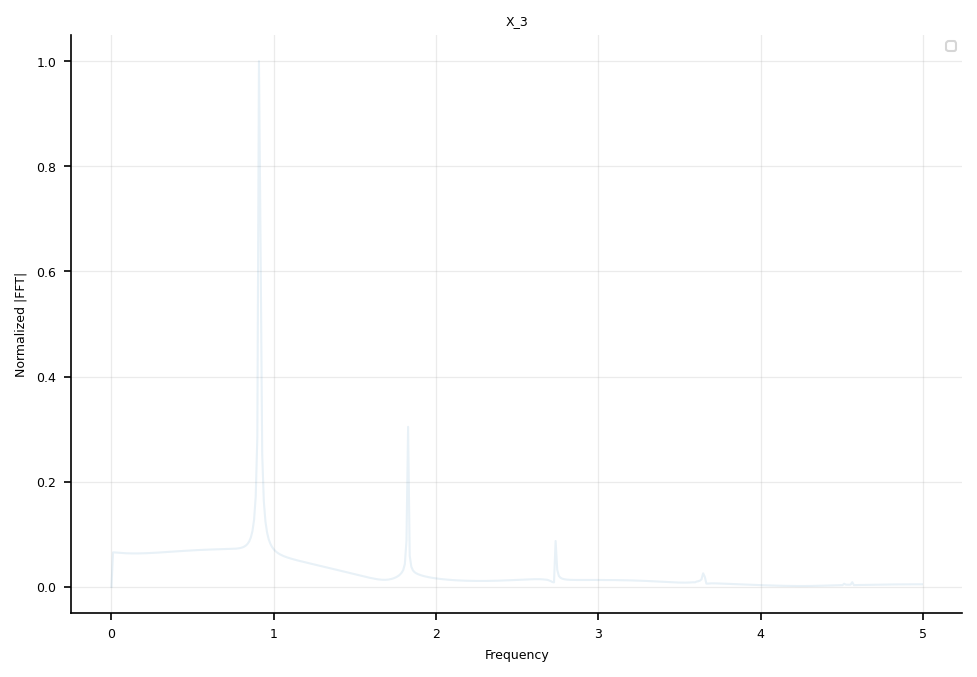


--- Inspecting run 1 ---
Best CRN loss: 0.005168961339660027
Inputs: ['u_1'] 
Species: ['X_1', 'X_2', 'X_3'] 
Output Species: ['X_3'] 
∅ ----> ∅;  [MAK(17.175737380981445)]
∅ ----> X_1;  [MAK(1.0, u_1)]
X_1 ----> ∅;  [MAK(1)]
X_2 ----> ∅;  [MAK(1)]
X_2 ----> X_2 + X_2;  [MAK(17.751522064208984)]
X_3 ----> ∅;  [MAK(1)]
X_1 + X_2 ----> X_2 + X_3;  [MAK(16.378131866455078)]
X_1 + X_3 ----> ∅;  [MAK(16.911245346069336)]
X_1 + X_3 ----> X_1 + X_1;  [MAK(17.405513763427734)]
X_2 + X_3 ----> X_3 + X_3;  [MAK(16.80999755859375)]


/local0/rossin/git/CRN-GenerativeAI/RL4CRN/utils/plotting_style.py:120: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(**cfg.get("legend_kwargs", {}))


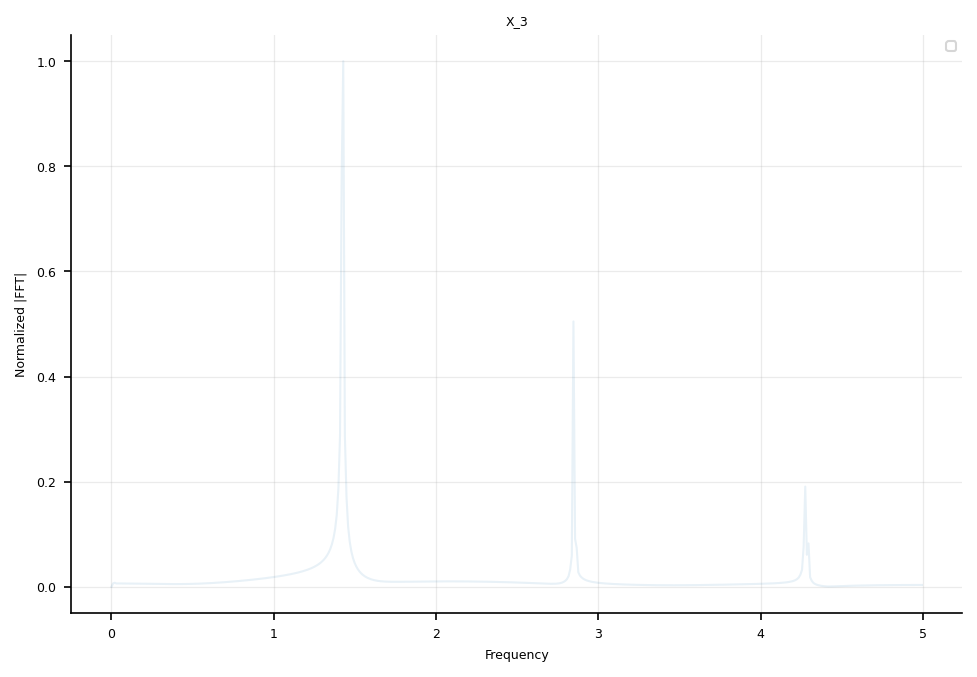


--- Inspecting run 2 ---
Best CRN loss: 0.01636897530687227
Inputs: ['u_1'] 
Species: ['X_1', 'X_2', 'X_3'] 
Output Species: ['X_3'] 
∅ ----> X_1;  [MAK(1.0, u_1)]
X_1 ----> ∅;  [MAK(1)]
X_1 ----> X_1 + X_1;  [MAK(9.494065284729004)]
X_2 ----> ∅;  [MAK(1)]
X_3 ----> ∅;  [MAK(1)]
X_3 ----> X_2;  [MAK(8.629148483276367)]
X_1 + X_2 ----> X_1;  [MAK(9.841188430786133)]
X_1 + X_3 ----> X_1;  [MAK(8.166172981262207)]
X_1 + X_3 ----> X_3 + X_3;  [MAK(8.679641723632812)]
X_2 + X_2 ----> X_1 + X_1;  [MAK(9.381940841674805)]


/local0/rossin/git/CRN-GenerativeAI/RL4CRN/utils/plotting_style.py:120: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(**cfg.get("legend_kwargs", {}))


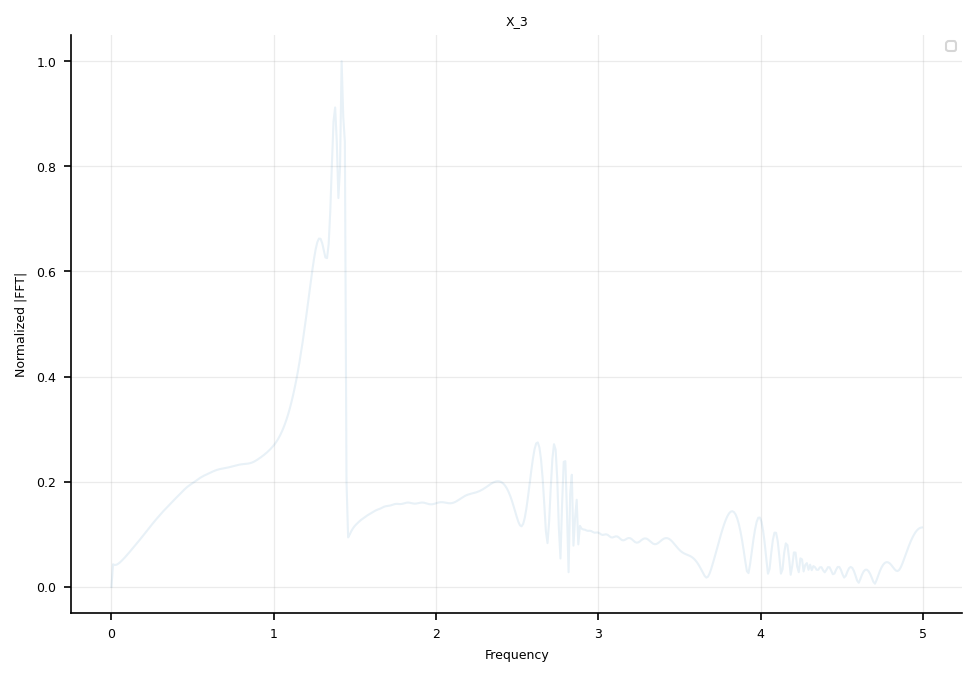

In [40]:
import os
import glob
import json
import torch
import copy
import numpy as np

# Ensure TaskKinds are registered
from RL4CRN.utils import default_tasks  # noqa: F401
from RL4CRN.utils.default_tasks.OscillatorMeanTaskKind import OscillatorMeanTaskKind  # noqa: F401

from RL4CRN.utils.input_interface import (
    Configurator,
    make_task,
    make_session_and_trainer,
    print_task_summary,
)

from RL4CRN.utils.crn_builders import build_simple_IOCRN
from RL4CRN.utils.library_builders import build_MAK_library


# -------------------------
# 1) TASK-SPECIFIC SETTINGS
# -------------------------
target_directory = "/local0/rossin/git/CRN-GenerativeAI/apps_results_MAK_REINFORCE/oscillators_lift_3species_6rxns"
preset = "paper"

# Template (matches old: ∅ --(u1)-> X_1, degradations for X_1,X_2,X_3, output=X_3)
species_labels = ["X_1", "X_2", "X_3"]
production_input_map = {"X_1": "u_1"}
degradation_input_map = {}
dilution_map = {"X_1": None, "X_2": None, "X_3": None}
output_species = "X_3"

mak_order = 2

# Task settings
t_f = 100
n_t = 1000
u_list_custom = [np.array([1.0], dtype=np.float32)]           # old u_list = [[1.0]]
ic_spec = ("values", [[0.01, 0.01, 0.01]])
t0 = 20.0
LARGE_NUMBER = 1e4

# Old w = [mean, freq, damping, periodicity]
osc_w = [0.4, 0.0, 0.2, 0.4]

# Old mean_list = [u[0]] => mean_target = u_1
mean_target = (lambda u_1: u_1)

# Training wiring knobs
max_added_reactions = 6
seed = 0

TASK_TAG = "oscillator_mean"


# -------------------------
# 2) HoF load + safe deepcopy
# -------------------------
def _extract_crn(obj):
    if hasattr(obj, "state"):
        crn = obj.state
        rew = None
        if hasattr(obj, "reward"):
            rew = getattr(obj, "reward")
        elif hasattr(obj, "perf"):
            rew = getattr(obj, "perf")
        return crn, rew
    if isinstance(obj, tuple) and len(obj) >= 1:
        return obj[0], (obj[1] if len(obj) > 1 else None)
    if isinstance(obj, dict):
        for k in ["state", "crn", "iocrn"]:
            if k in obj:
                return obj[k], obj.get("reward", obj.get("perf", None))
    return obj, None


def load_old_hof_file(hof_file: str, map_location="cpu"):
    data = torch.load(hof_file, map_location=map_location, weights_only=False)
    crns = []
    for entry in data:
        crn, rew = _extract_crn(entry)
        if crn is None:
            continue
        if getattr(crn, "last_task_info", None) is None:
            crn.last_task_info = {}
        if rew is not None:
            crn.last_task_info["reward"] = float(rew)
        crns.append(crn)
    return crns


def _safe_copy_last_task_info(info):
    if info is None:
        return {}
    try:
        return copy.deepcopy(info)
    except Exception:
        out = dict(info)
        for k, v in list(out.items()):
            if isinstance(v, np.ndarray):
                out[k] = v.copy()
        return out


class _EnvStateWrapper:
    def __init__(self, state):
        self.state = state


# -------------------------
# 3) Build trainer (new interface, oscillator_mean)
# -------------------------
def build_trainer_for_oscillator_mean_task():
    cfg = Configurator.preset(preset)
    cfg.solver.algorithm = "CVODE"
    cfg.solver.rtol = 1e-10
    cfg.solver.atol = 1e-10

    cfg.train.max_added_reactions = max_added_reactions
    cfg.train.epochs = 1
    cfg.train.seed = seed

    crn, species_out = build_simple_IOCRN(
        species=species_labels,
        production_input_map=production_input_map,
        degradation_input_map=degradation_input_map,
        dilution_map=dilution_map,
        output_species=output_species,
        solver=cfg.solver,
    )

    library_components = build_MAK_library(crn, species_out, order=mak_order)

    task = make_task(
        template_crn=crn,
        library_components=library_components,
        kind="oscillator_mean",
        species_labels=species_out,
        params={
            "t_f": t_f,
            "n_t": n_t,
            "ic": ic_spec,
            "u_spec": ("custom", u_list_custom),  # exact old u_list
            "osc_w": osc_w,                       # REQUIRED
            "mean_target": mean_target,           # REQUIRED (matches mean_list = u_1)
            "t0": t0,
            "LARGE_NUMBER": LARGE_NUMBER,
        },
    )

    print_task_summary(task)
    trainer = make_session_and_trainer(cfg, task, logger=None)
    return trainer


# -------------------------
# 4) Patch solver fields on old CRNs (force 1e-10 tolerances)
# -------------------------
def patch_solver_fields(crns, template_crn):
    solver = getattr(template_crn, "solver", None)
    for c in crns:
        if solver is not None:
            c.solver = solver
        c.rtol = 1e-10
        c.atol = 1e-10


# -------------------------
# 5) Inject HoF + resimulate whole HoF + replace
# -------------------------
def inject_hof(trainer, crns, max_size=None):
    if max_size is None:
        max_size = int(getattr(trainer.s.cfg.train, "hall_of_fame_size", len(crns)))

    task = trainer.s.task
    u_list_task = task.u_list
    time_horizon_task = task.time_horizon

    def loss_of(crn):
        info = getattr(crn, "last_task_info", {}) or {}
        r = info.get("reward", None)
        return float(r) if r is not None else float("inf")

    crns_sorted = sorted(crns, key=loss_of)[:max_size]

    for c in crns_sorted:
        old_info = getattr(c, "last_task_info", None)
        c.last_task_info = _safe_copy_last_task_info(old_info)
        c.last_task_info["u_list"] = u_list_task
        c.last_task_info["time_horizon"] = time_horizon_task
        c.last_task_info["task_kind"] = task.kind
        c.last_task_info["osc_w"] = osc_w
        c.last_task_info["mean_target"] = mean_target
        c.last_task_info["t0"] = t0

        if "reward" not in c.last_task_info and old_info is not None:
            try:
                if "reward" in old_info:
                    c.last_task_info["reward"] = float(old_info["reward"])
            except Exception:
                pass

    trainer.s.mult_env.hall_of_fame = [_EnvStateWrapper(c) for c in crns_sorted]


def resimulate_whole_hof_and_replace(trainer):
    hof_crns = [item.state for item in trainer.s.mult_env.hall_of_fame]
    if not hof_crns:
        return []

    patch_solver_fields(hof_crns, trainer.s.task.template_crn)

    task = trainer.s.task
    crns_new = trainer.resimulate(
        hof_crns,
        task=task,
        ic=task.ic_spec,
        u_list=task.u_list,
    )

    wrapped = []
    for c in crns_new:
        if getattr(c, "last_task_info", None) is None:
            c.last_task_info = {}
        c.last_task_info["u_list"] = task.u_list
        c.last_task_info["time_horizon"] = task.time_horizon
        c.last_task_info["task_kind"] = task.kind
        c.last_task_info["osc_w"] = osc_w
        c.last_task_info["mean_target"] = mean_target
        c.last_task_info["t0"] = t0
        wrapped.append(_EnvStateWrapper(c))

    trainer.s.mult_env.hall_of_fame = wrapped
    return crns_new


# -------------------------
# 6) Convert: one trainer per HoF file
# -------------------------
def convert_one_app_many_trainers(target_directory: str):
    hof_dir = os.path.join(target_directory, "hof")
    hof_files = sorted(glob.glob(os.path.join(hof_dir, "hall_of_fame_*.pth")))
    if not hof_files:
        raise FileNotFoundError(f"No HoF files found: {os.path.join(hof_dir, 'hall_of_fame_*.pth')}")

    base = os.path.basename(os.path.normpath(target_directory))
    trainers = []

    for i, hof_file in enumerate(hof_files):
        trainer = build_trainer_for_oscillator_mean_task()

        crns = load_old_hof_file(hof_file, map_location="cpu")
        print(f"[run {i}] Loaded {len(crns)} CRNs from {os.path.basename(hof_file)}")

        inject_hof(trainer, crns, max_size=trainer.s.cfg.train.hall_of_fame_size)

        crns_resim = resimulate_whole_hof_and_replace(trainer)
        print(f"[run {i}] Resimulated HoF CRNs: {len(crns_resim)}")

        ckpt_path = os.path.join(target_directory, f"{base}_run{i}.pkl")
        trainer.save(ckpt_path)

        meta = {
            "target_directory": target_directory,
            "hof_file": hof_file,
            "n_loaded_crns": len(crns),
            "n_resimulated_crns": len(crns_resim),
            "task_tag": TASK_TAG,
            "preset": preset,
            "species_labels": species_labels,
            "mak_order": mak_order,
            "t_f": t_f,
            "n_t": n_t,
            "ic": ic_spec,
            "u_list": [u.tolist() for u in u_list_custom],
            "osc_w": osc_w,
            "t0": t0,
            "max_added_reactions": max_added_reactions,
            "seed": seed,
            "checkpoint_path": ckpt_path,
            "run_index": i,
        }
        with open(os.path.join(target_directory, f"{base}_run{i}.meta.json"), "w") as f:
            json.dump(meta, f, indent=2)

        print(f"[run {i}] Saved trainer checkpoint -> {ckpt_path}")
        trainers.append(trainer)

    return trainers


if __name__ == "__main__":
    trainers = convert_one_app_many_trainers(target_directory)

    # Optional: verify plots
    import matplotlib.pyplot as plt
    for i, tr in enumerate(trainers):
        print(f"\n--- Inspecting run {i} ---")
        tr.inspect_best(plot=True)
        plt.show()

## Stochastic SSA

Task: ssa_robust
time_horizon: (100,) [0..100.0]
num scenarios: 9
first 3 u: [array([1. , 0.5], dtype=float32), array([1., 1.], dtype=float32), array([1. , 1.5], dtype=float32)]

[run 0] Loaded 30 CRNs from hall_of_fame_2025-12-12 11:03:06.pth
[run 0] Resimulated HoF CRNs: 30
Saved checkpoint: /local0/rossin/git/CRN-GenerativeAI/apps_results_MAK_REINFORCE/RPA_stochastic_3species_6rxns/RPA_stochastic_3species_6rxns_run0.pkl
[run 0] Saved trainer checkpoint -> /local0/rossin/git/CRN-GenerativeAI/apps_results_MAK_REINFORCE/RPA_stochastic_3species_6rxns/RPA_stochastic_3species_6rxns_run0.pkl
Task: ssa_robust
time_horizon: (100,) [0..100.0]
num scenarios: 9
first 3 u: [array([1. , 0.5], dtype=float32), array([1., 1.], dtype=float32), array([1. , 1.5], dtype=float32)]

[run 1] Loaded 30 CRNs from hall_of_fame_2025-12-15 09:43:09.pth
[run 1] Resimulated HoF CRNs: 30
Saved checkpoint: /local0/rossin/git/CRN-GenerativeAI/apps_results_MAK_REINFORCE/RPA_stochastic_3species_6rxns/RPA_stochastic_3s

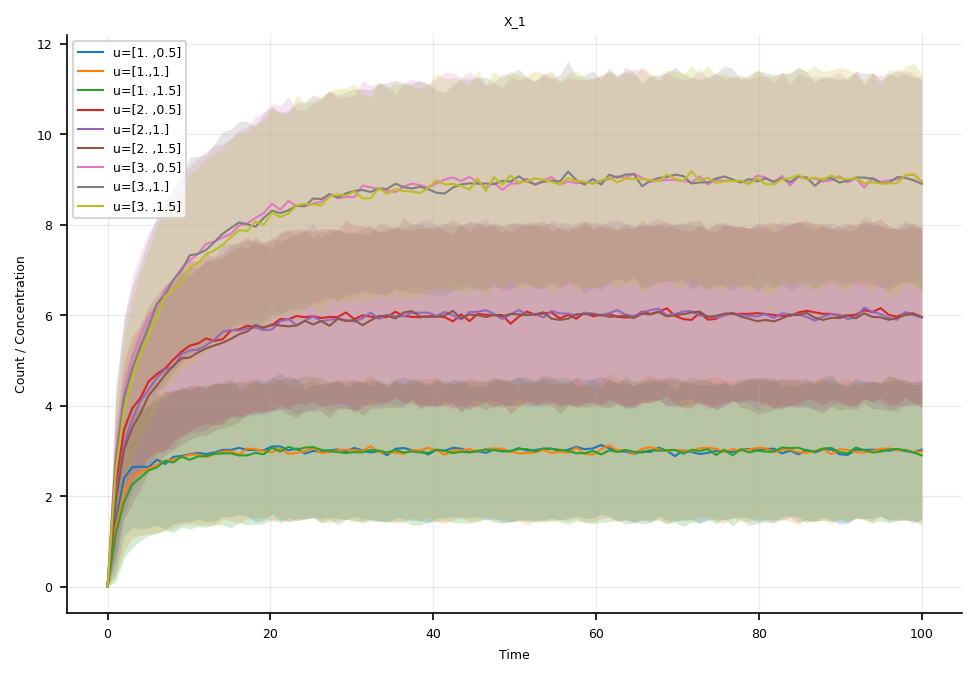


--- Inspecting run 1 ---
Best CRN loss: 0.32716355944365294
Inputs: ['u_1', 'u_2'] 
Species: ['X_1', 'Z_1', 'Z_2', 'Z_3'] 
Output Species: ['X_1'] 
∅ ----> Z_1;  [MAK(3.0, u_1)]
∅ ----> Z_1 + Z_2;  [MAK(0.3167016804218292)]
X_1 ----> ∅;  [MAK(1.0, u_2)]
X_1 ----> Z_2 + Z_2;  [MAK(0.49915170669555664)]
Z_1 ----> X_1 + Z_1;  [MAK(0.6502559781074524)]
X_1 + X_1 ----> X_1;  [MAK(0.9459006190299988)]
Z_1 + Z_2 ----> ∅;  [MAK(0.7184900641441345)]
Z_2 + Z_3 ----> X_1 + Z_1;  [MAK(0.5939132571220398)]


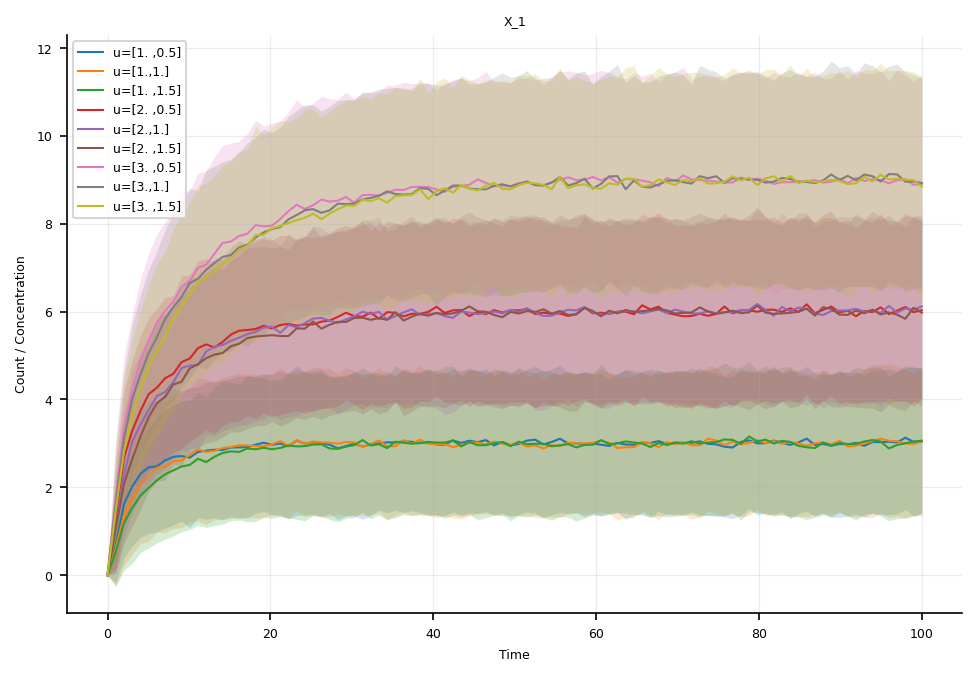


--- Inspecting run 2 ---
Best CRN loss: 0.34730065498860263
Inputs: ['u_1', 'u_2'] 
Species: ['X_1', 'Z_1', 'Z_2', 'Z_3'] 
Output Species: ['X_1'] 
∅ ----> Z_1;  [MAK(3.0, u_1)]
X_1 ----> ∅;  [MAK(1.0, u_2)]
Z_1 ----> X_1 + Z_2;  [MAK(8.012606620788574)]
Z_2 ----> X_1;  [MAK(1.5591816902160645)]
X_1 + X_1 ----> X_1;  [MAK(7.508254051208496)]
X_1 + Z_3 ----> X_1 + Z_2;  [MAK(4.980125427246094)]
Z_2 + Z_2 ----> Z_1 + Z_1;  [MAK(6.332668304443359)]
Z_2 + Z_2 ----> Z_1 + Z_2;  [MAK(5.041019439697266)]


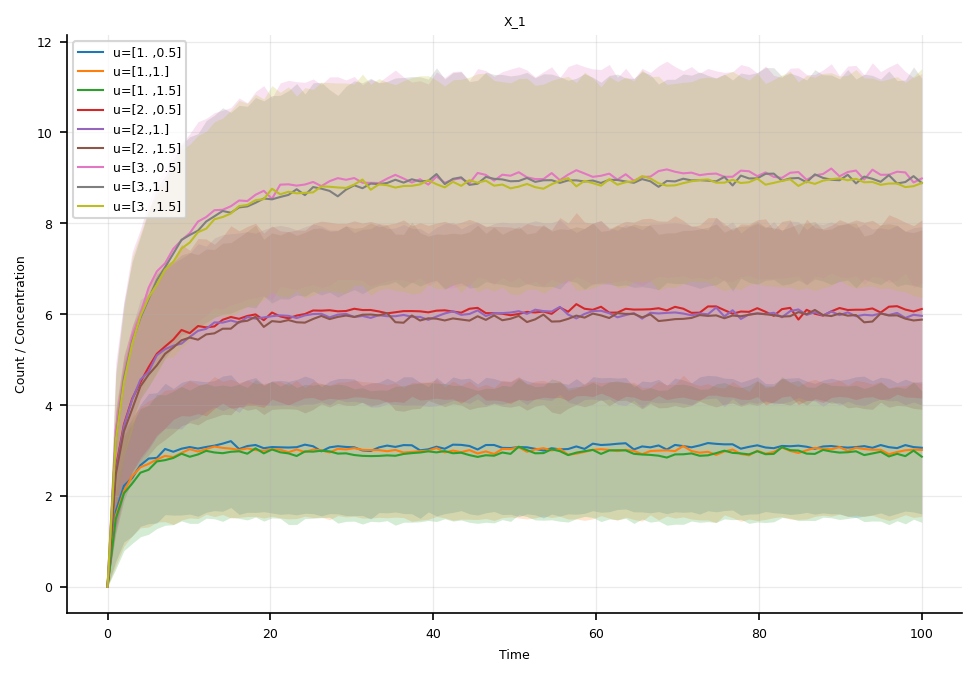

In [2]:
import os
import glob
import json
import torch
import copy
import numpy as np

from RL4CRN.utils import default_tasks  # noqa: F401
from RL4CRN.utils.default_tasks.SSARobustTaskKind import SSARobustTaskKind  # noqa: F401

from RL4CRN.utils.input_interface import (
    Configurator,
    make_task,
    make_session_and_trainer,
    print_task_summary,
)

from RL4CRN.utils.crn_builders import build_simple_IOCRN
from RL4CRN.utils.library_builders import build_MAK_library


# -------------------------
# 1) TASK-SPECIFIC SETTINGS
# -------------------------
target_directory = "/local0/rossin/git/CRN-GenerativeAI/apps_results_MAK_REINFORCE/RPA_stochastic_3species_6rxns"
preset = "paper"

scale = 3.0

# Old script used 4 species: ['X_1','Z_1','Z_2','Z_3']
species_labels = ["X_1", "Z_1", "Z_2", "Z_3"]
production_input_map = {"Z_1": "u_1"}
degradation_input_map = {"X_1": "u_2"}
dilution_map = {}
output_species = "X_1"

mak_order = 2

# SSA grid (old)
t_f = 100
n_t = 100

nums = [1.0, 2.0, 3.0]
disturbances = [0.5, 1.0, 1.5]
u_list_custom = [np.array([a, b], dtype=np.float32) for a in nums for b in disturbances]

# target: r = scale * u1
target = (lambda u_1: scale * u_1)

ic_spec = ("values", [[0.0, 0.0, 0.0, 0.0]])

# weights (old)
w = np.ones(n_t, dtype=np.float32)
w[(len(w) // 5) * 4:] *= 2.0
w[: 2 * (len(w) // 5)] *= 0.0
w = w[None, :].astype(np.float32)
weights_spec = ("custom", w)

# SSA knobs (old)
n_trajectories = 1024
max_threads = 1024
LARGE_NUMBER = 1e3
LARGE_PENALTY = 100.0
cv_weight = 1.0
rpa_weight = 3.0

# wiring
max_added_reactions = 6
seed = 0
TASK_TAG = "ssa_robust_rpa"


# -------------------------
# 2) HoF utilities
# -------------------------
def _extract_crn(obj):
    if hasattr(obj, "state"):
        crn = obj.state
        rew = None
        if hasattr(obj, "reward"):
            rew = getattr(obj, "reward")
        elif hasattr(obj, "perf"):
            rew = getattr(obj, "perf")
        return crn, rew
    if isinstance(obj, tuple) and len(obj) >= 1:
        return obj[0], (obj[1] if len(obj) > 1 else None)
    if isinstance(obj, dict):
        for k in ["state", "crn", "iocrn"]:
            if k in obj:
                return obj[k], obj.get("reward", obj.get("perf", None))
    return obj, None


def load_old_hof_file(hof_file: str, map_location="cpu"):
    data = torch.load(hof_file, map_location=map_location, weights_only=False)
    crns = []
    for entry in data:
        crn, rew = _extract_crn(entry)
        if crn is None:
            continue
        if getattr(crn, "last_task_info", None) is None:
            crn.last_task_info = {}
        if rew is not None:
            crn.last_task_info["reward"] = float(rew)
        crns.append(crn)
    return crns


def _safe_copy_last_task_info(info):
    if info is None:
        return {}
    try:
        return copy.deepcopy(info)
    except Exception:
        out = dict(info)
        for k, v in list(out.items()):
            if isinstance(v, np.ndarray):
                out[k] = v.copy()
        return out


class _EnvStateWrapper:
    def __init__(self, state):
        self.state = state


# -------------------------
# 3) Build trainer (ssa_robust)
# -------------------------
def build_trainer_for_ssa_robust_rpa():
    cfg = Configurator.preset(preset)

    # deterministic solver for post-analysis plots only
    cfg.solver.algorithm = "CVODE"
    cfg.solver.rtol = 1e-10
    cfg.solver.atol = 1e-10

    # SSA handled by GPU: keep CPU count modest
    cfg.train.n_cpus = 4
    cfg.train.batch_size = 160

    cfg.train.max_added_reactions = max_added_reactions
    cfg.train.epochs = 1
    cfg.train.seed = seed

    crn, species_out = build_simple_IOCRN(
        species=species_labels,
        production_input_map=production_input_map,
        degradation_input_map=degradation_input_map,
        dilution_map=dilution_map,
        output_species=output_species,
        solver=cfg.solver,
    )

    library_components = build_MAK_library(crn, species_out, order=mak_order)

    # IMPORTANT: do NOT pass "relative" because TaskSpec has no .relative field.
    task = make_task(
        template_crn=crn,
        library_components=library_components,
        kind="ssa_robust",
        species_labels=species_out,
        params={
            "t_f": t_f,
            "n_t": n_t,
            "ic": ic_spec,
            "weights": weights_spec,
            "u_spec": ("custom", u_list_custom),
            "target": target,
            "n_trajectories": n_trajectories,
            "max_threads": max_threads,
            "LARGE_NUMBER": LARGE_NUMBER,
            "LARGE_PENALTY": LARGE_PENALTY,
            "cv_weight": cv_weight,
            "rpa_weight": rpa_weight,
        },
    )

    print_task_summary(task)
    trainer = make_session_and_trainer(cfg, task, logger=None)
    return trainer


# -------------------------
# 4) Patch solver tolerances on old CRNs (for any deterministic plotting)
# -------------------------
def patch_solver_fields(crns, template_crn):
    solver = getattr(template_crn, "solver", None)
    for c in crns:
        if solver is not None:
            c.solver = solver
        c.rtol = 1e-10
        c.atol = 1e-10


# -------------------------
# 5) Inject HoF + resimulate whole HoF + replace
# -------------------------
def inject_hof(trainer, crns, max_size=None):
    if max_size is None:
        max_size = int(getattr(trainer.s.cfg.train, "hall_of_fame_size", len(crns)))

    task = trainer.s.task

    def loss_of(crn):
        info = getattr(crn, "last_task_info", {}) or {}
        r = info.get("reward", None)
        return float(r) if r is not None else float("inf")

    crns_sorted = sorted(crns, key=loss_of)[:max_size]

    for c in crns_sorted:
        old_info = getattr(c, "last_task_info", None)
        c.last_task_info = _safe_copy_last_task_info(old_info)
        c.last_task_info["u_list"] = task.u_list
        c.last_task_info["time_horizon"] = task.time_horizon
        c.last_task_info["task_kind"] = task.kind

        if "reward" not in c.last_task_info and old_info is not None:
            try:
                if "reward" in old_info:
                    c.last_task_info["reward"] = float(old_info["reward"])
            except Exception:
                pass

    trainer.s.mult_env.hall_of_fame = [_EnvStateWrapper(c) for c in crns_sorted]


def resimulate_whole_hof_and_replace(trainer):
    hof_crns = [item.state for item in trainer.s.mult_env.hall_of_fame]
    if not hof_crns:
        return []

    patch_solver_fields(hof_crns, trainer.s.task.template_crn)

    task = trainer.s.task
    crns_new = trainer.resimulate(
        hof_crns,
        task=task,
        ic=task.ic_spec,
        weights=task.weights_spec,
        u_list=task.u_list,
    )

    wrapped = []
    for c in crns_new:
        if getattr(c, "last_task_info", None) is None:
            c.last_task_info = {}
        c.last_task_info["u_list"] = task.u_list
        c.last_task_info["time_horizon"] = task.time_horizon
        c.last_task_info["task_kind"] = task.kind
        wrapped.append(_EnvStateWrapper(c))

    trainer.s.mult_env.hall_of_fame = wrapped
    return crns_new


# -------------------------
# 6) Convert: one trainer per HoF file
# -------------------------
def convert_one_app_many_trainers(target_directory: str):
    hof_dir = os.path.join(target_directory, "hof")
    hof_files = sorted(glob.glob(os.path.join(hof_dir, "hall_of_fame_*.pth")))
    if not hof_files:
        raise FileNotFoundError(f"No HoF files found: {os.path.join(hof_dir, 'hall_of_fame_*.pth')}")

    base = os.path.basename(os.path.normpath(target_directory))
    trainers = []

    for i, hof_file in enumerate(hof_files):
        trainer = build_trainer_for_ssa_robust_rpa()

        crns = load_old_hof_file(hof_file, map_location="cpu")
        print(f"[run {i}] Loaded {len(crns)} CRNs from {os.path.basename(hof_file)}")

        inject_hof(trainer, crns, max_size=trainer.s.cfg.train.hall_of_fame_size)

        crns_resim = resimulate_whole_hof_and_replace(trainer)
        print(f"[run {i}] Resimulated HoF CRNs: {len(crns_resim)}")

        ckpt_path = os.path.join(target_directory, f"{base}_run{i}.pkl")
        trainer.save(ckpt_path)

        meta = {
            "target_directory": target_directory,
            "hof_file": hof_file,
            "n_loaded_crns": len(crns),
            "n_resimulated_crns": len(crns_resim),
            "task_tag": TASK_TAG,
            "preset": preset,
            "species_labels": species_labels,
            "mak_order": mak_order,
            "t_f": t_f,
            "n_t": n_t,
            "ic": ic_spec,
            "u_list": [u.tolist() for u in u_list_custom],
            "weights_custom": w.tolist(),
            "scale": scale,
            "n_trajectories": n_trajectories,
            "max_threads": max_threads,
            "LARGE_NUMBER": LARGE_NUMBER,
            "LARGE_PENALTY": LARGE_PENALTY,
            "cv_weight": cv_weight,
            "rpa_weight": rpa_weight,
            "max_added_reactions": max_added_reactions,
            "seed": seed,
            "checkpoint_path": ckpt_path,
            "run_index": i,
        }
        with open(os.path.join(target_directory, f"{base}_run{i}.meta.json"), "w") as f:
            json.dump(meta, f, indent=2)

        print(f"[run {i}] Saved trainer checkpoint -> {ckpt_path}")
        trainers.append(trainer)

    return trainers


if __name__ == "__main__":
    trainers = convert_one_app_many_trainers(target_directory)
    # plot
    # Optional: verify plots
    import matplotlib.pyplot as plt
    for i, tr in enumerate(trainers):
        print(f"\n--- Inspecting run {i} ---")
        tr.inspect_best(plot=True)
        plt.show()
    

### Now Multistability

Task: classification
time_horizon: (1000,) [0..100.0]
num scenarios: 1
first 1 u: [array([1.], dtype=float32)]

[run 0] Loaded 10 CRNs from hall_of_fame_2025-12-08 07:44:18.pth
[run 0] Resimulated HoF CRNs: 10
Saved checkpoint: /local0/rossin/git/CRN-GenerativeAI/apps_results_MAK_REINFORCE/multistability_2species_6rxns/multistability_2species_6rxns_run0.pkl
[run 0] Saved trainer checkpoint -> /local0/rossin/git/CRN-GenerativeAI/apps_results_MAK_REINFORCE/multistability_2species_6rxns/multistability_2species_6rxns_run0.pkl
Task: classification
time_horizon: (1000,) [0..100.0]
num scenarios: 1
first 1 u: [array([1.], dtype=float32)]

[run 1] Loaded 30 CRNs from hall_of_fame_2025-12-22 15:08:28.pth

[cvHandleFailure, Error: -15] At t = 3.35499632735454, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 4.51193205595007, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 3.98550216787537, unable to satisfy inequality constraints.

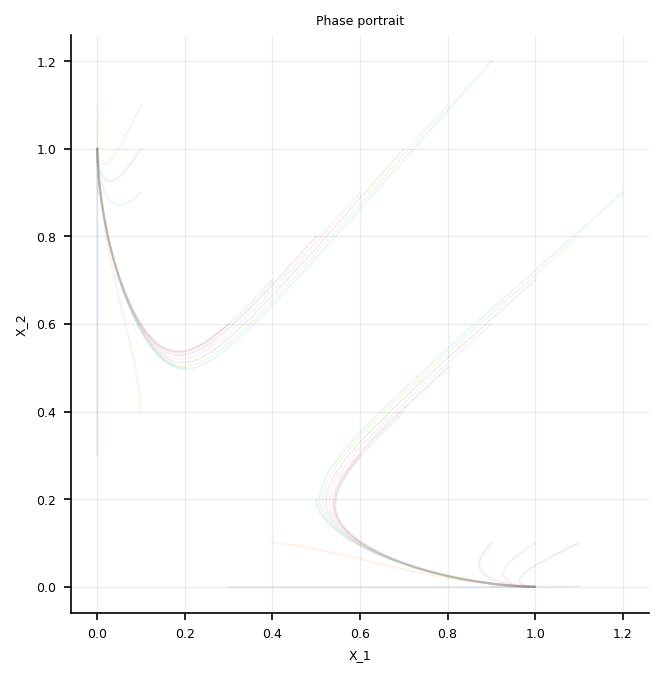

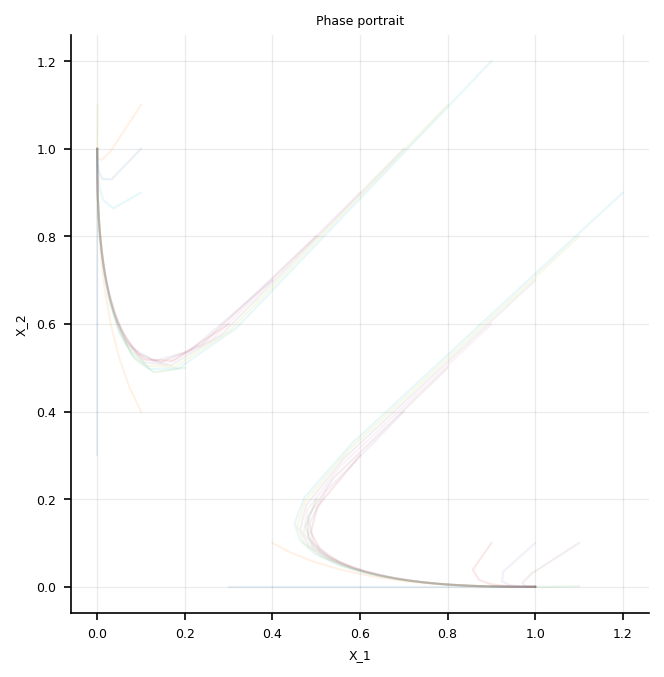

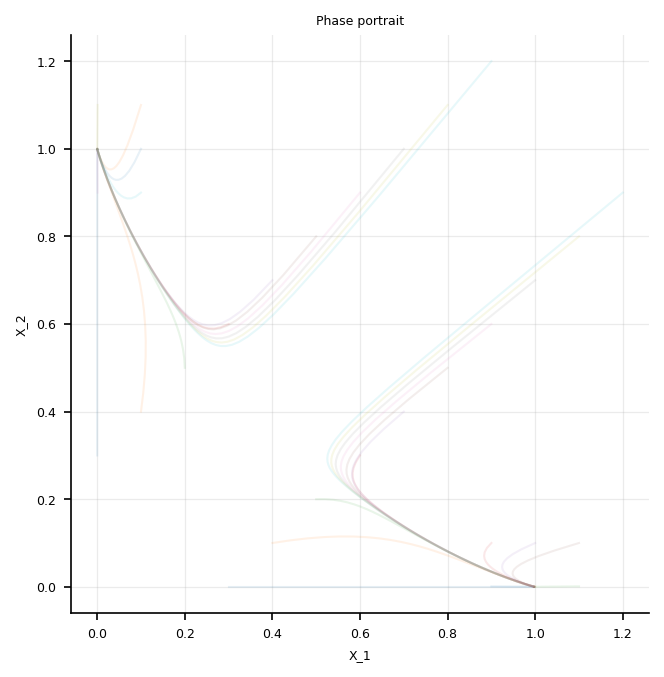

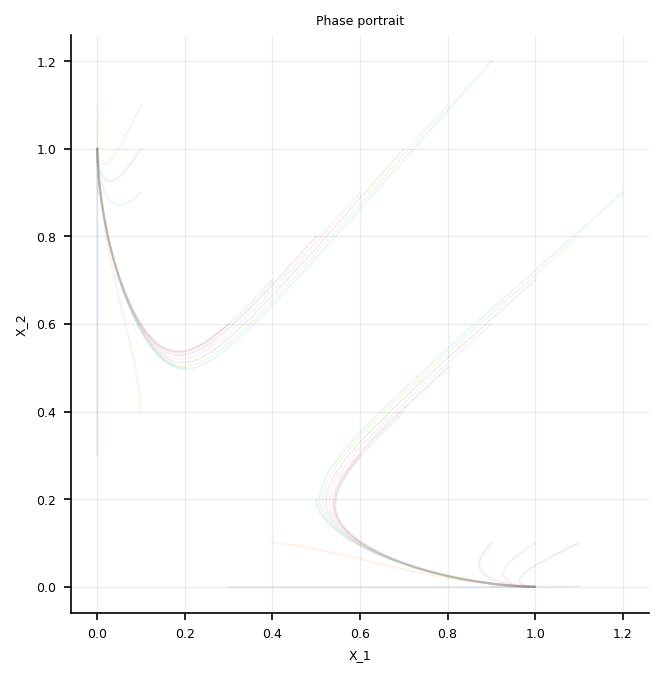

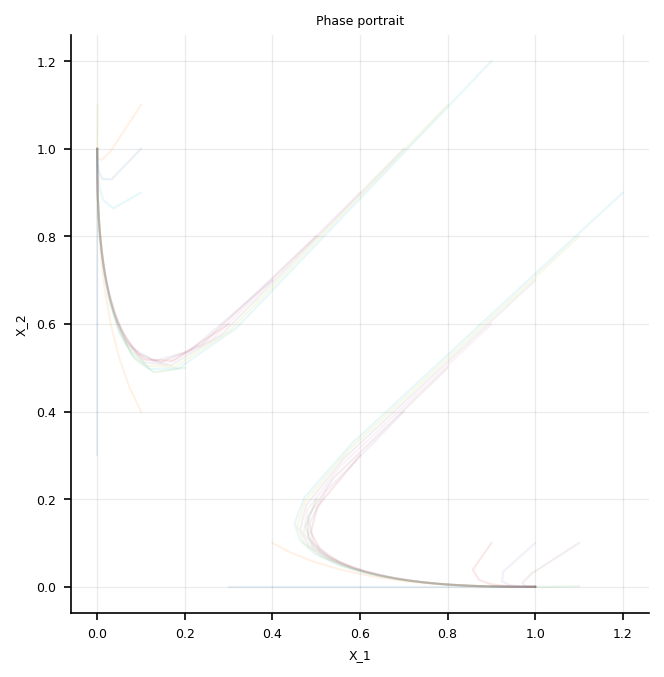

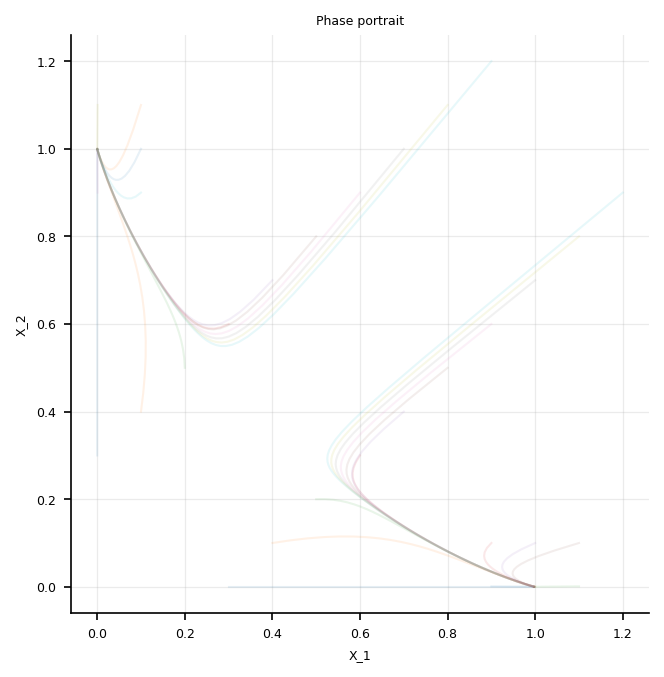

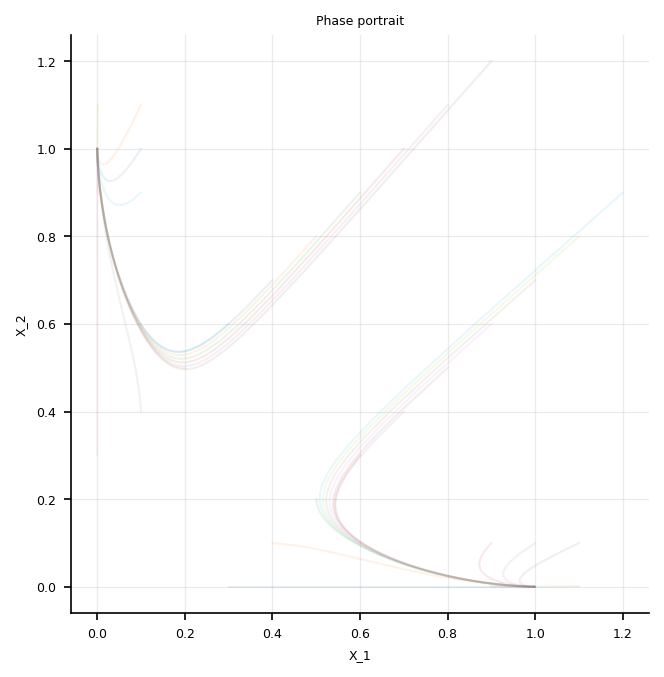


--- Inspecting run 1 ---
Best CRN loss: 0.001719164046033733
Inputs: ['u_1'] 
Species: ['X_1', 'X_2'] 
Output Species: ['X_1', 'X_2'] 
∅ ----> ∅;  [MAK(2.1519336700439453)]
X_1 ----> ∅;  [MAK(1.0, u_1)]
X_1 ----> X_1 + X_1;  [MAK(5.101456165313721)]
X_2 ----> ∅;  [MAK(1.0)]
X_2 ----> X_2 + X_2;  [MAK(5.6111836433410645)]
X_1 + X_1 ----> ∅;  [MAK(2.049760341644287)]
X_1 + X_2 ----> ∅;  [MAK(15.792623519897461)]
X_2 + X_2 ----> ∅;  [MAK(2.3048765659332275)]


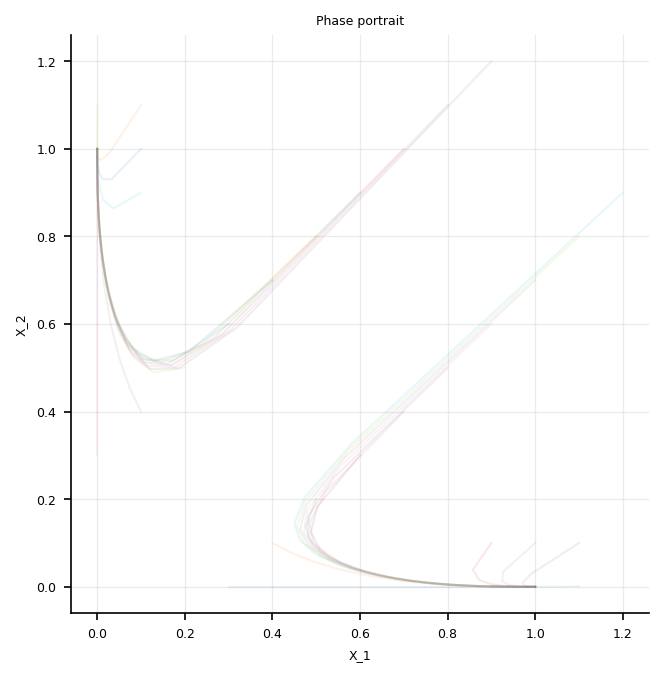


--- Inspecting run 2 ---
Best CRN loss: 0.006130260986242881
Inputs: ['u_1'] 
Species: ['X_1', 'X_2'] 
Output Species: ['X_1', 'X_2'] 
∅ ----> X_1;  [MAK(2.1070929506095126e-05)]
X_1 ----> ∅;  [MAK(1.0, u_1)]
X_1 ----> X_1 + X_1;  [MAK(3.364780902862549)]
X_2 ----> ∅;  [MAK(1.0)]
X_2 ----> X_2 + X_2;  [MAK(3.451634407043457)]
X_1 + X_1 ----> X_1;  [MAK(2.3691084384918213)]
X_1 + X_2 ----> ∅;  [MAK(3.8319945335388184)]
X_2 + X_2 ----> X_2;  [MAK(2.452059268951416)]


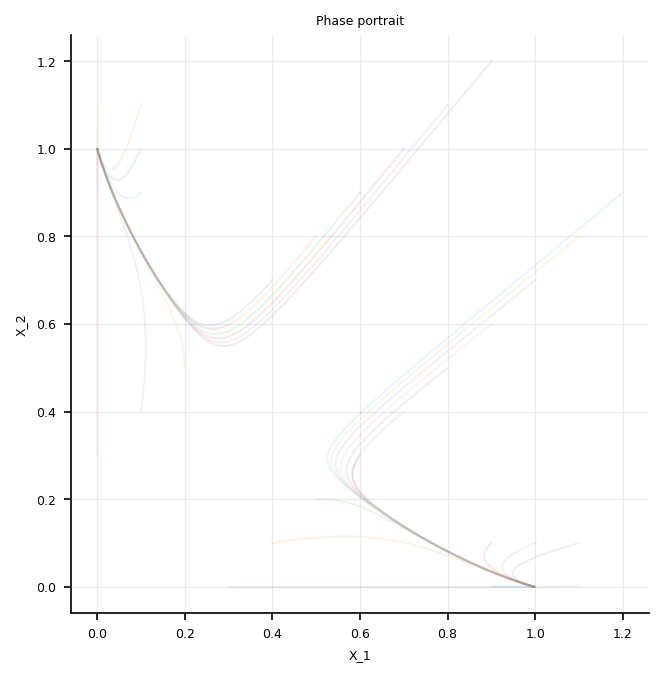

In [9]:
import os
import glob
import json
import torch
import copy
import numpy as np

from RL4CRN.utils import default_tasks  # noqa: F401
from RL4CRN.utils.default_tasks.ClassificationTaskKind import ClassificationTaskKind  # noqa: F401

from RL4CRN.utils.input_interface import (
    Configurator,
    make_task,
    make_session_and_trainer,
    print_task_summary,
)

from RL4CRN.utils.crn_builders import build_simple_IOCRN
from RL4CRN.utils.library_builders import build_MAK_library


# -------------------------
# 1) TASK-SPECIFIC SETTINGS
# -------------------------
target_directory = "/local0/rossin/git/CRN-GenerativeAI/apps_results_MAK_REINFORCE/multistability_2species_6rxns"
preset = "paper"

# Match your NEW notebook tolerances
rtol = 1e-6
atol = 1e-6

species_labels = ["X_1", "X_2"]
mak_order = 2

max_added_reactions = 6
seed = 0

t_f = 100.0
n_t = 1000

# Input list (old used u_list=[np.array([1.0])])
u_list_custom = [np.array([1.0], dtype=np.float32)]

weights_spec = "uniform"
norm = 1
relative = False
LARGE_NUMBER = 1e4

TASK_TAG = "multistability_classification"


# -------------------------
# 2) IC CONSTRUCTION (TAKEN FROM OLD SCRIPT)
# -------------------------
def build_ic_values_and_r_list():
    epsilon = 1e-3

    ic_values_diagonal_1 = [[x / 10, x / 10 - 0.3] for x in range(3, 13)]
    ic_values_diagonal_2 = [[x / 10, x / 10 + 0.3] for x in range(0, 10)]
    ic_values_cluster_1 = [
        [0.9, epsilon], [1.0, epsilon], [1.1, epsilon],
        [0.9, 0.1], [1.0, 0.1], [1.1, 0.1],
    ]
    ic_values_cluster_2 = [
        [epsilon, 0.9], [epsilon, 1.0], [epsilon, 1.1],
        [0.1, 0.9], [0.1, 1.0], [0.1, 1.1],
    ]

    # EXACT old flattening
    ic_values = (
        ic_values_diagonal_1
        + ic_values_diagonal_2
        + ic_values_cluster_1
        + ic_values_cluster_2
    )

    # EXACT old label construction (desired fixed points / classes)
    r_list = (
        [np.array([1, 0])] * len(ic_values_diagonal_1)
        + [np.array([0, 1])] * len(ic_values_diagonal_2)
        + [np.array([1, 0])] * len(ic_values_cluster_1)
        + [np.array([0, 1])] * len(ic_values_cluster_2)
    )

    return ic_values, r_list


def build_ic_r_maps_from_flat(ic_values, r_list):
    """
    Convert flat (ic_values, r_list) into the new ClassificationTaskKind format:
      ic_r_maps = [(list_of_ics_for_class, class_label), ...]
    """
    # preserve stable ordering of first appearance
    label_to_ics = {}
    label_order = []

    for icv, rv in zip(ic_values, r_list):
        key = tuple(int(x) for x in np.asarray(rv).reshape(-1))
        if key not in label_to_ics:
            label_to_ics[key] = []
            label_order.append(key)
        label_to_ics[key].append(icv)

    ic_r_maps = [(label_to_ics[k], list(k)) for k in label_order]
    return ic_r_maps


IC_VALUES, R_LIST = build_ic_values_and_r_list()
IC_R_MAPS = build_ic_r_maps_from_flat(IC_VALUES, R_LIST)


# -------------------------
# 3) HoF utilities
# -------------------------
def _extract_crn(obj):
    if hasattr(obj, "state"):
        crn = obj.state
        rew = None
        if hasattr(obj, "reward"):
            rew = getattr(obj, "reward")
        elif hasattr(obj, "perf"):
            rew = getattr(obj, "perf")
        return crn, rew
    if isinstance(obj, tuple) and len(obj) >= 1:
        return obj[0], (obj[1] if len(obj) > 1 else None)
    if isinstance(obj, dict):
        for k in ["state", "crn", "iocrn"]:
            if k in obj:
                return obj[k], obj.get("reward", obj.get("perf", None))
    return obj, None


def load_old_hof_file(hof_file: str, map_location="cpu"):
    data = torch.load(hof_file, map_location=map_location, weights_only=False)
    crns = []
    for entry in data:
        crn, rew = _extract_crn(entry)
        if crn is None:
            continue
        if getattr(crn, "last_task_info", None) is None:
            crn.last_task_info = {}
        if rew is not None:
            crn.last_task_info["reward"] = float(rew)
        crns.append(crn)
    return crns


def _safe_copy_last_task_info(info):
    if info is None:
        return {}
    try:
        return copy.deepcopy(info)
    except Exception:
        out = dict(info)
        for k, v in list(out.items()):
            if isinstance(v, np.ndarray):
                out[k] = v.copy()
        return out


class _EnvStateWrapper:
    def __init__(self, state):
        self.state = state


# -------------------------
# 4) Build trainer (classification, new interface)
# -------------------------
def build_trainer_for_multistability_classification():
    cfg = Configurator.preset(preset)
    cfg.solver.algorithm = "CVODE"
    cfg.solver.rtol = rtol
    cfg.solver.atol = atol

    cfg.train.max_added_reactions = max_added_reactions
    cfg.train.epochs = 1
    cfg.train.seed = seed

    crn, species_out = build_simple_IOCRN(
        species=species_labels,
        production_input_map={"X_1": "u_1"},
        degradation_input_map={},
        dilution_map={},
        production_map={},
        output_species=["X_1", "X_2"],
        solver=cfg.solver,
    )

    library_components = build_MAK_library(crn, species_out, order=mak_order)

    task = make_task(
        template_crn=crn,
        library_components=library_components,
        kind="classification",
        species_labels=species_out,
        params={
            # ICs derived from OLD script construction
            "ic_r_maps": IC_R_MAPS,
            "u_spec": ("custom", u_list_custom),
            "t_f": t_f,
            "n_t": n_t,
            "weights": weights_spec,
            "norm": norm,
            "relative": relative,
            "LARGE_NUMBER": LARGE_NUMBER,
        },
    )

    print_task_summary(task)
    trainer = make_session_and_trainer(cfg, task, logger=None)
    return trainer


# -------------------------
# 5) Patch solver fields on old CRNs
# -------------------------
def patch_solver_fields(crns, template_crn):
    solver = getattr(template_crn, "solver", None)
    for c in crns:
        if solver is not None:
            c.solver = solver
        c.rtol = rtol
        c.atol = atol


# -------------------------
# 6) Inject HoF + resimulate whole HoF (DO NOT override IC)
# -------------------------
def inject_hof_into_trainer(trainer, crns, max_size=None):
    if max_size is None:
        max_size = int(getattr(trainer.s.cfg.train, "hall_of_fame_size", len(crns)))

    task = trainer.s.task

    def loss_of(crn):
        info = getattr(crn, "last_task_info", {}) or {}
        r = info.get("reward", None)
        return float(r) if r is not None else float("inf")

    crns_sorted = sorted(crns, key=loss_of)[:max_size]

    for c in crns_sorted:
        old_info = getattr(c, "last_task_info", None)
        c.last_task_info = _safe_copy_last_task_info(old_info)

        # Store FULL context (including OLD-style IC lists)
        c.last_task_info["u_list"] = task.u_list
        c.last_task_info["time_horizon"] = task.time_horizon
        c.last_task_info["task_kind"] = task.kind
        c.last_task_info["ic_r_maps"] = task.params.get("ic_r_maps", None)
        c.last_task_info["ic_values"] = IC_VALUES
        c.last_task_info["r_list"] = [r.tolist() for r in R_LIST]

    trainer.s.mult_env.hall_of_fame = [_EnvStateWrapper(c) for c in crns_sorted]


def resimulate_whole_hof_and_replace(trainer):
    hof_crns = [item.state for item in trainer.s.mult_env.hall_of_fame]
    if not hof_crns:
        return []

    patch_solver_fields(hof_crns, trainer.s.task.template_crn)

    task = trainer.s.task
    # IMPORTANT: no ic override — classification uses task.params['ic_r_maps']
    crns_new = trainer.resimulate(hof_crns, task=task)

    wrapped = []
    for c in crns_new:
        if getattr(c, "last_task_info", None) is None:
            c.last_task_info = {}
        c.last_task_info["u_list"] = task.u_list
        c.last_task_info["time_horizon"] = task.time_horizon
        c.last_task_info["task_kind"] = task.kind
        c.last_task_info["ic_r_maps"] = task.params.get("ic_r_maps", None)
        c.last_task_info["ic_values"] = IC_VALUES
        c.last_task_info["r_list"] = [r.tolist() for r in R_LIST]
        wrapped.append(_EnvStateWrapper(c))

    trainer.s.mult_env.hall_of_fame = wrapped
    return crns_new


# -------------------------
# 7) Convert: one trainer per HoF file
# -------------------------
def convert_one_app_many_trainers(target_directory: str):
    hof_dir = os.path.join(target_directory, "hof")
    hof_files = sorted(glob.glob(os.path.join(hof_dir, "hall_of_fame_*.pth")))
    if not hof_files:
        raise FileNotFoundError(f"No HoF files found: {os.path.join(hof_dir, 'hall_of_fame_*.pth')}")

    base = os.path.basename(os.path.normpath(target_directory))
    trainers = []

    for i, hof_file in enumerate(hof_files):
        trainer = build_trainer_for_multistability_classification()

        crns = load_old_hof_file(hof_file, map_location="cpu")
        print(f"[run {i}] Loaded {len(crns)} CRNs from {os.path.basename(hof_file)}")

        inject_hof_into_trainer(trainer, crns, max_size=trainer.s.cfg.train.hall_of_fame_size)

        crns_resim = resimulate_whole_hof_and_replace(trainer)
        print(f"[run {i}] Resimulated HoF CRNs: {len(crns_resim)}")

        ckpt_path = os.path.join(target_directory, f"{base}_run{i}.pkl")
        trainer.save(ckpt_path)

        meta = {
            "target_directory": target_directory,
            "hof_file": hof_file,
            "n_loaded_crns": len(crns),
            "n_resimulated_crns": len(crns_resim),
            "task_tag": TASK_TAG,
            "preset": preset,
            "species_labels": species_labels,
            "mak_order": mak_order,
            "t_f": t_f,
            "n_t": n_t,
            "u_list_custom": [u.tolist() for u in u_list_custom],
            "n_ic_values": len(IC_VALUES),
            "weights": weights_spec,
            "norm": norm,
            "relative": relative,
            "LARGE_NUMBER": LARGE_NUMBER,
            "solver": {"algorithm": "CVODE", "rtol": rtol, "atol": atol},
            "max_added_reactions": max_added_reactions,
            "seed": seed,
            "checkpoint_path": ckpt_path,
            "run_index": i,
        }
        with open(os.path.join(target_directory, f"{base}_run{i}.meta.json"), "w") as f:
            json.dump(meta, f, indent=2)

        print(f"[run {i}] Saved trainer checkpoint -> {ckpt_path}")
        trainers.append(trainer)

    return trainers


if __name__ == "__main__":
    trainers = convert_one_app_many_trainers(target_directory)
    import matplotlib.pyplot as plt
    for i, tr in enumerate(trainers):
        print(f"\n--- Inspecting run {i} ---")
        tr.inspect_best(plot=True)
        plt.show()

DR_1

Task: dose_response
time_horizon: (1000,) [0..100.0]
num scenarios: 27
first 3 u: [array([0.], dtype=float32), array([0.01], dtype=float32), array([0.02], dtype=float32)]

[run 0] Loaded 30 CRNs from hall_of_fame_2026-02-25 18:03:28.pth
[run 0] Resimulated HoF CRNs: 30
Saved checkpoint: /local0/rossin/git/CRN-GenerativeAI/apps_zhou/apps_zhou/1_added_reactions/1_added_reactions_run0.pkl
[run 0] Saved trainer checkpoint -> /local0/rossin/git/CRN-GenerativeAI/apps_zhou/apps_zhou/1_added_reactions/1_added_reactions_run0.pkl


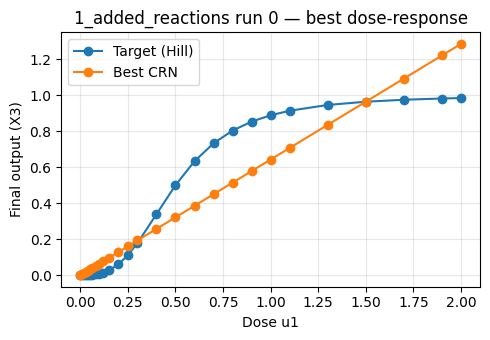


--- Inspecting run 0 ---
Best CRN loss: 0.12050509857082835
Inputs: ['u_1'] 
Species: ['X_1', 'X_2', 'X_3'] 
Output Species: ['X_3'] 
∅ ----> X_1;  [MAK(1.0, u_1)]
X_1 ----> ∅;  [MAK(1.0)]
X_1 ----> X_3;  [MAK(1.800041913986206)]
X_2 ----> ∅;  [MAK(1.0)]
X_3 ----> ∅;  [MAK(1.0)]


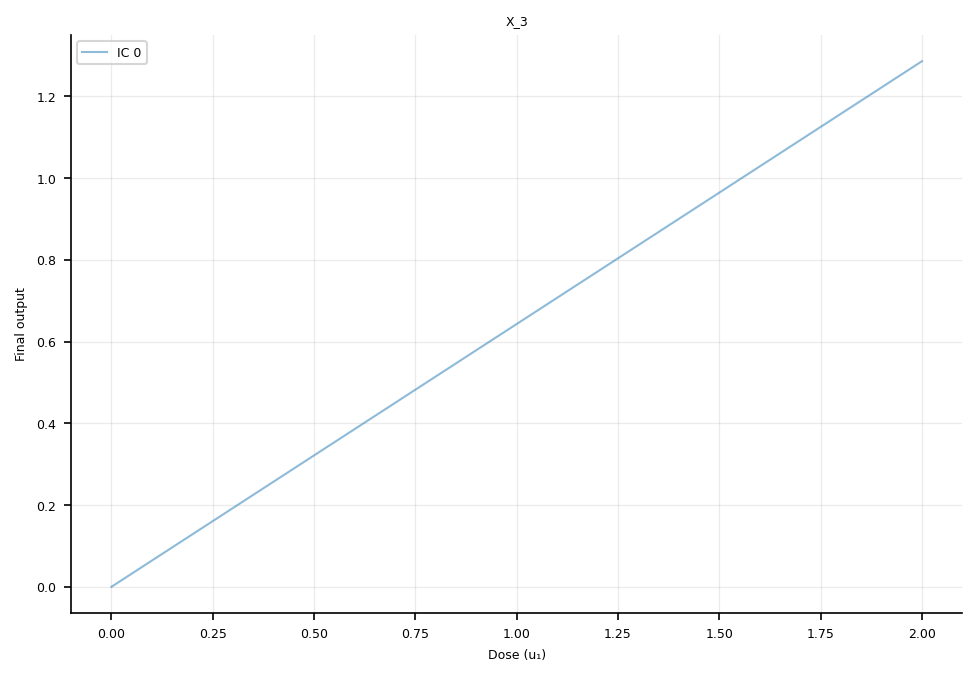

In [10]:
import os
import glob
import json
import torch
import copy
import numpy as np
import matplotlib.pyplot as plt

# Ensure TaskKinds are registered
from RL4CRN.utils import default_tasks  # noqa: F401
from RL4CRN.utils.default_tasks.DoseResponseTaskKind import DoseResponseTaskKind  # noqa: F401

from RL4CRN.utils.input_interface import (
    Configurator,
    make_task,
    make_session_and_trainer,
    print_task_summary,
)

from RL4CRN.utils.crn_builders import build_simple_IOCRN
from RL4CRN.utils.library_builders import build_MAK_library


# -------------------------
# 1) TASK-SPECIFIC SETTINGS (from OLD script)
# -------------------------
target_directory = "/local0/rossin/git/CRN-GenerativeAI/apps_zhou/apps_zhou/1_added_reactions"
preset = "paper"

# Deterministic solver tolerances (use 1e-10 like your dose-response tutorial)
rtol = 1e-10
atol = 1e-10

# Template/library
species_labels = ["X_1", "X_2", "X_3"]
mak_order = 2

# Wiring knobs
max_added_reactions = 1
seed = 0

# Time horizon
t_f = 100
n_t = 1000

# Inputs: use the EXACT chosen_u_values list from old code
chosen_u_values = [
    0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.08, 0.1, 0.12, 0.15,
    0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.3,
    1.5, 1.7, 1.9, 2.0
]
u_list_custom = [np.array([u], dtype=np.float32) for u in chosen_u_values]

# Target dose-response: EXACT old hill function
def hill_function_scalar(u: float) -> float:
    kd = 0.5
    max_production = 1.0
    n = 3.0
    return float(max_production * (u**n) / (kd**n + u**n))

# Task target callable (TaskKind resolves u_1 by name)
target_fn = (lambda u_1: hill_function_scalar(float(u_1)))

# IC: old used zeros
ic_spec = ("values", [[0.0, 0.0, 0.0]])

# Weights: old transient profile
weights_spec = "transient"

# Other knobs
norm = 1
LARGE_NUMBER = 1e4
relative = False  # old passed relative=False

TASK_TAG = "dose_response_hill"


# -------------------------
# 2) Generic helpers (HoF loading + injection)
# -------------------------
def _extract_crn(obj):
    if hasattr(obj, "state"):
        crn = obj.state
        rew = None
        if hasattr(obj, "reward"):
            rew = getattr(obj, "reward")
        elif hasattr(obj, "perf"):
            rew = getattr(obj, "perf")
        return crn, rew
    if isinstance(obj, tuple) and len(obj) >= 1:
        return obj[0], (obj[1] if len(obj) > 1 else None)
    if isinstance(obj, dict):
        for k in ["state", "crn", "iocrn"]:
            if k in obj:
                return obj[k], obj.get("reward", obj.get("perf", None))
    return obj, None


def load_old_hof_file(hof_file, map_location="cpu"):
    data = torch.load(hof_file, map_location=map_location, weights_only=False)
    crns = []
    for entry in data:
        crn, rew = _extract_crn(entry)
        if crn is None:
            continue
        if getattr(crn, "last_task_info", None) is None:
            crn.last_task_info = {}
        if rew is not None:
            crn.last_task_info["reward"] = float(rew)
        crns.append(crn)
    return crns


class _EnvStateWrapper:
    def __init__(self, state):
        self.state = state


def _safe_copy_last_task_info(info):
    if info is None:
        return {}
    try:
        return copy.deepcopy(info)
    except Exception:
        out = dict(info)
        for k, v in list(out.items()):
            if isinstance(v, np.ndarray):
                out[k] = v.copy()
        return out


def inject_hof_into_trainer(trainer, crns, max_size=None):
    if max_size is None:
        max_size = int(getattr(trainer.s.cfg.train, "hall_of_fame_size", len(crns)))

    task = trainer.s.task

    def loss_of(crn):
        info = getattr(crn, "last_task_info", {}) or {}
        r = info.get("reward", None)
        return float(r) if r is not None else float("inf")

    crns_sorted = sorted(crns, key=loss_of)[:max_size]

    for c in crns_sorted:
        old_info = getattr(c, "last_task_info", None)
        c.last_task_info = _safe_copy_last_task_info(old_info)

        # context for plotting/inspection
        c.last_task_info["u_list"] = task.u_list
        c.last_task_info["time_horizon"] = task.time_horizon
        c.last_task_info["task_kind"] = task.kind
        c.last_task_info["target_fn"] = target_fn

    trainer.s.mult_env.hall_of_fame = [_EnvStateWrapper(c) for c in crns_sorted]


# -------------------------
# 3) Build trainer for dose-response task (new interface)
# -------------------------
def build_trainer_for_dose_response():
    cfg = Configurator.preset(preset)

    cfg.solver.algorithm = "CVODE"
    cfg.solver.rtol = rtol
    cfg.solver.atol = atol

    cfg.train.max_added_reactions = max_added_reactions
    cfg.train.epochs = 1
    cfg.train.seed = seed

    # Template IO/CRN: same structure as old: X1 produced by u1, output X3
    # Old also had degradation reactions for X1,X2,X3 in the template; in new pipeline
    # we keep dilution_map empty (as in tutorial), and rely on library search.
    crn, species_out = build_simple_IOCRN(
        species=species_labels,
        production_input_map={"X_1": "u_1"},
        degradation_input_map={},
        dilution_map={},
        output_species="X_3",
        solver=cfg.solver,
    )

    library_components = build_MAK_library(crn, species_out, order=mak_order)

    # We pass explicit u_list to match old chosen_u_values exactly
    task = make_task(
        template_crn=crn,
        library_components=library_components,
        kind="dose_response",
        species_labels=species_out,
        params={
            "t_f": t_f,
            "n_t": n_t,
            "ic": ic_spec,
            "weights": weights_spec,
            "u_spec": ("custom", u_list_custom),
            "target": target_fn,
            "norm": norm,
            "LARGE_NUMBER": LARGE_NUMBER,
            "relative": relative,
        },
    )

    print_task_summary(task)
    trainer = make_session_and_trainer(cfg, task, logger=None)
    return trainer


# -------------------------
# 4) Patch solver fields on old CRNs (prevents missing solver issues)
# -------------------------
def patch_solver_fields(crns, template_crn):
    solver = getattr(template_crn, "solver", None)
    for c in crns:
        if solver is not None:
            c.solver = solver
        c.rtol = rtol
        c.atol = atol


# -------------------------
# 5) Resimulate whole HoF + replace (so plots are not empty)
# -------------------------
def resimulate_whole_hof_and_replace(trainer):
    hof_crns = [item.state for item in trainer.s.mult_env.hall_of_fame]
    if not hof_crns:
        return []

    patch_solver_fields(hof_crns, trainer.s.task.template_crn)

    task = trainer.s.task
    crns_new = trainer.resimulate(
        hof_crns,
        task=task,
        ic=task.ic_spec,
        weights=task.weights_spec,
        u_list=task.u_list,
    )

    wrapped = []
    for c in crns_new:
        if getattr(c, "last_task_info", None) is None:
            c.last_task_info = {}
        c.last_task_info["u_list"] = task.u_list
        c.last_task_info["time_horizon"] = task.time_horizon
        c.last_task_info["task_kind"] = task.kind
        c.last_task_info["target_fn"] = target_fn
        wrapped.append(_EnvStateWrapper(c))

    trainer.s.mult_env.hall_of_fame = wrapped
    return crns_new


# -------------------------
# 6) Plot dose-response curve for best CRN (end)
# -------------------------
def plot_best_dose_response(trainer, title="Best dose response"):
    best = trainer.best_crn()
    if best is None:
        print("No best CRN found (HoF empty).")
        return

    task = trainer.s.task
    u_vals = np.array([float(u[0]) for u in task.u_list], dtype=float)

    # attempt to read final outputs from last_task_info (preferred)
    y_final = None
    info = getattr(best, "last_task_info", {}) or {}
    outs = info.get("outputs", None)
    if outs is not None and len(outs) == len(task.u_list):
        try:
            y_final = np.array([float(o[0, -1]) for o in outs], dtype=float)
        except Exception:
            y_final = None

    # fallback: re-run deterministic transient responses to get last output
    if y_final is None:
        y_final = []
        for u in task.u_list:
            # IC list for the state (TaskSpec's IC object)
            x0_list = task.ic.get_ic(best)
            t, x_list, y_list, _ = best.transient_response([u], x0_list[:1], task.time_horizon, LARGE_NUMBER=LARGE_NUMBER)
            # y_list is list over scenarios; take scenario 0, output 0, last time
            y_final.append(float(y_list[0][0, -1]))
        y_final = np.asarray(y_final, dtype=float)

    # target curve
    y_target = np.array([hill_function_scalar(u) for u in u_vals], dtype=float)

    plt.figure(figsize=(5.0, 3.5))
    plt.plot(u_vals, y_target, marker="o", linewidth=1.5, label="Target (Hill)")
    plt.plot(u_vals, y_final, marker="o", linewidth=1.5, label="Best CRN")
    plt.xlabel("Dose u1")
    plt.ylabel("Final output (X3)")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


# -------------------------
# 7) Conversion: ONE trainer per HoF file
# -------------------------
def convert_one_app_many_trainers(target_directory: str):
    hof_dir = os.path.join(target_directory, "hof")
    hof_files = sorted(glob.glob(os.path.join(hof_dir, "hall_of_fame_*.pth")))
    if not hof_files:
        raise FileNotFoundError(f"No HoF files found: {os.path.join(hof_dir, 'hall_of_fame_*.pth')}")

    base = os.path.basename(os.path.normpath(target_directory))
    trainers = []

    for i, hof_file in enumerate(hof_files):
        trainer = build_trainer_for_dose_response()

        crns = load_old_hof_file(hof_file, map_location="cpu")
        print(f"[run {i}] Loaded {len(crns)} CRNs from {os.path.basename(hof_file)}")

        inject_hof_into_trainer(trainer, crns, max_size=trainer.s.cfg.train.hall_of_fame_size)

        crns_resim = resimulate_whole_hof_and_replace(trainer)
        print(f"[run {i}] Resimulated HoF CRNs: {len(crns_resim)}")

        ckpt_path = os.path.join(target_directory, f"{base}_run{i}.pkl")
        trainer.save(ckpt_path)

        meta = {
            "target_directory": target_directory,
            "hof_file": hof_file,
            "n_loaded_crns": len(crns),
            "n_resimulated_crns": len(crns_resim),
            "task_tag": TASK_TAG,
            "preset": preset,
            "species_labels": species_labels,
            "mak_order": mak_order,
            "t_f": t_f,
            "n_t": n_t,
            "ic": ic_spec,
            "u_values": chosen_u_values,
            "weights": weights_spec,
            "norm": norm,
            "relative": relative,
            "LARGE_NUMBER": LARGE_NUMBER,
            "solver": {"algorithm": "CVODE", "rtol": rtol, "atol": atol},
            "max_added_reactions": max_added_reactions,
            "seed": seed,
            "checkpoint_path": ckpt_path,
            "run_index": i,
        }
        with open(os.path.join(target_directory, f"{base}_run{i}.meta.json"), "w") as f:
            json.dump(meta, f, indent=2)

        print(f"[run {i}] Saved trainer checkpoint -> {ckpt_path}")

        # PLOT at the end of each run (as requested)
        plot_best_dose_response(trainer, title=f"{base} run {i} — best dose-response")

        trainers.append(trainer)

    return trainers


if __name__ == "__main__":
    trainers = convert_one_app_many_trainers(target_directory)
    import matplotlib.pyplot as plt
    for i, tr in enumerate(trainers):
        print(f"\n--- Inspecting run {i} ---")
        tr.inspect_best(plot=True)
        plt.show()

2

Task: dose_response
time_horizon: (1000,) [0..100.0]
num scenarios: 27
first 3 u: [array([0.], dtype=float32), array([0.01], dtype=float32), array([0.02], dtype=float32)]

[run 0] Loaded 30 CRNs from hall_of_fame_2026-02-25 18:04:24.pth
[run 0] Resimulated HoF CRNs: 30
Saved checkpoint: /local0/rossin/git/CRN-GenerativeAI/apps_zhou/apps_zhou/2_added_reactions/2_added_reactions_run0.pkl
[run 0] Saved trainer checkpoint -> /local0/rossin/git/CRN-GenerativeAI/apps_zhou/apps_zhou/2_added_reactions/2_added_reactions_run0.pkl


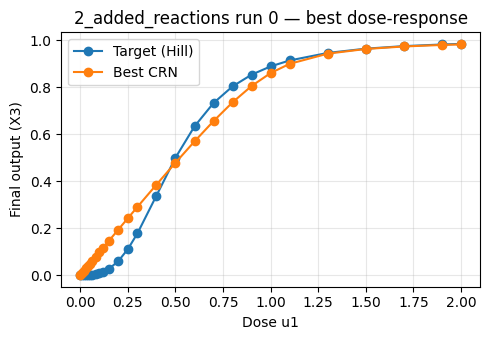


--- Inspecting run 0 ---
Best CRN loss: 0.05290428503106039
Inputs: ['u_1'] 
Species: ['X_1', 'X_2', 'X_3'] 
Output Species: ['X_3'] 
∅ ----> X_1;  [MAK(1.0, u_1)]
X_1 ----> ∅;  [MAK(1.0)]
X_1 ----> X_3;  [MAK(42.88805389404297)]
X_2 ----> ∅;  [MAK(1.0)]
X_3 ----> ∅;  [MAK(1.0)]
X_1 + X_3 ----> X_1 + X_1;  [MAK(42.672393798828125)]


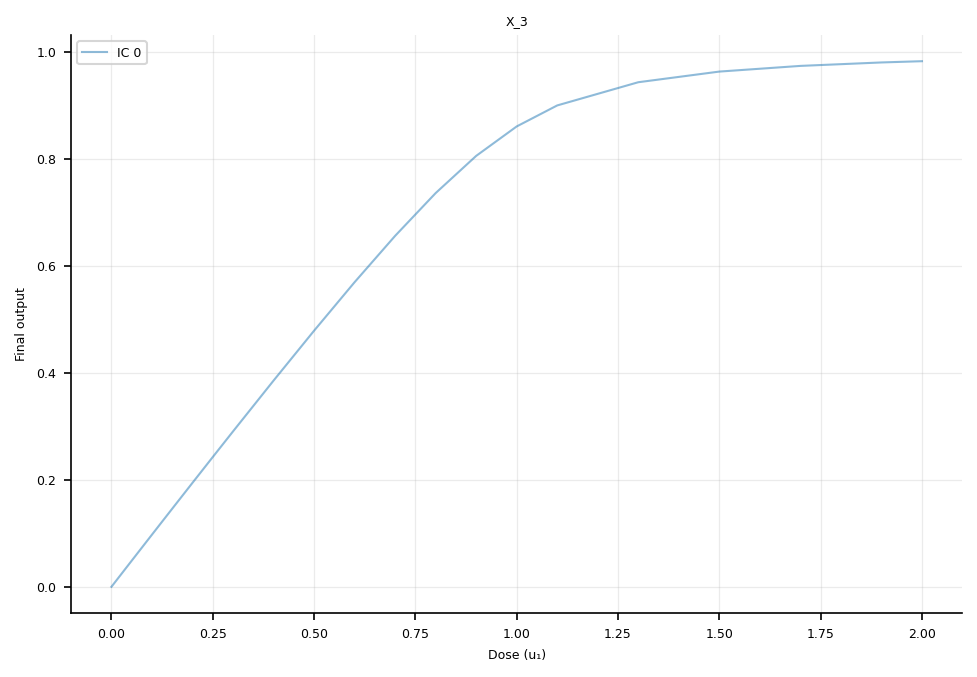

In [11]:
import os
import glob
import json
import torch
import copy
import numpy as np
import matplotlib.pyplot as plt

# Ensure TaskKinds are registered
from RL4CRN.utils import default_tasks  # noqa: F401
from RL4CRN.utils.default_tasks.DoseResponseTaskKind import DoseResponseTaskKind  # noqa: F401

from RL4CRN.utils.input_interface import (
    Configurator,
    make_task,
    make_session_and_trainer,
    print_task_summary,
)

from RL4CRN.utils.crn_builders import build_simple_IOCRN
from RL4CRN.utils.library_builders import build_MAK_library


# -------------------------
# 1) TASK-SPECIFIC SETTINGS (from OLD script: 2_added_reactions)
# -------------------------
target_directory = "/local0/rossin/git/CRN-GenerativeAI/apps_zhou/apps_zhou/2_added_reactions"
preset = "paper"

# Deterministic solver tolerances (use 1e-10 like your dose-response tutorial)
rtol = 1e-10
atol = 1e-10

# Template/library
species_labels = ["X_1", "X_2", "X_3"]
mak_order = 2

# Wiring knobs
max_added_reactions = 2          # <-- DIFFERENCE vs 1_added_reactions
seed = 0

# Time horizon
t_f = 100
n_t = 1000

# Inputs: EXACT chosen_u_values list
chosen_u_values = [
    0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.08, 0.1, 0.12, 0.15,
    0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.3,
    1.5, 1.7, 1.9, 2.0
]
u_list_custom = [np.array([u], dtype=np.float32) for u in chosen_u_values]

# Target dose-response: EXACT hill function from old code
def hill_function_scalar(u: float) -> float:
    kd = 0.5
    max_production = 1.0
    n = 3.0
    return float(max_production * (u**n) / (kd**n + u**n))

# Task target callable (TaskKind resolves u_1 by name)
target_fn = (lambda u_1: hill_function_scalar(float(u_1)))

# IC: old used zeros
ic_spec = ("values", [[0.0, 0.0, 0.0]])

# Weights: old transient profile
weights_spec = "transient"

# Other knobs
norm = 1
LARGE_NUMBER = 1e4
relative = False

TASK_TAG = "dose_response_hill"


# -------------------------
# 2) Generic helpers (HoF loading + injection)
# -------------------------
def _extract_crn(obj):
    if hasattr(obj, "state"):
        crn = obj.state
        rew = None
        if hasattr(obj, "reward"):
            rew = getattr(obj, "reward")
        elif hasattr(obj, "perf"):
            rew = getattr(obj, "perf")
        return crn, rew
    if isinstance(obj, tuple) and len(obj) >= 1:
        return obj[0], (obj[1] if len(obj) > 1 else None)
    if isinstance(obj, dict):
        for k in ["state", "crn", "iocrn"]:
            if k in obj:
                return obj[k], obj.get("reward", obj.get("perf", None))
    return obj, None


def load_old_hof_file(hof_file, map_location="cpu"):
    data = torch.load(hof_file, map_location=map_location, weights_only=False)
    crns = []
    for entry in data:
        crn, rew = _extract_crn(entry)
        if crn is None:
            continue
        if getattr(crn, "last_task_info", None) is None:
            crn.last_task_info = {}
        if rew is not None:
            crn.last_task_info["reward"] = float(rew)
        crns.append(crn)
    return crns


class _EnvStateWrapper:
    def __init__(self, state):
        self.state = state


def _safe_copy_last_task_info(info):
    if info is None:
        return {}
    try:
        return copy.deepcopy(info)
    except Exception:
        out = dict(info)
        for k, v in list(out.items()):
            if isinstance(v, np.ndarray):
                out[k] = v.copy()
        return out


def inject_hof_into_trainer(trainer, crns, max_size=None):
    if max_size is None:
        max_size = int(getattr(trainer.s.cfg.train, "hall_of_fame_size", len(crns)))

    task = trainer.s.task

    def loss_of(crn):
        info = getattr(crn, "last_task_info", {}) or {}
        r = info.get("reward", None)
        return float(r) if r is not None else float("inf")

    crns_sorted = sorted(crns, key=loss_of)[:max_size]

    for c in crns_sorted:
        old_info = getattr(c, "last_task_info", None)
        c.last_task_info = _safe_copy_last_task_info(old_info)

        # context for plotting/inspection
        c.last_task_info["u_list"] = task.u_list
        c.last_task_info["time_horizon"] = task.time_horizon
        c.last_task_info["task_kind"] = task.kind
        c.last_task_info["target_fn"] = target_fn

    trainer.s.mult_env.hall_of_fame = [_EnvStateWrapper(c) for c in crns_sorted]


# -------------------------
# 3) Build trainer for dose-response task (new interface)
# -------------------------
def build_trainer_for_dose_response():
    cfg = Configurator.preset(preset)

    cfg.solver.algorithm = "CVODE"
    cfg.solver.rtol = rtol
    cfg.solver.atol = atol

    cfg.train.max_added_reactions = max_added_reactions
    cfg.train.epochs = 1
    cfg.train.seed = seed

    crn, species_out = build_simple_IOCRN(
        species=species_labels,
        production_input_map={"X_1": "u_1"},
        degradation_input_map={},
        dilution_map={},
        output_species="X_3",
        solver=cfg.solver,
    )

    library_components = build_MAK_library(crn, species_out, order=mak_order)

    task = make_task(
        template_crn=crn,
        library_components=library_components,
        kind="dose_response",
        species_labels=species_out,
        params={
            "t_f": t_f,
            "n_t": n_t,
            "ic": ic_spec,
            "weights": weights_spec,
            "u_spec": ("custom", u_list_custom),
            "target": target_fn,
            "norm": norm,
            "LARGE_NUMBER": LARGE_NUMBER,
            "relative": relative,
        },
    )

    print_task_summary(task)
    trainer = make_session_and_trainer(cfg, task, logger=None)
    return trainer


# -------------------------
# 4) Patch solver fields on old CRNs (prevents missing solver issues)
# -------------------------
def patch_solver_fields(crns, template_crn):
    solver = getattr(template_crn, "solver", None)
    for c in crns:
        if solver is not None:
            c.solver = solver
        c.rtol = rtol
        c.atol = atol


# -------------------------
# 5) Resimulate whole HoF + replace (so plots are not empty)
# -------------------------
def resimulate_whole_hof_and_replace(trainer):
    hof_crns = [item.state for item in trainer.s.mult_env.hall_of_fame]
    if not hof_crns:
        return []

    patch_solver_fields(hof_crns, trainer.s.task.template_crn)

    task = trainer.s.task
    crns_new = trainer.resimulate(
        hof_crns,
        task=task,
        ic=task.ic_spec,
        weights=task.weights_spec,
        u_list=task.u_list,
    )

    wrapped = []
    for c in crns_new:
        if getattr(c, "last_task_info", None) is None:
            c.last_task_info = {}
        c.last_task_info["u_list"] = task.u_list
        c.last_task_info["time_horizon"] = task.time_horizon
        c.last_task_info["task_kind"] = task.kind
        c.last_task_info["target_fn"] = target_fn
        wrapped.append(_EnvStateWrapper(c))

    trainer.s.mult_env.hall_of_fame = wrapped
    return crns_new


# -------------------------
# 6) Plot dose-response curve for best CRN (end)
# -------------------------
def plot_best_dose_response(trainer, title="Best dose response"):
    best = trainer.best_crn()
    if best is None:
        print("No best CRN found (HoF empty).")
        return

    task = trainer.s.task
    u_vals = np.array([float(u[0]) for u in task.u_list], dtype=float)

    # Prefer using cached outputs if available
    y_final = None
    info = getattr(best, "last_task_info", {}) or {}
    outs = info.get("outputs", None)
    if outs is not None and len(outs) == len(task.u_list):
        try:
            y_final = np.array([float(o[0, -1]) for o in outs], dtype=float)
        except Exception:
            y_final = None

    # Fallback: deterministic re-sim per scenario
    if y_final is None:
        y_final = []
        x0_list_full = task.ic.get_ic(best)
        x0 = x0_list_full[0] if isinstance(x0_list_full, list) else x0_list_full
        for u in task.u_list:
            t, x_list, y_list, _ = best.transient_response([u], [x0], task.time_horizon, LARGE_NUMBER=LARGE_NUMBER)
            y_final.append(float(y_list[0][0, -1]))
        y_final = np.asarray(y_final, dtype=float)

    y_target = np.array([hill_function_scalar(u) for u in u_vals], dtype=float)

    plt.figure(figsize=(5.0, 3.5))
    plt.plot(u_vals, y_target, marker="o", linewidth=1.5, label="Target (Hill)")
    plt.plot(u_vals, y_final, marker="o", linewidth=1.5, label="Best CRN")
    plt.xlabel("Dose u1")
    plt.ylabel("Final output (X3)")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


# -------------------------
# 7) Conversion: ONE trainer per HoF file
# -------------------------
def convert_one_app_many_trainers(target_directory: str):
    hof_dir = os.path.join(target_directory, "hof")
    hof_files = sorted(glob.glob(os.path.join(hof_dir, "hall_of_fame_*.pth")))
    if not hof_files:
        raise FileNotFoundError(f"No HoF files found: {os.path.join(hof_dir, 'hall_of_fame_*.pth')}")

    base = os.path.basename(os.path.normpath(target_directory))
    trainers = []

    for i, hof_file in enumerate(hof_files):
        trainer = build_trainer_for_dose_response()

        crns = load_old_hof_file(hof_file, map_location="cpu")
        print(f"[run {i}] Loaded {len(crns)} CRNs from {os.path.basename(hof_file)}")

        inject_hof_into_trainer(trainer, crns, max_size=trainer.s.cfg.train.hall_of_fame_size)

        crns_resim = resimulate_whole_hof_and_replace(trainer)
        print(f"[run {i}] Resimulated HoF CRNs: {len(crns_resim)}")

        ckpt_path = os.path.join(target_directory, f"{base}_run{i}.pkl")
        trainer.save(ckpt_path)

        meta = {
            "target_directory": target_directory,
            "hof_file": hof_file,
            "n_loaded_crns": len(crns),
            "n_resimulated_crns": len(crns_resim),
            "task_tag": TASK_TAG,
            "preset": preset,
            "species_labels": species_labels,
            "mak_order": mak_order,
            "t_f": t_f,
            "n_t": n_t,
            "ic": ic_spec,
            "u_values": chosen_u_values,
            "weights": weights_spec,
            "norm": norm,
            "relative": relative,
            "LARGE_NUMBER": LARGE_NUMBER,
            "solver": {"algorithm": "CVODE", "rtol": rtol, "atol": atol},
            "max_added_reactions": max_added_reactions,
            "seed": seed,
            "checkpoint_path": ckpt_path,
            "run_index": i,
        }
        with open(os.path.join(target_directory, f"{base}_run{i}.meta.json"), "w") as f:
            json.dump(meta, f, indent=2)

        print(f"[run {i}] Saved trainer checkpoint -> {ckpt_path}")

        # Plot at the end of each run
        plot_best_dose_response(trainer, title=f"{base} run {i} — best dose-response")

        trainers.append(trainer)

    return trainers


if __name__ == "__main__":
    trainers = convert_one_app_many_trainers(target_directory)
    for i, tr in enumerate(trainers):
        print(f"\n--- Inspecting run {i} ---")
        tr.inspect_best(plot=True)
        plt.show()
    

Task: dose_response
time_horizon: (1000,) [0..100.0]
num scenarios: 27
first 3 u: [array([0.], dtype=float32), array([0.01], dtype=float32), array([0.02], dtype=float32)]

[run 0] Loaded 30 CRNs from hall_of_fame_2026-02-25 18:05:39.pth
[run 0] Resimulated HoF CRNs: 30
Saved checkpoint: /local0/rossin/git/CRN-GenerativeAI/apps_zhou/apps_zhou/3_added_reactions/3_added_reactions_run0.pkl
[run 0] Saved trainer checkpoint -> /local0/rossin/git/CRN-GenerativeAI/apps_zhou/apps_zhou/3_added_reactions/3_added_reactions_run0.pkl


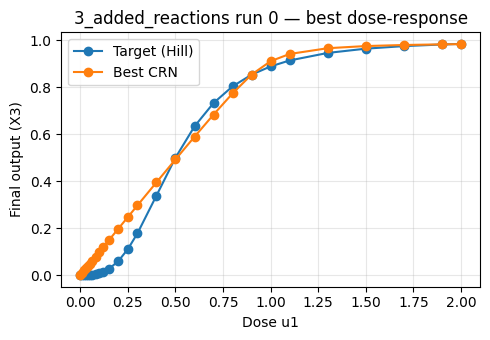


--- Inspecting run 0 ---
Best CRN loss: 0.0508866835028826
Inputs: ['u_1'] 
Species: ['X_1', 'X_2', 'X_3'] 
Output Species: ['X_3'] 
∅ ----> X_1;  [MAK(1.0, u_1)]
X_1 ----> ∅;  [MAK(1.0)]
X_1 ----> X_1 + X_2;  [MAK(1.8995673656463623)]
X_1 ----> X_3 + X_3;  [MAK(0.9853256344795227)]
X_2 ----> ∅;  [MAK(1.0)]
X_3 ----> ∅;  [MAK(1.0)]
X_1 + X_3 ----> X_1 + X_1;  [MAK(1.9848089218139648)]


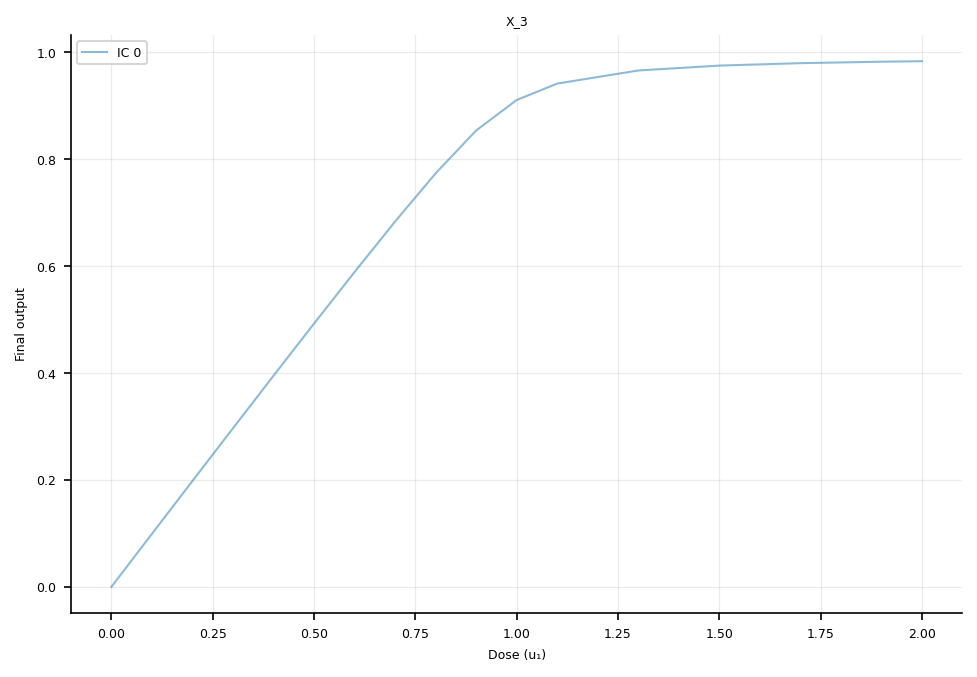

In [12]:
import os
import glob
import json
import torch
import copy
import numpy as np
import matplotlib.pyplot as plt

# Ensure TaskKinds are registered
from RL4CRN.utils import default_tasks  # noqa: F401
from RL4CRN.utils.default_tasks.DoseResponseTaskKind import DoseResponseTaskKind  # noqa: F401

from RL4CRN.utils.input_interface import (
    Configurator,
    make_task,
    make_session_and_trainer,
    print_task_summary,
)

from RL4CRN.utils.crn_builders import build_simple_IOCRN
from RL4CRN.utils.library_builders import build_MAK_library


# -------------------------
# 1) TASK-SPECIFIC SETTINGS (from OLD script: 3_added_reactions)
# -------------------------
target_directory = "/local0/rossin/git/CRN-GenerativeAI/apps_zhou/apps_zhou/3_added_reactions"
preset = "paper"

# Deterministic solver tolerances
rtol = 1e-10
atol = 1e-10

species_labels = ["X_1", "X_2", "X_3"]
mak_order = 2

max_added_reactions = 3   # <-- DIFFERENCE vs 1/2
seed = 0

t_f = 100
n_t = 1000

chosen_u_values = [
    0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.08, 0.1, 0.12, 0.15,
    0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.3,
    1.5, 1.7, 1.9, 2.0
]
u_list_custom = [np.array([u], dtype=np.float32) for u in chosen_u_values]

def hill_function_scalar(u: float) -> float:
    kd = 0.5
    max_production = 1.0
    n = 3.0
    return float(max_production * (u**n) / (kd**n + u**n))

target_fn = (lambda u_1: hill_function_scalar(float(u_1)))

ic_spec = ("values", [[0.0, 0.0, 0.0]])
weights_spec = "transient"

norm = 1
LARGE_NUMBER = 1e4
relative = False

TASK_TAG = "dose_response_hill"


# -------------------------
# 2) Generic helpers (HoF loading + injection)
# -------------------------
def _extract_crn(obj):
    if hasattr(obj, "state"):
        crn = obj.state
        rew = None
        if hasattr(obj, "reward"):
            rew = getattr(obj, "reward")
        elif hasattr(obj, "perf"):
            rew = getattr(obj, "perf")
        return crn, rew
    if isinstance(obj, tuple) and len(obj) >= 1:
        return obj[0], (obj[1] if len(obj) > 1 else None)
    if isinstance(obj, dict):
        for k in ["state", "crn", "iocrn"]:
            if k in obj:
                return obj[k], obj.get("reward", obj.get("perf", None))
    return obj, None


def load_old_hof_file(hof_file, map_location="cpu"):
    data = torch.load(hof_file, map_location=map_location, weights_only=False)
    crns = []
    for entry in data:
        crn, rew = _extract_crn(entry)
        if crn is None:
            continue
        if getattr(crn, "last_task_info", None) is None:
            crn.last_task_info = {}
        if rew is not None:
            crn.last_task_info["reward"] = float(rew)
        crns.append(crn)
    return crns


class _EnvStateWrapper:
    def __init__(self, state):
        self.state = state


def _safe_copy_last_task_info(info):
    if info is None:
        return {}
    try:
        return copy.deepcopy(info)
    except Exception:
        out = dict(info)
        for k, v in list(out.items()):
            if isinstance(v, np.ndarray):
                out[k] = v.copy()
        return out


def inject_hof_into_trainer(trainer, crns, max_size=None):
    if max_size is None:
        max_size = int(getattr(trainer.s.cfg.train, "hall_of_fame_size", len(crns)))

    task = trainer.s.task

    def loss_of(crn):
        info = getattr(crn, "last_task_info", {}) or {}
        r = info.get("reward", None)
        return float(r) if r is not None else float("inf")

    crns_sorted = sorted(crns, key=loss_of)[:max_size]

    for c in crns_sorted:
        old_info = getattr(c, "last_task_info", None)
        c.last_task_info = _safe_copy_last_task_info(old_info)

        c.last_task_info["u_list"] = task.u_list
        c.last_task_info["time_horizon"] = task.time_horizon
        c.last_task_info["task_kind"] = task.kind
        c.last_task_info["target_fn"] = target_fn

    trainer.s.mult_env.hall_of_fame = [_EnvStateWrapper(c) for c in crns_sorted]


# -------------------------
# 3) Build trainer for dose-response task (new interface)
# -------------------------
def build_trainer_for_dose_response():
    cfg = Configurator.preset(preset)

    cfg.solver.algorithm = "CVODE"
    cfg.solver.rtol = rtol
    cfg.solver.atol = atol

    cfg.train.max_added_reactions = max_added_reactions
    cfg.train.epochs = 1
    cfg.train.seed = seed

    crn, species_out = build_simple_IOCRN(
        species=species_labels,
        production_input_map={"X_1": "u_1"},
        degradation_input_map={},
        dilution_map={},
        output_species="X_3",
        solver=cfg.solver,
    )

    library_components = build_MAK_library(crn, species_out, order=mak_order)

    task = make_task(
        template_crn=crn,
        library_components=library_components,
        kind="dose_response",
        species_labels=species_out,
        params={
            "t_f": t_f,
            "n_t": n_t,
            "ic": ic_spec,
            "weights": weights_spec,
            "u_spec": ("custom", u_list_custom),
            "target": target_fn,
            "norm": norm,
            "LARGE_NUMBER": LARGE_NUMBER,
            "relative": relative,
        },
    )

    print_task_summary(task)
    trainer = make_session_and_trainer(cfg, task, logger=None)
    return trainer


# -------------------------
# 4) Patch solver fields on old CRNs
# -------------------------
def patch_solver_fields(crns, template_crn):
    solver = getattr(template_crn, "solver", None)
    for c in crns:
        if solver is not None:
            c.solver = solver
        c.rtol = rtol
        c.atol = atol


# -------------------------
# 5) Resimulate whole HoF + replace
# -------------------------
def resimulate_whole_hof_and_replace(trainer):
    hof_crns = [item.state for item in trainer.s.mult_env.hall_of_fame]
    if not hof_crns:
        return []

    patch_solver_fields(hof_crns, trainer.s.task.template_crn)

    task = trainer.s.task
    crns_new = trainer.resimulate(
        hof_crns,
        task=task,
        ic=task.ic_spec,
        weights=task.weights_spec,
        u_list=task.u_list,
    )

    wrapped = []
    for c in crns_new:
        if getattr(c, "last_task_info", None) is None:
            c.last_task_info = {}
        c.last_task_info["u_list"] = task.u_list
        c.last_task_info["time_horizon"] = task.time_horizon
        c.last_task_info["task_kind"] = task.kind
        c.last_task_info["target_fn"] = target_fn
        wrapped.append(_EnvStateWrapper(c))

    trainer.s.mult_env.hall_of_fame = wrapped
    return crns_new


# -------------------------
# 6) Plot dose-response for best CRN (end)
# -------------------------
def plot_best_dose_response(trainer, title="Best dose response"):
    best = trainer.best_crn()
    if best is None:
        print("No best CRN found (HoF empty).")
        return

    task = trainer.s.task
    u_vals = np.array([float(u[0]) for u in task.u_list], dtype=float)

    y_final = None
    info = getattr(best, "last_task_info", {}) or {}
    outs = info.get("outputs", None)
    if outs is not None and len(outs) == len(task.u_list):
        try:
            y_final = np.array([float(o[0, -1]) for o in outs], dtype=float)
        except Exception:
            y_final = None

    if y_final is None:
        y_final = []
        x0_list_full = task.ic.get_ic(best)
        x0 = x0_list_full[0] if isinstance(x0_list_full, list) else x0_list_full
        for u in task.u_list:
            t, x_list, y_list, _ = best.transient_response([u], [x0], task.time_horizon, LARGE_NUMBER=LARGE_NUMBER)
            y_final.append(float(y_list[0][0, -1]))
        y_final = np.asarray(y_final, dtype=float)

    y_target = np.array([hill_function_scalar(u) for u in u_vals], dtype=float)

    plt.figure(figsize=(5.0, 3.5))
    plt.plot(u_vals, y_target, marker="o", linewidth=1.5, label="Target (Hill)")
    plt.plot(u_vals, y_final, marker="o", linewidth=1.5, label="Best CRN")
    plt.xlabel("Dose u1")
    plt.ylabel("Final output (X3)")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


# -------------------------
# 7) Conversion: ONE trainer per HoF file
# -------------------------
def convert_one_app_many_trainers(target_directory: str):
    hof_dir = os.path.join(target_directory, "hof")
    hof_files = sorted(glob.glob(os.path.join(hof_dir, "hall_of_fame_*.pth")))
    if not hof_files:
        raise FileNotFoundError(f"No HoF files found: {os.path.join(hof_dir, 'hall_of_fame_*.pth')}")

    base = os.path.basename(os.path.normpath(target_directory))
    trainers = []

    for i, hof_file in enumerate(hof_files):
        trainer = build_trainer_for_dose_response()

        crns = load_old_hof_file(hof_file, map_location="cpu")
        print(f"[run {i}] Loaded {len(crns)} CRNs from {os.path.basename(hof_file)}")

        inject_hof_into_trainer(trainer, crns, max_size=trainer.s.cfg.train.hall_of_fame_size)

        crns_resim = resimulate_whole_hof_and_replace(trainer)
        print(f"[run {i}] Resimulated HoF CRNs: {len(crns_resim)}")

        ckpt_path = os.path.join(target_directory, f"{base}_run{i}.pkl")
        trainer.save(ckpt_path)

        meta = {
            "target_directory": target_directory,
            "hof_file": hof_file,
            "n_loaded_crns": len(crns),
            "n_resimulated_crns": len(crns_resim),
            "task_tag": TASK_TAG,
            "preset": preset,
            "species_labels": species_labels,
            "mak_order": mak_order,
            "t_f": t_f,
            "n_t": n_t,
            "ic": ic_spec,
            "u_values": chosen_u_values,
            "weights": weights_spec,
            "norm": norm,
            "relative": relative,
            "LARGE_NUMBER": LARGE_NUMBER,
            "solver": {"algorithm": "CVODE", "rtol": rtol, "atol": atol},
            "max_added_reactions": max_added_reactions,
            "seed": seed,
            "checkpoint_path": ckpt_path,
            "run_index": i,
        }
        with open(os.path.join(target_directory, f"{base}_run{i}.meta.json"), "w") as f:
            json.dump(meta, f, indent=2)

        print(f"[run {i}] Saved trainer checkpoint -> {ckpt_path}")

        # Plot at the end of each run
        plot_best_dose_response(trainer, title=f"{base} run {i} — best dose-response")

        trainers.append(trainer)

    return trainers


if __name__ == "__main__":
    trainers = convert_one_app_many_trainers(target_directory)
    for i, tr in enumerate(trainers):
        print(f"\n--- Inspecting run {i} ---")
        tr.inspect_best(plot=True)
        plt.show()
    

4

Task: dose_response
time_horizon: (1000,) [0..100.0]
num scenarios: 27
first 3 u: [array([0.], dtype=float32), array([0.01], dtype=float32), array([0.02], dtype=float32)]

[run 0] Loaded 30 CRNs from hall_of_fame_2026-02-25 18:07:00.pth
[run 0] Resimulated HoF CRNs: 30
Saved checkpoint: /local0/rossin/git/CRN-GenerativeAI/apps_zhou/apps_zhou/4_added_reactions/4_added_reactions_run0.pkl
[run 0] Saved trainer checkpoint -> /local0/rossin/git/CRN-GenerativeAI/apps_zhou/apps_zhou/4_added_reactions/4_added_reactions_run0.pkl


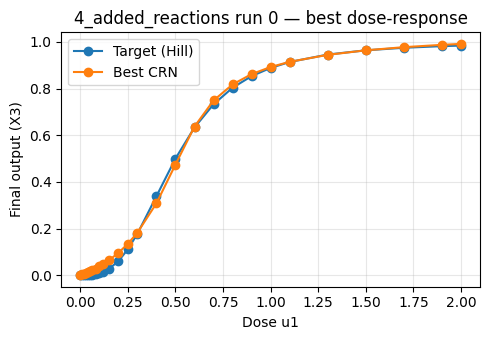


--- Inspecting run 0 ---
Best CRN loss: 0.01744099003555158
Inputs: ['u_1'] 
Species: ['X_1', 'X_2', 'X_3'] 
Output Species: ['X_3'] 
∅ ----> X_1;  [MAK(1.0, u_1)]
X_1 ----> ∅;  [MAK(1.0)]
X_1 ----> X_3 + X_3;  [MAK(0.6410045027732849)]
X_2 ----> ∅;  [MAK(1.0)]
X_3 ----> ∅;  [MAK(1.0)]
X_3 ----> X_2 + X_2;  [MAK(1.6927886009216309)]
X_1 + X_3 ----> X_1 + X_1;  [MAK(1.2165695428848267)]
X_2 + X_2 ----> X_3 + X_3;  [MAK(1.086258053779602)]


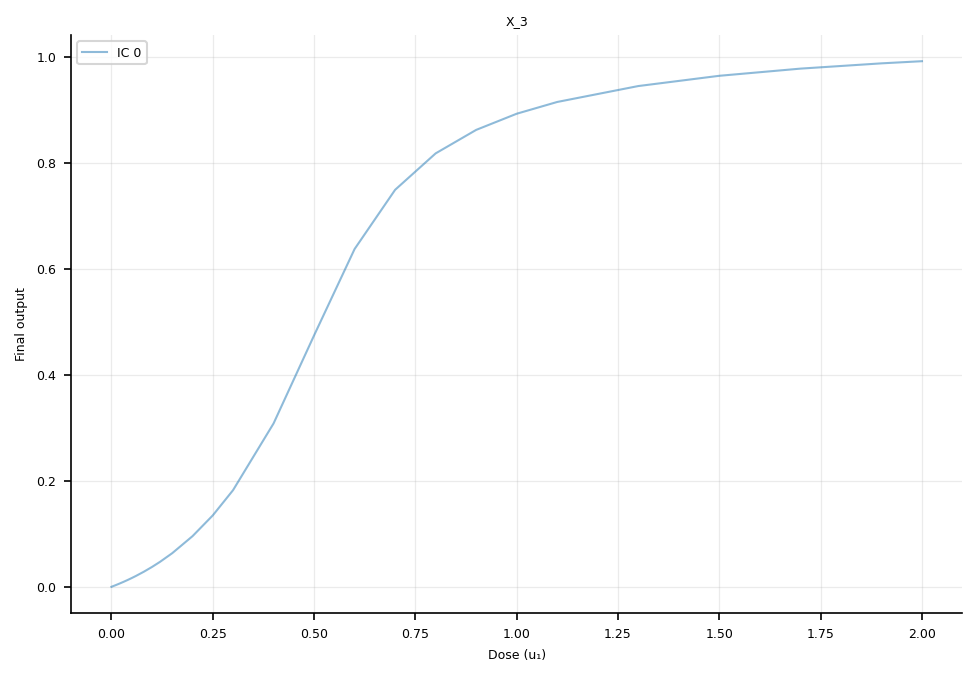

In [14]:
import os
import glob
import json
import torch
import copy
import numpy as np
import matplotlib.pyplot as plt

# Ensure TaskKinds are registered
from RL4CRN.utils import default_tasks  # noqa: F401
from RL4CRN.utils.default_tasks.DoseResponseTaskKind import DoseResponseTaskKind  # noqa: F401

from RL4CRN.utils.input_interface import (
    Configurator,
    make_task,
    make_session_and_trainer,
    print_task_summary,
)

from RL4CRN.utils.crn_builders import build_simple_IOCRN
from RL4CRN.utils.library_builders import build_MAK_library


# -------------------------
# 1) TASK-SPECIFIC SETTINGS (from OLD script: 4_added_reactions)
# -------------------------
target_directory = "/local0/rossin/git/CRN-GenerativeAI/apps_zhou/apps_zhou/4_added_reactions"
preset = "paper"

rtol = 1e-10
atol = 1e-10

species_labels = ["X_1", "X_2", "X_3"]
mak_order = 2

max_added_reactions = 4   # <-- DIFFERENCE
seed = 0

t_f = 100
n_t = 1000

chosen_u_values = [
    0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.08, 0.1, 0.12, 0.15,
    0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.3,
    1.5, 1.7, 1.9, 2.0
]
u_list_custom = [np.array([u], dtype=np.float32) for u in chosen_u_values]

def hill_function_scalar(u: float) -> float:
    kd = 0.5
    max_production = 1.0
    n = 3.0
    return float(max_production * (u**n) / (kd**n + u**n))

target_fn = (lambda u_1: hill_function_scalar(float(u_1)))

ic_spec = ("values", [[0.0, 0.0, 0.0]])
weights_spec = "transient"

norm = 1
LARGE_NUMBER = 1e4
relative = False

TASK_TAG = "dose_response_hill"


# -------------------------
# 2) Generic helpers (HoF loading + injection)
# -------------------------
def _extract_crn(obj):
    if hasattr(obj, "state"):
        crn = obj.state
        rew = None
        if hasattr(obj, "reward"):
            rew = getattr(obj, "reward")
        elif hasattr(obj, "perf"):
            rew = getattr(obj, "perf")
        return crn, rew
    if isinstance(obj, tuple) and len(obj) >= 1:
        return obj[0], (obj[1] if len(obj) > 1 else None)
    if isinstance(obj, dict):
        for k in ["state", "crn", "iocrn"]:
            if k in obj:
                return obj[k], obj.get("reward", obj.get("perf", None))
    return obj, None


def load_old_hof_file(hof_file, map_location="cpu"):
    data = torch.load(hof_file, map_location=map_location, weights_only=False)
    crns = []
    for entry in data:
        crn, rew = _extract_crn(entry)
        if crn is None:
            continue
        if getattr(crn, "last_task_info", None) is None:
            crn.last_task_info = {}
        if rew is not None:
            crn.last_task_info["reward"] = float(rew)
        crns.append(crn)
    return crns


class _EnvStateWrapper:
    def __init__(self, state):
        self.state = state


def _safe_copy_last_task_info(info):
    if info is None:
        return {}
    try:
        return copy.deepcopy(info)
    except Exception:
        out = dict(info)
        for k, v in list(out.items()):
            if isinstance(v, np.ndarray):
                out[k] = v.copy()
        return out


def inject_hof_into_trainer(trainer, crns, max_size=None):
    if max_size is None:
        max_size = int(getattr(trainer.s.cfg.train, "hall_of_fame_size", len(crns)))

    task = trainer.s.task

    def loss_of(crn):
        info = getattr(crn, "last_task_info", {}) or {}
        r = info.get("reward", None)
        return float(r) if r is not None else float("inf")

    crns_sorted = sorted(crns, key=loss_of)[:max_size]

    for c in crns_sorted:
        old_info = getattr(c, "last_task_info", None)
        c.last_task_info = _safe_copy_last_task_info(old_info)

        c.last_task_info["u_list"] = task.u_list
        c.last_task_info["time_horizon"] = task.time_horizon
        c.last_task_info["task_kind"] = task.kind
        c.last_task_info["target_fn"] = target_fn

    trainer.s.mult_env.hall_of_fame = [_EnvStateWrapper(c) for c in crns_sorted]


# -------------------------
# 3) Build trainer for dose-response task (new interface)
# -------------------------
def build_trainer_for_dose_response():
    cfg = Configurator.preset(preset)

    cfg.solver.algorithm = "CVODE"
    cfg.solver.rtol = rtol
    cfg.solver.atol = atol

    cfg.train.max_added_reactions = max_added_reactions
    cfg.train.epochs = 1
    cfg.train.seed = seed

    crn, species_out = build_simple_IOCRN(
        species=species_labels,
        production_input_map={"X_1": "u_1"},
        degradation_input_map={},
        dilution_map={},
        output_species="X_3",
        solver=cfg.solver,
    )

    library_components = build_MAK_library(crn, species_out, order=mak_order)

    task = make_task(
        template_crn=crn,
        library_components=library_components,
        kind="dose_response",
        species_labels=species_out,
        params={
            "t_f": t_f,
            "n_t": n_t,
            "ic": ic_spec,
            "weights": weights_spec,
            "u_spec": ("custom", u_list_custom),
            "target": target_fn,
            "norm": norm,
            "LARGE_NUMBER": LARGE_NUMBER,
            "relative": relative,
        },
    )

    print_task_summary(task)
    trainer = make_session_and_trainer(cfg, task, logger=None)
    return trainer


# -------------------------
# 4) Patch solver fields on old CRNs
# -------------------------
def patch_solver_fields(crns, template_crn):
    solver = getattr(template_crn, "solver", None)
    for c in crns:
        if solver is not None:
            c.solver = solver
        c.rtol = rtol
        c.atol = atol


# -------------------------
# 5) Resimulate whole HoF + replace
# -------------------------
def resimulate_whole_hof_and_replace(trainer):
    hof_crns = [item.state for item in trainer.s.mult_env.hall_of_fame]
    if not hof_crns:
        return []

    patch_solver_fields(hof_crns, trainer.s.task.template_crn)

    task = trainer.s.task
    crns_new = trainer.resimulate(
        hof_crns,
        task=task,
        ic=task.ic_spec,
        weights=task.weights_spec,
        u_list=task.u_list,
    )

    wrapped = []
    for c in crns_new:
        if getattr(c, "last_task_info", None) is None:
            c.last_task_info = {}
        c.last_task_info["u_list"] = task.u_list
        c.last_task_info["time_horizon"] = task.time_horizon
        c.last_task_info["task_kind"] = task.kind
        c.last_task_info["target_fn"] = target_fn
        wrapped.append(_EnvStateWrapper(c))

    trainer.s.mult_env.hall_of_fame = wrapped
    return crns_new


# -------------------------
# 6) Plot dose-response for best CRN (end)
# -------------------------
def plot_best_dose_response(trainer, title="Best dose response"):
    best = trainer.best_crn()
    if best is None:
        print("No best CRN found (HoF empty).")
        return

    task = trainer.s.task
    u_vals = np.array([float(u[0]) for u in task.u_list], dtype=float)

    y_final = None
    info = getattr(best, "last_task_info", {}) or {}
    outs = info.get("outputs", None)
    if outs is not None and len(outs) == len(task.u_list):
        try:
            y_final = np.array([float(o[0, -1]) for o in outs], dtype=float)
        except Exception:
            y_final = None

    if y_final is None:
        y_final = []
        x0_list_full = task.ic.get_ic(best)
        x0 = x0_list_full[0] if isinstance(x0_list_full, list) else x0_list_full
        for u in task.u_list:
            t, x_list, y_list, _ = best.transient_response([u], [x0], task.time_horizon, LARGE_NUMBER=LARGE_NUMBER)
            y_final.append(float(y_list[0][0, -1]))
        y_final = np.asarray(y_final, dtype=float)

    y_target = np.array([hill_function_scalar(u) for u in u_vals], dtype=float)

    plt.figure(figsize=(5.0, 3.5))
    plt.plot(u_vals, y_target, marker="o", linewidth=1.5, label="Target (Hill)")
    plt.plot(u_vals, y_final, marker="o", linewidth=1.5, label="Best CRN")
    plt.xlabel("Dose u1")
    plt.ylabel("Final output (X3)")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


# -------------------------
# 7) Conversion: ONE trainer per HoF file
# -------------------------
def convert_one_app_many_trainers(target_directory: str):
    hof_dir = os.path.join(target_directory, "hof")
    hof_files = sorted(glob.glob(os.path.join(hof_dir, "hall_of_fame_*.pth")))
    if not hof_files:
        raise FileNotFoundError(f"No HoF files found: {os.path.join(hof_dir, 'hall_of_fame_*.pth')}")

    base = os.path.basename(os.path.normpath(target_directory))
    trainers = []

    for i, hof_file in enumerate(hof_files):
        trainer = build_trainer_for_dose_response()

        crns = load_old_hof_file(hof_file, map_location="cpu")
        print(f"[run {i}] Loaded {len(crns)} CRNs from {os.path.basename(hof_file)}")

        inject_hof_into_trainer(trainer, crns, max_size=trainer.s.cfg.train.hall_of_fame_size)

        crns_resim = resimulate_whole_hof_and_replace(trainer)
        print(f"[run {i}] Resimulated HoF CRNs: {len(crns_resim)}")

        ckpt_path = os.path.join(target_directory, f"{base}_run{i}.pkl")
        trainer.save(ckpt_path)

        meta = {
            "target_directory": target_directory,
            "hof_file": hof_file,
            "n_loaded_crns": len(crns),
            "n_resimulated_crns": len(crns_resim),
            "task_tag": TASK_TAG,
            "preset": preset,
            "species_labels": species_labels,
            "mak_order": mak_order,
            "t_f": t_f,
            "n_t": n_t,
            "ic": ic_spec,
            "u_values": chosen_u_values,
            "weights": weights_spec,
            "norm": norm,
            "relative": relative,
            "LARGE_NUMBER": LARGE_NUMBER,
            "solver": {"algorithm": "CVODE", "rtol": rtol, "atol": atol},
            "max_added_reactions": max_added_reactions,
            "seed": seed,
            "checkpoint_path": ckpt_path,
            "run_index": i,
        }
        with open(os.path.join(target_directory, f"{base}_run{i}.meta.json"), "w") as f:
            json.dump(meta, f, indent=2)

        print(f"[run {i}] Saved trainer checkpoint -> {ckpt_path}")

        # Plot at the end of each run
        plot_best_dose_response(trainer, title=f"{base} run {i} — best dose-response")

        trainers.append(trainer)

    return trainers


if __name__ == "__main__":
    trainers = convert_one_app_many_trainers(target_directory)
    for i, tr in enumerate(trainers):
        print(f"\n--- Inspecting run {i} ---")
        tr.inspect_best(plot=True)
        plt.show()

Task: dose_response
time_horizon: (1000,) [0..100.0]
num scenarios: 27
first 3 u: [array([0.], dtype=float32), array([0.01], dtype=float32), array([0.02], dtype=float32)]

[run 0] Loaded 30 CRNs from hall_of_fame_2026-01-12 04:13:34.pth
[run 0] Resimulated HoF CRNs: 30
Saved checkpoint: /local0/rossin/git/CRN-GenerativeAI/apps_zhou/apps_zhou/hill_response_n=3/hill_response_n=3_run0.pkl
[run 0] Saved trainer checkpoint -> /local0/rossin/git/CRN-GenerativeAI/apps_zhou/apps_zhou/hill_response_n=3/hill_response_n=3_run0.pkl


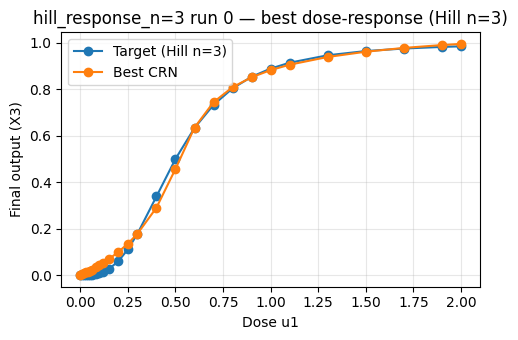

Task: dose_response
time_horizon: (1000,) [0..100.0]
num scenarios: 27
first 3 u: [array([0.], dtype=float32), array([0.01], dtype=float32), array([0.02], dtype=float32)]

[run 1] Loaded 30 CRNs from hall_of_fame_2026-01-12 11:40:51.pth
[run 1] Resimulated HoF CRNs: 30
Saved checkpoint: /local0/rossin/git/CRN-GenerativeAI/apps_zhou/apps_zhou/hill_response_n=3/hill_response_n=3_run1.pkl
[run 1] Saved trainer checkpoint -> /local0/rossin/git/CRN-GenerativeAI/apps_zhou/apps_zhou/hill_response_n=3/hill_response_n=3_run1.pkl


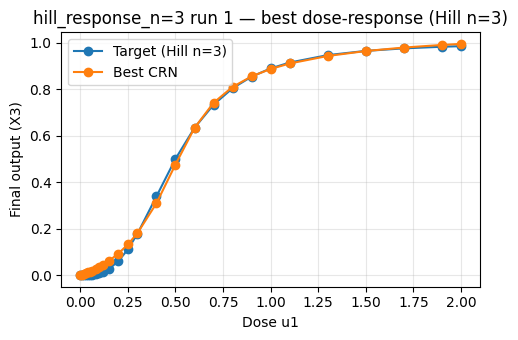


--- Inspecting run 0 ---
Best CRN loss: 0.02025822959988914
Inputs: ['u_1'] 
Species: ['X_1', 'X_2', 'X_3'] 
Output Species: ['X_3'] 
∅ ----> X_1;  [MAK(1.0, u_1)]
X_1 ----> ∅;  [MAK(1.0)]
X_1 ----> X_3;  [MAK(1.3840035200119019)]
X_2 ----> ∅;  [MAK(1.0)]
X_3 ----> ∅;  [MAK(1.0)]
X_3 ----> X_1 + X_2;  [MAK(1.3439066410064697)]
X_3 ----> X_2 + X_3;  [MAK(1.2652587890625)]
X_1 + X_2 ----> X_1 + X_3;  [MAK(1.5330826044082642)]
X_1 + X_3 ----> X_1 + X_1;  [MAK(1.3333039283752441)]


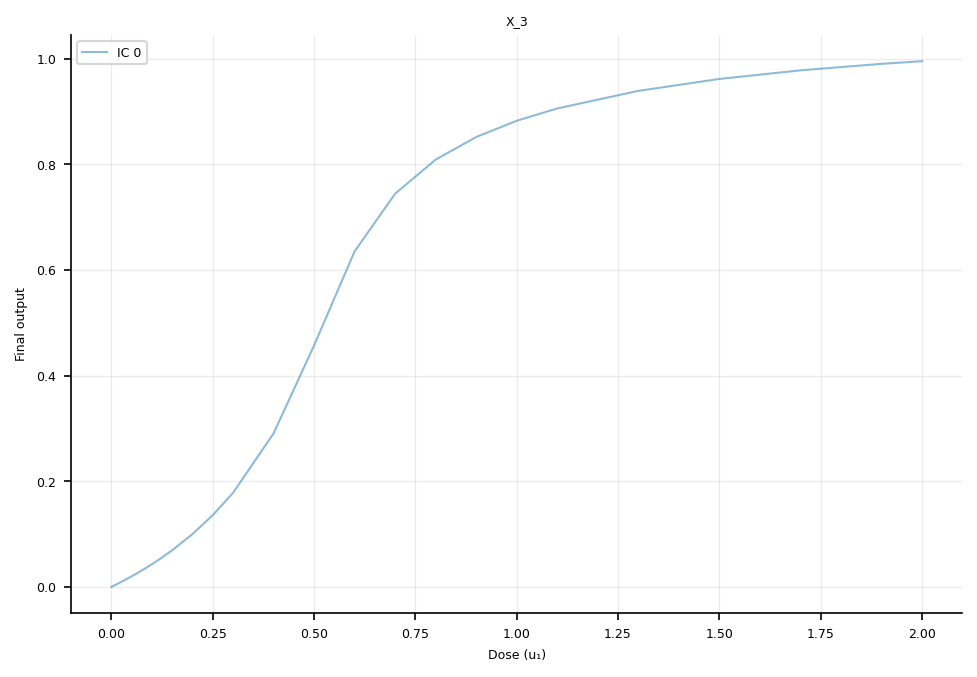


--- Inspecting run 1 ---
Best CRN loss: 0.016224013865418142
Inputs: ['u_1'] 
Species: ['X_1', 'X_2', 'X_3'] 
Output Species: ['X_3'] 
∅ ----> X_1;  [MAK(1.0, u_1)]
X_1 ----> ∅;  [MAK(1.0)]
X_1 ----> X_3 + X_3;  [MAK(0.5535021424293518)]
X_2 ----> ∅;  [MAK(1.0)]
X_3 ----> ∅;  [MAK(1.0)]
X_3 ----> X_2 + X_2;  [MAK(1.650491714477539)]
X_1 + X_3 ----> X_1 + X_1;  [MAK(1.038816213607788)]
X_2 + X_2 ----> X_2 + X_3;  [MAK(0.7086851000785828)]
X_2 + X_2 ----> X_3 + X_3;  [MAK(1.0011863708496094)]


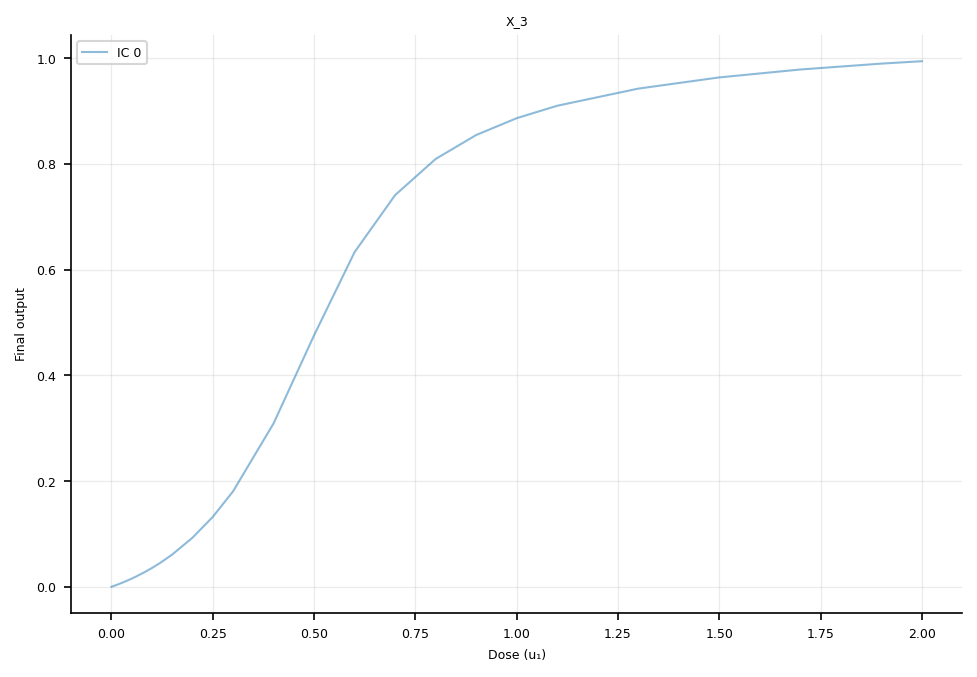

In [15]:
import os
import glob
import json
import torch
import copy
import numpy as np
import matplotlib.pyplot as plt

# Ensure TaskKinds are registered
from RL4CRN.utils import default_tasks  # noqa: F401
from RL4CRN.utils.default_tasks.DoseResponseTaskKind import DoseResponseTaskKind  # noqa: F401

from RL4CRN.utils.input_interface import (
    Configurator,
    make_task,
    make_session_and_trainer,
    print_task_summary,
)

from RL4CRN.utils.crn_builders import build_simple_IOCRN
from RL4CRN.utils.library_builders import build_MAK_library


# =============================================================================
# 1) TASK-SPECIFIC SETTINGS  (hill_response_n=3)
# =============================================================================
target_directory = "/local0/rossin/git/CRN-GenerativeAI/apps_zhou/apps_zhou/hill_response_n=3"
preset = "paper"

# Solver
rtol = 1e-10
atol = 1e-10

# Template/library
species_labels = ["X_1", "X_2", "X_3"]
mak_order = 2

# Training/task knobs (old code)
max_added_reactions = 5
seed = 0

t_f = 100
n_t = 1000

chosen_u_values = [
    0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.08, 0.1, 0.12, 0.15,
    0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.3,
    1.5, 1.7, 1.9, 2.0
]
u_list_custom = [np.array([u], dtype=np.float32) for u in chosen_u_values]

# Hill target (n=3)
def hill_function_scalar(u: float) -> float:
    kd = 0.5
    max_production = 1.0
    n = 3.0
    return float(max_production * (u**n) / (kd**n + u**n))

target_fn = (lambda u_1: hill_function_scalar(float(u_1)))

# IC + weights (old code)
ic_spec = ("values", [[0.0, 0.0, 0.0]])
weights_spec = "transient"

norm = 1
LARGE_NUMBER = 1e4
relative = False

TASK_TAG = "dose_response_hill_n3"


# =============================================================================
# 2) Generic helpers (HoF loading + injection)
# =============================================================================
def _extract_crn(obj):
    if hasattr(obj, "state"):
        crn = obj.state
        rew = None
        if hasattr(obj, "reward"):
            rew = getattr(obj, "reward")
        elif hasattr(obj, "perf"):
            rew = getattr(obj, "perf")
        return crn, rew
    if isinstance(obj, tuple) and len(obj) >= 1:
        return obj[0], (obj[1] if len(obj) > 1 else None)
    if isinstance(obj, dict):
        for k in ["state", "crn", "iocrn"]:
            if k in obj:
                return obj[k], obj.get("reward", obj.get("perf", None))
    return obj, None


def load_old_hof_file(hof_file, map_location="cpu"):
    data = torch.load(hof_file, map_location=map_location, weights_only=False)
    crns = []
    for entry in data:
        crn, rew = _extract_crn(entry)
        if crn is None:
            continue
        if getattr(crn, "last_task_info", None) is None:
            crn.last_task_info = {}
        if rew is not None:
            crn.last_task_info["reward"] = float(rew)
        crns.append(crn)
    return crns


class _EnvStateWrapper:
    def __init__(self, state):
        self.state = state


def _safe_copy_last_task_info(info):
    if info is None:
        return {}
    try:
        return copy.deepcopy(info)
    except Exception:
        out = dict(info)
        for k, v in list(out.items()):
            if isinstance(v, np.ndarray):
                out[k] = v.copy()
        return out


def inject_hof_into_trainer(trainer, crns, max_size=None):
    if max_size is None:
        max_size = int(getattr(trainer.s.cfg.train, "hall_of_fame_size", len(crns)))

    task = trainer.s.task

    def loss_of(crn):
        info = getattr(crn, "last_task_info", {}) or {}
        r = info.get("reward", None)
        return float(r) if r is not None else float("inf")

    crns_sorted = sorted(crns, key=loss_of)[:max_size]

    for c in crns_sorted:
        old_info = getattr(c, "last_task_info", None)
        c.last_task_info = _safe_copy_last_task_info(old_info)

        # required for plots/inspection
        c.last_task_info["u_list"] = task.u_list
        c.last_task_info["time_horizon"] = task.time_horizon
        c.last_task_info["task_kind"] = task.kind
        c.last_task_info["target_fn"] = target_fn

    trainer.s.mult_env.hall_of_fame = [_EnvStateWrapper(c) for c in crns_sorted]


# =============================================================================
# 3) Build trainer for dose-response (new interface)
# =============================================================================
def build_trainer_for_dose_response():
    cfg = Configurator.preset(preset)

    cfg.solver.algorithm = "CVODE"
    cfg.solver.rtol = rtol
    cfg.solver.atol = atol

    cfg.train.max_added_reactions = max_added_reactions
    cfg.train.epochs = 1
    cfg.train.seed = seed

    crn, species_out = build_simple_IOCRN(
        species=species_labels,
        production_input_map={"X_1": "u_1"},
        degradation_input_map={},
        dilution_map={},
        output_species="X_3",
        solver=cfg.solver,
    )

    library_components = build_MAK_library(crn, species_out, order=mak_order)

    task = make_task(
        template_crn=crn,
        library_components=library_components,
        kind="dose_response",
        species_labels=species_out,
        params={
            "t_f": t_f,
            "n_t": n_t,
            "ic": ic_spec,
            "weights": weights_spec,
            "u_spec": ("custom", u_list_custom),
            "target": target_fn,
            "norm": norm,
            "LARGE_NUMBER": LARGE_NUMBER,
            "relative": relative,
        },
    )

    print_task_summary(task)
    trainer = make_session_and_trainer(cfg, task, logger=None)
    return trainer


# =============================================================================
# 4) Patch solver fields on old CRNs (helps old pickles)
# =============================================================================
def patch_solver_fields(crns, template_crn):
    solver = getattr(template_crn, "solver", None)
    for c in crns:
        if solver is not None:
            c.solver = solver
        c.rtol = rtol
        c.atol = atol


# =============================================================================
# 5) Resimulate whole HoF + replace (so plots are populated)
# =============================================================================
def resimulate_whole_hof_and_replace(trainer):
    hof_crns = [item.state for item in trainer.s.mult_env.hall_of_fame]
    if not hof_crns:
        return []

    patch_solver_fields(hof_crns, trainer.s.task.template_crn)

    task = trainer.s.task
    crns_new = trainer.resimulate(
        hof_crns,
        task=task,
        ic=task.ic_spec,
        weights=task.weights_spec,
        u_list=task.u_list,
    )

    wrapped = []
    for c in crns_new:
        if getattr(c, "last_task_info", None) is None:
            c.last_task_info = {}
        c.last_task_info["u_list"] = task.u_list
        c.last_task_info["time_horizon"] = task.time_horizon
        c.last_task_info["task_kind"] = task.kind
        c.last_task_info["target_fn"] = target_fn
        wrapped.append(_EnvStateWrapper(c))

    trainer.s.mult_env.hall_of_fame = wrapped
    return crns_new


# =============================================================================
# 6) Plot dose-response for best CRN (end)
# =============================================================================
def plot_best_dose_response(trainer, title="Best dose response"):
    best = trainer.best_crn()
    if best is None:
        print("No best CRN found (HoF empty).")
        return

    task = trainer.s.task
    u_vals = np.array([float(u[0]) for u in task.u_list], dtype=float)

    # prefer cached outputs from last_task_info
    y_final = None
    info = getattr(best, "last_task_info", {}) or {}
    outs = info.get("outputs", None)
    if outs is not None and len(outs) == len(task.u_list):
        try:
            y_final = np.array([float(o[0, -1]) for o in outs], dtype=float)
        except Exception:
            y_final = None

    # fallback: explicitly simulate each scenario
    if y_final is None:
        y_final = []
        x0_list_full = task.ic.get_ic(best)
        x0 = x0_list_full[0] if isinstance(x0_list_full, list) else x0_list_full
        for u in task.u_list:
            t, x_list, y_list, _ = best.transient_response([u], [x0], task.time_horizon, LARGE_NUMBER=LARGE_NUMBER)
            y_final.append(float(y_list[0][0, -1]))
        y_final = np.asarray(y_final, dtype=float)

    y_target = np.array([hill_function_scalar(u) for u in u_vals], dtype=float)

    plt.figure(figsize=(5.0, 3.5))
    plt.plot(u_vals, y_target, marker="o", linewidth=1.5, label="Target (Hill n=3)")
    plt.plot(u_vals, y_final, marker="o", linewidth=1.5, label="Best CRN")
    plt.xlabel("Dose u1")
    plt.ylabel("Final output (X3)")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


# =============================================================================
# 7) Conversion: ONE trainer per HoF file
# =============================================================================
def convert_one_app_many_trainers(target_directory: str):
    hof_dir = os.path.join(target_directory, "hof")
    hof_files = sorted(glob.glob(os.path.join(hof_dir, "hall_of_fame_*.pth")))
    if not hof_files:
        raise FileNotFoundError(f"No HoF files found: {os.path.join(hof_dir, 'hall_of_fame_*.pth')}")

    base = os.path.basename(os.path.normpath(target_directory))
    trainers = []

    for i, hof_file in enumerate(hof_files):
        trainer = build_trainer_for_dose_response()

        crns = load_old_hof_file(hof_file, map_location="cpu")
        print(f"[run {i}] Loaded {len(crns)} CRNs from {os.path.basename(hof_file)}")

        inject_hof_into_trainer(trainer, crns, max_size=trainer.s.cfg.train.hall_of_fame_size)

        crns_resim = resimulate_whole_hof_and_replace(trainer)
        print(f"[run {i}] Resimulated HoF CRNs: {len(crns_resim)}")

        ckpt_path = os.path.join(target_directory, f"{base}_run{i}.pkl")
        trainer.save(ckpt_path)

        meta = {
            "target_directory": target_directory,
            "hof_file": hof_file,
            "n_loaded_crns": len(crns),
            "n_resimulated_crns": len(crns_resim),
            "task_tag": TASK_TAG,
            "preset": preset,
            "species_labels": species_labels,
            "mak_order": mak_order,
            "t_f": t_f,
            "n_t": n_t,
            "ic": ic_spec,
            "u_values": chosen_u_values,
            "weights": weights_spec,
            "norm": norm,
            "relative": relative,
            "LARGE_NUMBER": LARGE_NUMBER,
            "solver": {"algorithm": "CVODE", "rtol": rtol, "atol": atol},
            "max_added_reactions": max_added_reactions,
            "seed": seed,
            "checkpoint_path": ckpt_path,
            "run_index": i,
        }
        with open(os.path.join(target_directory, f"{base}_run{i}.meta.json"), "w") as f:
            json.dump(meta, f, indent=2)

        print(f"[run {i}] Saved trainer checkpoint -> {ckpt_path}")

        # Plot at the end of each run
        plot_best_dose_response(trainer, title=f"{base} run {i} — best dose-response (Hill n=3)")

        trainers.append(trainer)

    return trainers


if __name__ == "__main__":
    trainers = convert_one_app_many_trainers(target_directory)

    for i, tr in enumerate(trainers):
            print(f"\n--- Inspecting run {i} ---")
            tr.inspect_best(plot=True)
            plt.show()

6

Task: dose_response
time_horizon: (1000,) [0..100.0]
num scenarios: 27
first 3 u: [array([0.], dtype=float32), array([0.01], dtype=float32), array([0.02], dtype=float32)]

[run 0] Loaded 30 CRNs from hall_of_fame_2026-02-25 23:13:09.pth
[run 0] Resimulated HoF CRNs: 30
Saved checkpoint: /local0/rossin/git/CRN-GenerativeAI/apps_zhou/apps_zhou/6_added_reactions/6_added_reactions_run0.pkl
[run 0] Saved trainer checkpoint -> /local0/rossin/git/CRN-GenerativeAI/apps_zhou/apps_zhou/6_added_reactions/6_added_reactions_run0.pkl


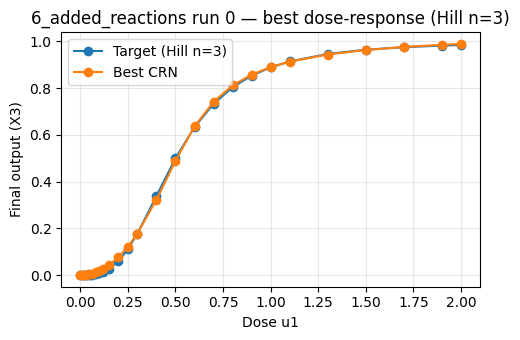


--- Inspecting run 0 ---
Best CRN loss: 0.010142047674380011
Inputs: ['u_1'] 
Species: ['X_1', 'X_2', 'X_3'] 
Output Species: ['X_3'] 
∅ ----> X_1;  [MAK(1.0, u_1)]
X_1 ----> ∅;  [MAK(1.0)]
X_2 ----> ∅;  [MAK(1.0)]
X_2 ----> X_1 + X_3;  [MAK(1.7993240356445312)]
X_2 ----> X_2 + X_3;  [MAK(1.8195650577545166)]
X_3 ----> ∅;  [MAK(1.0)]
X_1 + X_1 ----> X_1 + X_2;  [MAK(1.504372239112854)]
X_1 + X_3 ----> X_1 + X_2;  [MAK(1.6953766345977783)]
X_2 + X_2 ----> X_1 + X_2;  [MAK(1.7230286598205566)]
X_2 + X_3 ----> X_2;  [MAK(1.6569714546203613)]


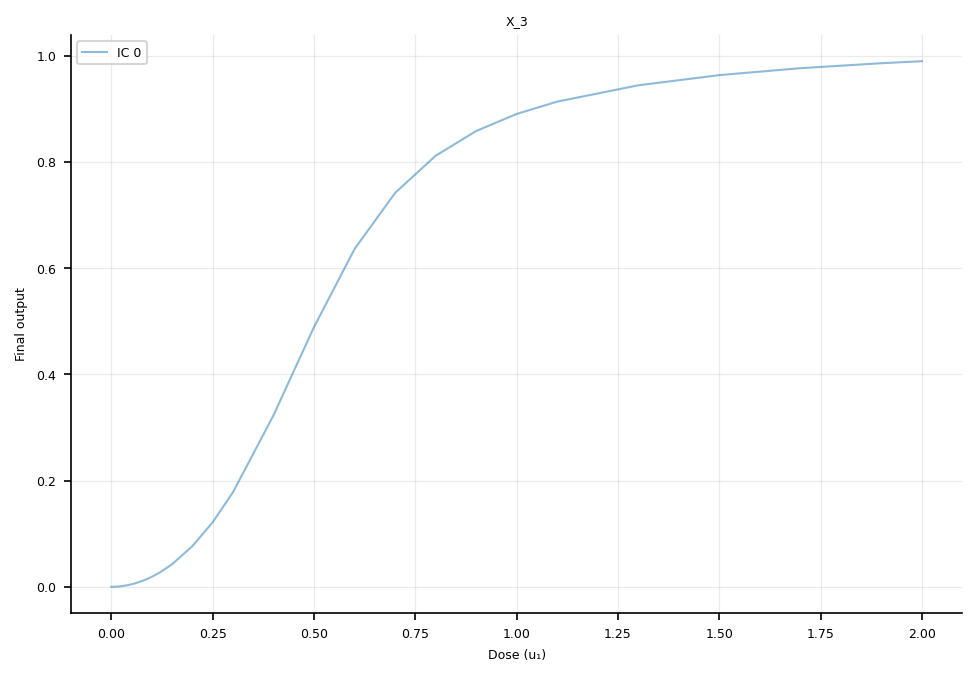

In [17]:
import os
import glob
import json
import torch
import copy
import numpy as np
import matplotlib.pyplot as plt

# Ensure TaskKinds are registered
from RL4CRN.utils import default_tasks  # noqa: F401
from RL4CRN.utils.default_tasks.DoseResponseTaskKind import DoseResponseTaskKind  # noqa: F401

from RL4CRN.utils.input_interface import (
    Configurator,
    make_task,
    make_session_and_trainer,
    print_task_summary,
)

from RL4CRN.utils.crn_builders import build_simple_IOCRN
from RL4CRN.utils.library_builders import build_MAK_library


# =============================================================================
# 1) TASK-SPECIFIC SETTINGS  (6_added_reactions)
# =============================================================================
target_directory = "/local0/rossin/git/CRN-GenerativeAI/apps_zhou/apps_zhou/6_added_reactions"
preset = "paper"

# Solver
rtol = 1e-10
atol = 1e-10

# Template/library
species_labels = ["X_1", "X_2", "X_3"]
mak_order = 2

# Training/task knobs (old code)
max_added_reactions = 6
seed = 0

t_f = 100
n_t = 1000

chosen_u_values = [
    0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.08, 0.1, 0.12, 0.15,
    0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.3,
    1.5, 1.7, 1.9, 2.0
]
u_list_custom = [np.array([u], dtype=np.float32) for u in chosen_u_values]

# Hill target (n=3) (same as old code)
def hill_function_scalar(u: float) -> float:
    kd = 0.5
    max_production = 1.0
    n = 3.0
    return float(max_production * (u**n) / (kd**n + u**n))

target_fn = (lambda u_1: hill_function_scalar(float(u_1)))

# IC + weights (old code)
ic_spec = ("values", [[0.0, 0.0, 0.0]])
weights_spec = "transient"

norm = 1
LARGE_NUMBER = 1e4
relative = False

TASK_TAG = "dose_response_hill_n3"


# =============================================================================
# 2) Generic helpers (HoF loading + injection)
# =============================================================================
def _extract_crn(obj):
    if hasattr(obj, "state"):
        crn = obj.state
        rew = None
        if hasattr(obj, "reward"):
            rew = getattr(obj, "reward")
        elif hasattr(obj, "perf"):
            rew = getattr(obj, "perf")
        return crn, rew
    if isinstance(obj, tuple) and len(obj) >= 1:
        return obj[0], (obj[1] if len(obj) > 1 else None)
    if isinstance(obj, dict):
        for k in ["state", "crn", "iocrn"]:
            if k in obj:
                return obj[k], obj.get("reward", obj.get("perf", None))
    return obj, None


def load_old_hof_file(hof_file, map_location="cpu"):
    data = torch.load(hof_file, map_location=map_location, weights_only=False)
    crns = []
    for entry in data:
        crn, rew = _extract_crn(entry)
        if crn is None:
            continue
        if getattr(crn, "last_task_info", None) is None:
            crn.last_task_info = {}
        if rew is not None:
            crn.last_task_info["reward"] = float(rew)
        crns.append(crn)
    return crns


class _EnvStateWrapper:
    def __init__(self, state):
        self.state = state


def _safe_copy_last_task_info(info):
    if info is None:
        return {}
    try:
        return copy.deepcopy(info)
    except Exception:
        out = dict(info)
        for k, v in list(out.items()):
            if isinstance(v, np.ndarray):
                out[k] = v.copy()
        return out


def inject_hof_into_trainer(trainer, crns, max_size=None):
    if max_size is None:
        max_size = int(getattr(trainer.s.cfg.train, "hall_of_fame_size", len(crns)))

    task = trainer.s.task

    def loss_of(crn):
        info = getattr(crn, "last_task_info", {}) or {}
        r = info.get("reward", None)
        return float(r) if r is not None else float("inf")

    crns_sorted = sorted(crns, key=loss_of)[:max_size]

    for c in crns_sorted:
        old_info = getattr(c, "last_task_info", None)
        c.last_task_info = _safe_copy_last_task_info(old_info)

        # required for plots/inspection
        c.last_task_info["u_list"] = task.u_list
        c.last_task_info["time_horizon"] = task.time_horizon
        c.last_task_info["task_kind"] = task.kind
        c.last_task_info["target_fn"] = target_fn

    trainer.s.mult_env.hall_of_fame = [_EnvStateWrapper(c) for c in crns_sorted]


# =============================================================================
# 3) Build trainer for dose-response (new interface)
# =============================================================================
def build_trainer_for_dose_response():
    cfg = Configurator.preset(preset)

    cfg.solver.algorithm = "CVODE"
    cfg.solver.rtol = rtol
    cfg.solver.atol = atol

    cfg.train.max_added_reactions = max_added_reactions
    cfg.train.epochs = 1
    cfg.train.seed = seed

    crn, species_out = build_simple_IOCRN(
        species=species_labels,
        production_input_map={"X_1": "u_1"},
        degradation_input_map={},
        dilution_map={},
        output_species="X_3",
        solver=cfg.solver,
    )

    library_components = build_MAK_library(crn, species_out, order=mak_order)

    task = make_task(
        template_crn=crn,
        library_components=library_components,
        kind="dose_response",
        species_labels=species_out,
        params={
            "t_f": t_f,
            "n_t": n_t,
            "ic": ic_spec,
            "weights": weights_spec,
            "u_spec": ("custom", u_list_custom),
            "target": target_fn,
            "norm": norm,
            "LARGE_NUMBER": LARGE_NUMBER,
            "relative": relative,
        },
    )

    print_task_summary(task)
    trainer = make_session_and_trainer(cfg, task, logger=None)
    return trainer


# =============================================================================
# 4) Patch solver fields on old CRNs (helps old pickles)
# =============================================================================
def patch_solver_fields(crns, template_crn):
    solver = getattr(template_crn, "solver", None)
    for c in crns:
        if solver is not None:
            c.solver = solver
        c.rtol = rtol
        c.atol = atol


# =============================================================================
# 5) Resimulate whole HoF + replace (so plots are populated)
# =============================================================================
def resimulate_whole_hof_and_replace(trainer):
    hof_crns = [item.state for item in trainer.s.mult_env.hall_of_fame]
    if not hof_crns:
        return []

    patch_solver_fields(hof_crns, trainer.s.task.template_crn)

    task = trainer.s.task
    crns_new = trainer.resimulate(
        hof_crns,
        task=task,
        ic=task.ic_spec,
        weights=task.weights_spec,
        u_list=task.u_list,
    )

    wrapped = []
    for c in crns_new:
        if getattr(c, "last_task_info", None) is None:
            c.last_task_info = {}
        c.last_task_info["u_list"] = task.u_list
        c.last_task_info["time_horizon"] = task.time_horizon
        c.last_task_info["task_kind"] = task.kind
        c.last_task_info["target_fn"] = target_fn
        wrapped.append(_EnvStateWrapper(c))

    trainer.s.mult_env.hall_of_fame = wrapped
    return crns_new


# =============================================================================
# 6) Plot dose-response for best CRN (end)
# =============================================================================
def plot_best_dose_response(trainer, title="Best dose response"):
    best = trainer.best_crn()
    if best is None:
        print("No best CRN found (HoF empty).")
        return

    task = trainer.s.task
    u_vals = np.array([float(u[0]) for u in task.u_list], dtype=float)

    # prefer cached outputs from last_task_info
    y_final = None
    info = getattr(best, "last_task_info", {}) or {}
    outs = info.get("outputs", None)
    if outs is not None and len(outs) == len(task.u_list):
        try:
            y_final = np.array([float(o[0, -1]) for o in outs], dtype=float)
        except Exception:
            y_final = None

    # fallback: explicitly simulate each scenario
    if y_final is None:
        y_final = []
        x0_list_full = task.ic.get_ic(best)
        x0 = x0_list_full[0] if isinstance(x0_list_full, list) else x0_list_full
        for u in task.u_list:
            t, x_list, y_list, _ = best.transient_response([u], [x0], task.time_horizon, LARGE_NUMBER=LARGE_NUMBER)
            y_final.append(float(y_list[0][0, -1]))
        y_final = np.asarray(y_final, dtype=float)

    y_target = np.array([hill_function_scalar(u) for u in u_vals], dtype=float)

    plt.figure(figsize=(5.0, 3.5))
    plt.plot(u_vals, y_target, marker="o", linewidth=1.5, label="Target (Hill n=3)")
    plt.plot(u_vals, y_final, marker="o", linewidth=1.5, label="Best CRN")
    plt.xlabel("Dose u1")
    plt.ylabel("Final output (X3)")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


# =============================================================================
# 7) Conversion: ONE trainer per HoF file
# =============================================================================
def convert_one_app_many_trainers(target_directory: str):
    hof_dir = os.path.join(target_directory, "hof")
    hof_files = sorted(glob.glob(os.path.join(hof_dir, "hall_of_fame_*.pth")))
    if not hof_files:
        raise FileNotFoundError(f"No HoF files found: {os.path.join(hof_dir, 'hall_of_fame_*.pth')}")

    base = os.path.basename(os.path.normpath(target_directory))
    trainers = []

    for i, hof_file in enumerate(hof_files):
        trainer = build_trainer_for_dose_response()

        crns = load_old_hof_file(hof_file, map_location="cpu")
        print(f"[run {i}] Loaded {len(crns)} CRNs from {os.path.basename(hof_file)}")

        inject_hof_into_trainer(trainer, crns, max_size=trainer.s.cfg.train.hall_of_fame_size)

        crns_resim = resimulate_whole_hof_and_replace(trainer)
        print(f"[run {i}] Resimulated HoF CRNs: {len(crns_resim)}")

        ckpt_path = os.path.join(target_directory, f"{base}_run{i}.pkl")
        trainer.save(ckpt_path)

        meta = {
            "target_directory": target_directory,
            "hof_file": hof_file,
            "n_loaded_crns": len(crns),
            "n_resimulated_crns": len(crns_resim),
            "task_tag": TASK_TAG,
            "preset": preset,
            "species_labels": species_labels,
            "mak_order": mak_order,
            "t_f": t_f,
            "n_t": n_t,
            "ic": ic_spec,
            "u_values": chosen_u_values,
            "weights": weights_spec,
            "norm": norm,
            "relative": relative,
            "LARGE_NUMBER": LARGE_NUMBER,
            "solver": {"algorithm": "CVODE", "rtol": rtol, "atol": atol},
            "max_added_reactions": max_added_reactions,
            "seed": seed,
            "checkpoint_path": ckpt_path,
            "run_index": i,
        }
        with open(os.path.join(target_directory, f"{base}_run{i}.meta.json"), "w") as f:
            json.dump(meta, f, indent=2)

        print(f"[run {i}] Saved trainer checkpoint -> {ckpt_path}")

        # Plot at the end of each run
        plot_best_dose_response(trainer, title=f"{base} run {i} — best dose-response (Hill n=3)")

        trainers.append(trainer)

    return trainers


if __name__ == "__main__":
    trainers = convert_one_app_many_trainers(target_directory)

    for i, tr in enumerate(trainers):
            print(f"\n--- Inspecting run {i} ---")
            tr.inspect_best(plot=True)
            plt.show()

Task: dose_response
time_horizon: (1000,) [0..100.0]
num scenarios: 30
first 3 u: [array([0.1], dtype=float32), array([0.12004549], dtype=float32), array([0.1441092], dtype=float32)]

[run 0] Loaded 30 CRNs from hall_of_fame_2026-01-13 23:45:37.pth


/local0/rossin/git/CRN-GenerativeAI/.venv/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[run 0] Resimulated HoF CRNs: 30
Saved checkpoint: /local0/rossin/git/CRN-GenerativeAI/apps_zhou/apps_zhou/Ultra-sensitivity/Ultra-sensitivity_run0.pkl
[run 0] Saved trainer checkpoint -> /local0/rossin/git/CRN-GenerativeAI/apps_zhou/apps_zhou/Ultra-sensitivity/Ultra-sensitivity_run0.pkl
Best CRN loss: 0.08749230893636291
Inputs: ['u_1'] 
Species: ['X_1', 'X_2', 'X_3'] 
Output Species: ['X_3'] 
∅ ----> X_1;  [MAK(1.0, u_1)]
X_1 ----> ∅;  [MAK(1.0)]
X_1 ----> X_3;  [MAK(0.57248854637146)]
X_2 ----> ∅;  [MAK(1.0)]
X_3 ----> ∅;  [MAK(1.0)]
X_1 + X_1 ----> X_1 + X_2;  [MAK(0.5278787016868591)]
X_1 + X_2 ----> X_2 + X_2;  [MAK(0.48000237345695496)]
X_1 + X_3 ----> X_3 + X_3;  [MAK(0.5698274374008179)]
X_2 + X_3 ----> X_1 + X_1;  [MAK(0.4602356255054474)]


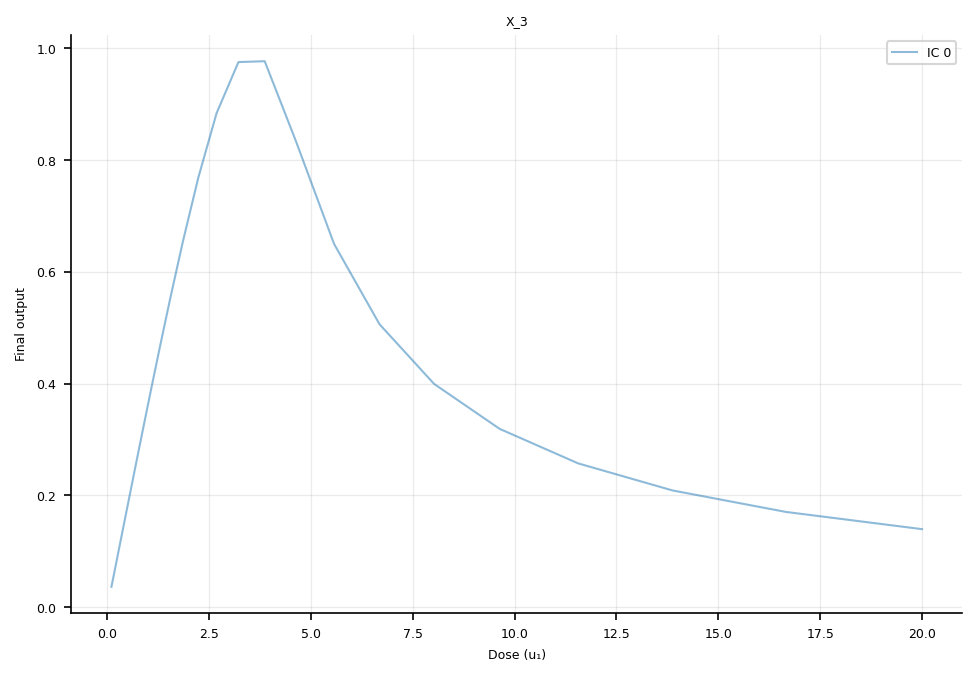

Task: dose_response
time_horizon: (1000,) [0..100.0]
num scenarios: 30
first 3 u: [array([0.1], dtype=float32), array([0.12004549], dtype=float32), array([0.1441092], dtype=float32)]

[run 1] Loaded 30 CRNs from hall_of_fame_2026-01-13 23:48:35.pth
[run 1] Resimulated HoF CRNs: 30
Saved checkpoint: /local0/rossin/git/CRN-GenerativeAI/apps_zhou/apps_zhou/Ultra-sensitivity/Ultra-sensitivity_run1.pkl
[run 1] Saved trainer checkpoint -> /local0/rossin/git/CRN-GenerativeAI/apps_zhou/apps_zhou/Ultra-sensitivity/Ultra-sensitivity_run1.pkl
Best CRN loss: 0.08030963464034849
Inputs: ['u_1'] 
Species: ['X_1', 'X_2', 'X_3'] 
Output Species: ['X_3'] 
∅ ----> X_1;  [MAK(1.0, u_1)]
X_1 ----> ∅;  [MAK(1.0)]
X_1 ----> X_2 + X_3;  [MAK(0.0730113536119461)]
X_2 ----> ∅;  [MAK(1.0)]
X_3 ----> ∅;  [MAK(1.0)]
X_1 + X_1 ----> X_1 + X_3;  [MAK(0.45300567150115967)]
X_1 + X_2 ----> X_2 + X_2;  [MAK(0.5545815229415894)]
X_2 + X_3 ----> X_1 + X_1;  [MAK(0.17384591698646545)]
X_2 + X_3 ----> X_1 + X_2;  [MAK(0.4

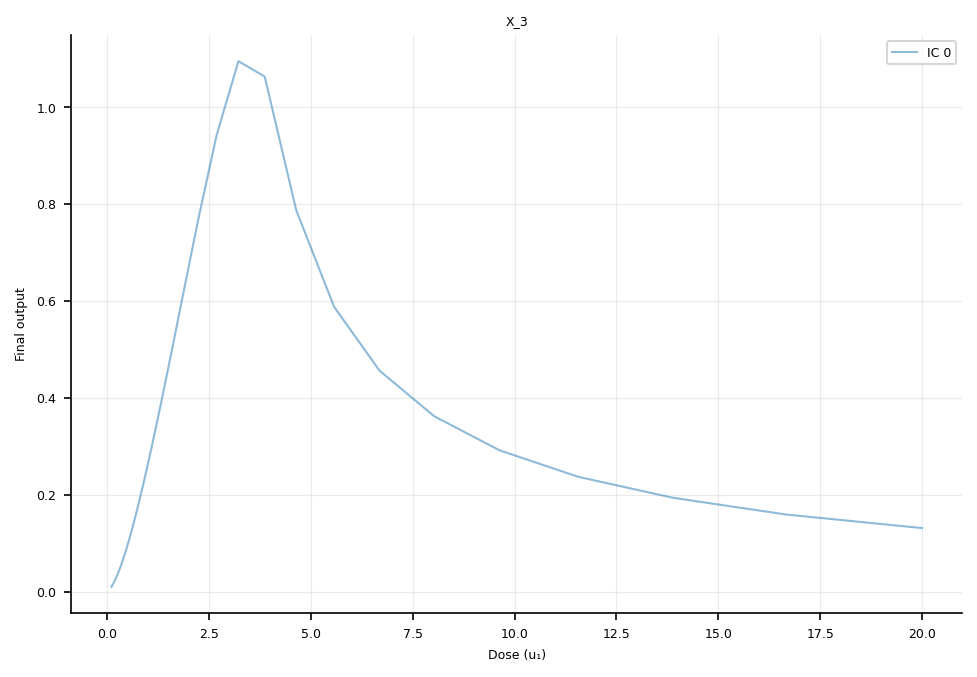

Task: dose_response
time_horizon: (1000,) [0..100.0]
num scenarios: 30
first 3 u: [array([0.1], dtype=float32), array([0.12004549], dtype=float32), array([0.1441092], dtype=float32)]

[run 2] Loaded 30 CRNs from hall_of_fame_2026-01-13 23:49:42.pth
[run 2] Resimulated HoF CRNs: 30
Saved checkpoint: /local0/rossin/git/CRN-GenerativeAI/apps_zhou/apps_zhou/Ultra-sensitivity/Ultra-sensitivity_run2.pkl
[run 2] Saved trainer checkpoint -> /local0/rossin/git/CRN-GenerativeAI/apps_zhou/apps_zhou/Ultra-sensitivity/Ultra-sensitivity_run2.pkl
Best CRN loss: 0.05380237643448407
Inputs: ['u_1'] 
Species: ['X_1', 'X_2', 'X_3'] 
Output Species: ['X_3'] 
∅ ----> X_1;  [MAK(1.0, u_1)]
X_1 ----> ∅;  [MAK(1.0)]
X_2 ----> ∅;  [MAK(1.0)]
X_2 ----> X_1 + X_2;  [MAK(0.7361075282096863)]
X_3 ----> ∅;  [MAK(1.0)]
X_3 ----> X_1 + X_2;  [MAK(0.5741713643074036)]
X_1 + X_1 ----> X_3 + X_3;  [MAK(0.444236695766449)]
X_1 + X_2 ----> X_2 + X_2;  [MAK(0.38716796040534973)]
X_2 + X_3 ----> X_1 + X_2;  [MAK(0.697231352

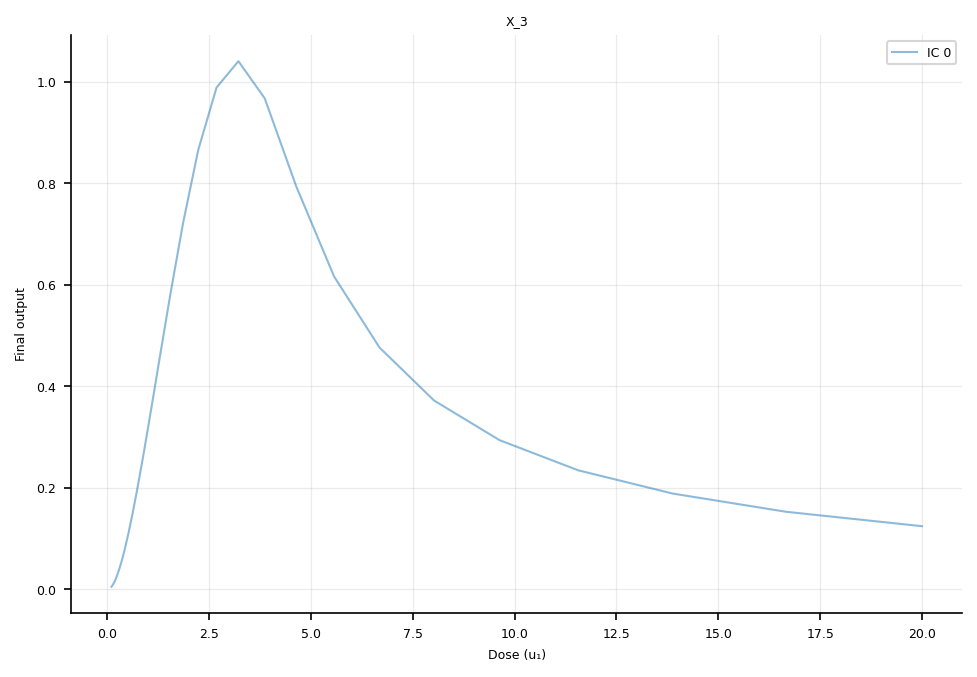

In [18]:
"""
RL4CRN converter script (new interface)
Task: Dose-response (Ultra-sensitivity / non-monotonic target)
Source folder: /local0/rossin/git/CRN-GenerativeAI/apps_zhou/apps_zhou/Ultra-sensitivity

What it does:
- For each hof/hall_of_fame_*.pth file in target_directory:
  1) Builds a trainer wired with the NEW input_interface (dose_response task)
  2) Loads the old HoF CRNs from that .pth
  3) Injects them into trainer.s.mult_env.hall_of_fame
  4) Resimulates the whole injected HoF under the NEW task (so plots are real, not empty)
  5) Saves one checkpoint per HoF file as: <folder_basename>_run{i}.pkl
  6) Writes a sidecar meta json
  7) (Optional) plots the best CRN at the end of each run

Notes:
- This follows the same “HoF injection + resimulate + save” pattern we used for other tasks.
- Uses CVODE tolerances rtol=atol=1e-10 (as requested for dose-response tasks).
"""

import os
import glob
import json
import copy
import torch
import numpy as np

# IMPORTANT: importing default_tasks ensures TaskKinds are registered (dose_response included).
from RL4CRN.utils import default_tasks  # noqa: F401

from RL4CRN.utils.input_interface import (
    Configurator,
    make_task,
    make_session_and_trainer,
    print_task_summary,
)

from RL4CRN.utils.crn_builders import build_simple_IOCRN
from RL4CRN.utils.library_builders import build_MAK_library


# -------------------------
# 1) TASK-SPECIFIC SETTINGS (EDIT THESE PER APP)
# -------------------------
target_directory = "/local0/rossin/git/CRN-GenerativeAI/apps_zhou/apps_zhou/Ultra-sensitivity"

preset = "paper"

# Template / library
species_labels = ["X_1", "X_2", "X_3"]
mak_order = 2

# Train knobs (these are just to wire the trainer; we are converting HoFs)
max_added_reactions = 5
seed = 0

# Simulation horizon (matches old)
t_f = 100
n_t = 1000

# IC (old: all zeros)
ic_spec = ("values", [[0.0, 0.0, 0.0]])

# weights (old used "transient" profile)
weights_spec = "transient"

# Dose-response input grid (old uses geomspace(0.1, 20.0, 30))
chosen_u_values = np.geomspace(0.1, 20.0, 30).astype(np.float32)
u_list_custom = [np.array([float(u)], dtype=np.float32) for u in chosen_u_values]

# Non-monotonic target (old)
def non_monotonic_target(u_1: float) -> float:
    optimal_input = 3.0
    width_param = 0.7
    max_response = 1.0
    return float(max_response * np.exp(-((np.log(u_1) - np.log(optimal_input)) ** 2) / (2 * width_param**2)))


# metadata tag
TASK_TAG = "dose_response_ultra_sensitivity"


# -------------------------
# 2) Generic helpers (HoF loading + injection)
# -------------------------
def _extract_crn(obj):
    """Accept common old HoF formats and return (crn, reward_or_None)."""
    if hasattr(obj, "state"):
        crn = obj.state
        rew = None
        if hasattr(obj, "reward"):
            rew = getattr(obj, "reward")
        elif hasattr(obj, "perf"):
            rew = getattr(obj, "perf")
        return crn, rew

    if isinstance(obj, tuple) and len(obj) >= 1:
        crn = obj[0]
        rew = obj[1] if len(obj) > 1 else None
        return crn, rew

    if isinstance(obj, dict):
        for k in ["state", "crn", "iocrn"]:
            if k in obj:
                crn = obj[k]
                rew = obj.get("reward", obj.get("perf", None))
                return crn, rew

    return obj, None


def load_old_hof_file(hof_file: str, map_location: str = "cpu"):
    data = torch.load(hof_file, map_location=map_location, weights_only=False)
    crns = []
    for entry in data:
        crn, rew = _extract_crn(entry)
        if crn is None:
            continue
        if getattr(crn, "last_task_info", None) is None:
            crn.last_task_info = {}
        if rew is not None:
            crn.last_task_info["reward"] = float(rew)
        crns.append(crn)
    return crns


class _EnvStateWrapper:
    """Minimal wrapper so trainer expects items with `.state` (as in Trainer.load())."""
    def __init__(self, state):
        self.state = state


def _safe_copy_last_task_info(info):
    """Best-effort deepcopy that won't crash on non-picklable objects."""
    if info is None:
        return {}
    try:
        return copy.deepcopy(info)
    except Exception:
        out = dict(info)
        for k, v in list(out.items()):
            if isinstance(v, np.ndarray):
                out[k] = v.copy()
        return out


def patch_solver_fields(crns, template_crn):
    """
    Old stored IOCRNs sometimes miss runtime solver attributes (e.g., `solver`).
    Copy a minimal set from the template to avoid AttributeError during resimulation.
    """
    for c in crns:
        for attr in ["solver", "rtol", "atol"]:
            if hasattr(template_crn, attr) and not hasattr(c, attr):
                try:
                    setattr(c, attr, getattr(template_crn, attr))
                except Exception:
                    pass


def inject_hof(trainer, crns, max_size=None):
    """
    Inject CRNs into trainer.s.mult_env.hall_of_fame as env-like items with `.state`,
    and overlay required plotting/task context in last_task_info.
    """
    if max_size is None:
        max_size = int(getattr(trainer.s.cfg.train, "hall_of_fame_size", len(crns)))

    task = trainer.s.task
    u_list_task = task.u_list
    time_horizon_task = task.time_horizon

    def loss_of(crn):
        info = getattr(crn, "last_task_info", {}) or {}
        r = info.get("reward", None)
        return float(r) if r is not None else float("inf")

    crns_sorted = sorted(crns, key=loss_of)[:max_size]

    for c in crns_sorted:
        old_info = getattr(c, "last_task_info", None)
        c.last_task_info = _safe_copy_last_task_info(old_info)

        # required for plotting and inspection
        c.last_task_info["u_list"] = u_list_task
        c.last_task_info["time_horizon"] = time_horizon_task
        c.last_task_info["task_kind"] = task.kind

        # keep reward if present
        if "reward" not in c.last_task_info and old_info is not None:
            try:
                if "reward" in old_info:
                    c.last_task_info["reward"] = float(old_info["reward"])
            except Exception:
                pass

    trainer.s.mult_env.hall_of_fame = [_EnvStateWrapper(c) for c in crns_sorted]


def resimulate_whole_hof_and_replace(trainer):
    """
    Resimulate ALL HoF CRNs under trainer.s.task and replace hall_of_fame with the resimulated clones.
    This ensures plotters have real transient / dose-response caches in last_task_info.
    """
    hof_crns = [item.state for item in trainer.s.mult_env.hall_of_fame]
    if not hof_crns:
        return []

    patch_solver_fields(hof_crns, trainer.s.task.template_crn)

    task = trainer.s.task
    crns_new = trainer.resimulate(
        hof_crns,
        ic=task.ic_spec,
        weights=task.weights_spec,
        u_list=task.u_list,
    )

    # overlay plotting context and re-wrap
    wrapped = []
    for c in crns_new:
        if getattr(c, "last_task_info", None) is None:
            c.last_task_info = {}
        c.last_task_info["u_list"] = task.u_list
        c.last_task_info["time_horizon"] = task.time_horizon
        c.last_task_info["task_kind"] = task.kind
        wrapped.append(_EnvStateWrapper(c))

    trainer.s.mult_env.hall_of_fame = wrapped
    return crns_new


# -------------------------
# 3) Build trainer for THIS dose-response task
# -------------------------
def build_trainer_for_ultrasensitivity():
    cfg = Configurator.preset(preset)

    # requested: tight tolerances
    cfg.solver.algorithm = "CVODE"
    cfg.solver.rtol = 1e-10
    cfg.solver.atol = 1e-10

    cfg.train.max_added_reactions = max_added_reactions
    cfg.train.epochs = 1
    cfg.train.seed = seed

    # Template IO/CRN: same structure as old code
    crn, species_out = build_simple_IOCRN(
        species=species_labels,
        production_input_map={"X_1": "u_1"},
        degradation_input_map={},
        dilution_map={},
        output_species="X_3",
        solver=cfg.solver,
    )

    # MAK library
    library_components = build_MAK_library(crn, species_out, order=mak_order)

    # Dose-response task
    task = make_task(
        template_crn=crn,
        library_components=library_components,
        kind="dose_response",
        species_labels=species_out,
        params={
            "t_f": t_f,
            "n_t": n_t,
            "ic": ic_spec,
            "weights": weights_spec,
            # exact u_list from old:
            "u_spec": ("custom", u_list_custom),
            # target: callable with named arg resolved by input_idx_dict
            "target": (lambda u_1: non_monotonic_target(u_1)),
            "norm": 1,
            "LARGE_NUMBER": 1e4,
        },
    )

    print_task_summary(task)
    trainer = make_session_and_trainer(cfg, task, logger=None)
    return trainer


# -------------------------
# 4) Conversion: ONE trainer per HoF file (append _run{i}.pkl)
# -------------------------
def convert_one_app_many_trainers(target_directory: str):
    hof_dir = os.path.join(target_directory, "hof")
    hof_files = sorted(glob.glob(os.path.join(hof_dir, "hall_of_fame_*.pth")))
    if not hof_files:
        raise FileNotFoundError(f"No HoF files found: {os.path.join(hof_dir, 'hall_of_fame_*.pth')}")

    base = os.path.basename(os.path.normpath(target_directory))
    trainers = []

    for i, hof_file in enumerate(hof_files):
        trainer = build_trainer_for_ultrasensitivity()

        crns = load_old_hof_file(hof_file, map_location="cpu")
        print(f"[run {i}] Loaded {len(crns)} CRNs from {os.path.basename(hof_file)}")

        inject_hof(trainer, crns, max_size=trainer.s.cfg.train.hall_of_fame_size)

        # Resimulate whole HoF so dose-response plots have data
        crns_resim = resimulate_whole_hof_and_replace(trainer)
        print(f"[run {i}] Resimulated HoF CRNs: {len(crns_resim)}")

        # Save trainer checkpoint
        ckpt_path = os.path.join(target_directory, f"{base}_run{i}.pkl")
        trainer.save(ckpt_path)

        meta = {
            "target_directory": target_directory,
            "hof_file": hof_file,
            "n_loaded_crns": len(crns),
            "n_resimulated_crns": len(crns_resim),
            "task_tag": TASK_TAG,
            "preset": preset,
            "species_labels": species_labels,
            "mak_order": mak_order,
            "t_f": t_f,
            "n_t": n_t,
            "ic": ic_spec,
            "weights": weights_spec,
            "u_values": [float(u) for u in chosen_u_values.tolist()],
            "max_added_reactions": max_added_reactions,
            "seed": seed,
            "checkpoint_path": ckpt_path,
            "run_index": i,
        }
        with open(os.path.join(target_directory, f"{base}_run{i}.meta.json"), "w") as f:
            json.dump(meta, f, indent=2)

        print(f"[run {i}] Saved trainer checkpoint -> {ckpt_path}")

        # Optional: plot best CRN (dose-response plot requires last_task_info to be populated, which we ensured)
        try:
            import matplotlib.pyplot as plt

            trainer.inspect_best(plot=True)  # should include dose-response in render/plot methods if available
            plt.show()
        except Exception as e:
            print(f"[run {i}] Plot failed (non-fatal): {e}")

        trainers.append(trainer)

    return trainers


if __name__ == "__main__":
    trainers = convert_one_app_many_trainers(target_directory)

Task: dose_response
time_horizon: (1000,) [0..100.0]
num scenarios: 10
first 3 u: [array([0.], dtype=float32), array([0.1], dtype=float32), array([0.2], dtype=float32)]

[run 0] Loaded 30 CRNs from hall_of_fame_2026-01-12 04:19:41.pth
[run 0] Resimulated HoF CRNs: 30
Saved checkpoint: /local0/rossin/git/CRN-GenerativeAI/apps_zhou/apps_zhou/Biphasic_response/Biphasic_response_run0.pkl
[run 0] Saved trainer checkpoint -> /local0/rossin/git/CRN-GenerativeAI/apps_zhou/apps_zhou/Biphasic_response/Biphasic_response_run0.pkl
Best CRN loss: 0.020824690180488346
Inputs: ['u_1'] 
Species: ['X_1', 'X_2', 'X_3'] 
Output Species: ['X_3'] 
∅ ----> X_1;  [MAK(1.0, u_1)]
X_1 ----> ∅;  [MAK(1.0)]
X_1 ----> X_3 + X_3;  [MAK(12.065555572509766)]
X_2 ----> ∅;  [MAK(1.0)]
X_3 ----> ∅;  [MAK(1.0)]
X_3 ----> X_2;  [MAK(4.971009254455566)]
X_3 ----> X_2 + X_2;  [MAK(16.521644592285156)]
X_1 + X_1 ----> X_1 + X_2;  [MAK(4.214908599853516)]
X_2 + X_3 ----> X_1 + X_1;  [MAK(1.5289791822433472)]


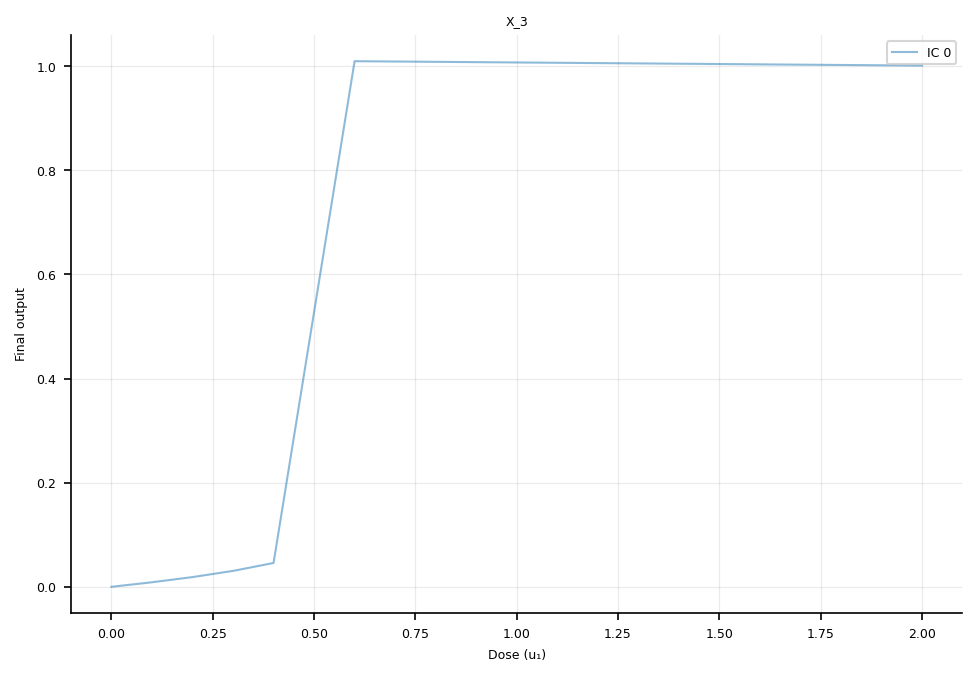

Task: dose_response
time_horizon: (1000,) [0..100.0]
num scenarios: 10
first 3 u: [array([0.], dtype=float32), array([0.1], dtype=float32), array([0.2], dtype=float32)]

[run 1] Loaded 30 CRNs from hall_of_fame_2026-01-12 09:03:08.pth
[run 1] Resimulated HoF CRNs: 30
Saved checkpoint: /local0/rossin/git/CRN-GenerativeAI/apps_zhou/apps_zhou/Biphasic_response/Biphasic_response_run1.pkl
[run 1] Saved trainer checkpoint -> /local0/rossin/git/CRN-GenerativeAI/apps_zhou/apps_zhou/Biphasic_response/Biphasic_response_run1.pkl
Best CRN loss: 0.013801783266007143
Inputs: ['u_1'] 
Species: ['X_1', 'X_2', 'X_3'] 
Output Species: ['X_3'] 
∅ ----> X_1;  [MAK(1.0, u_1)]
X_1 ----> ∅;  [MAK(1.0)]
X_1 ----> X_3 + X_3;  [MAK(0.7918193340301514)]
X_2 ----> ∅;  [MAK(1.0)]
X_3 ----> ∅;  [MAK(1.0)]
X_3 ----> X_2 + X_2;  [MAK(34.95685577392578)]
X_1 + X_2 ----> X_1 + X_3;  [MAK(1.7771320343017578)]
X_1 + X_3 ----> X_1 + X_1;  [MAK(1.7796776294708252)]
X_2 + X_3 ----> X_1 + X_2;  [MAK(1.8197193145751953)]


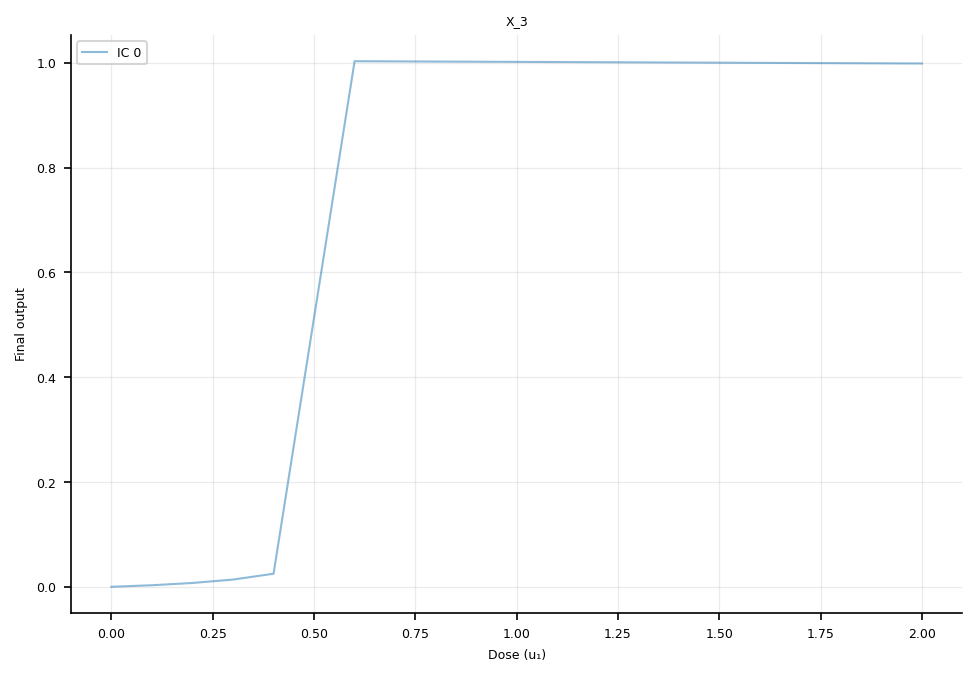

Task: dose_response
time_horizon: (1000,) [0..100.0]
num scenarios: 10
first 3 u: [array([0.], dtype=float32), array([0.1], dtype=float32), array([0.2], dtype=float32)]

[run 2] Loaded 30 CRNs from hall_of_fame_2026-01-12 11:00:56.pth
[run 2] Resimulated HoF CRNs: 30
Saved checkpoint: /local0/rossin/git/CRN-GenerativeAI/apps_zhou/apps_zhou/Biphasic_response/Biphasic_response_run2.pkl
[run 2] Saved trainer checkpoint -> /local0/rossin/git/CRN-GenerativeAI/apps_zhou/apps_zhou/Biphasic_response/Biphasic_response_run2.pkl
Best CRN loss: 0.04794247810867456
Inputs: ['u_1'] 
Species: ['X_1', 'X_2', 'X_3'] 
Output Species: ['X_3'] 
∅ ----> X_1;  [MAK(1.0, u_1)]
X_1 ----> ∅;  [MAK(1.0)]
X_2 ----> ∅;  [MAK(1.0)]
X_2 ----> X_2 + X_3;  [MAK(1.043515682220459)]
X_3 ----> ∅;  [MAK(1.0)]
X_3 ----> X_1 + X_1;  [MAK(1.1270564794540405)]
X_1 + X_1 ----> X_1 + X_2;  [MAK(1.1338554620742798)]
X_1 + X_2 ----> X_2 + X_3;  [MAK(0.945472002029419)]
X_2 + X_3 ----> X_2 + X_2;  [MAK(1.0572662353515625)]


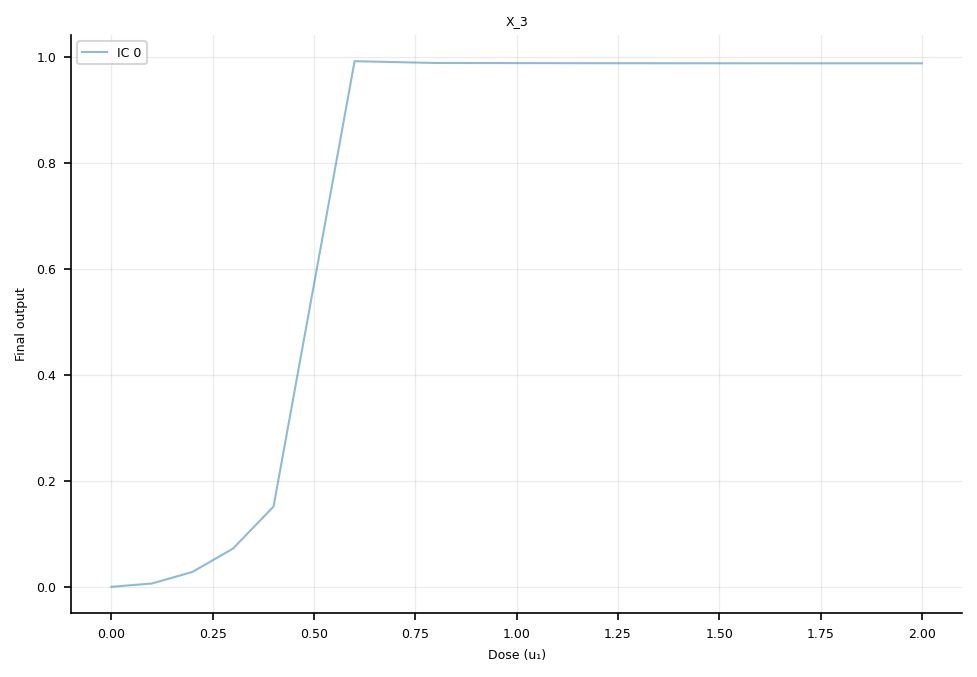

In [19]:
"""
RL4CRN converter script (new interface)
Task: Dose-response (Biphasic / Ultra-sensitivity Hill n=20)

Folder:
  /local0/rossin/git/CRN-GenerativeAI/apps_zhou/apps_zhou/Biphasic_response

What it does:
- For each hof/hall_of_fame_*.pth file in target_directory:
  1) builds a NEW-interface dose_response trainer (CVODE rtol=atol=1e-10)
  2) loads old HoF CRNs from that file
  3) injects them into trainer.s.mult_env.hall_of_fame
  4) resimulates the entire HoF under the NEW task and REPLACES HoF
  5) saves checkpoint: <folder_basename>_run{i}.pkl
  6) writes <folder_basename>_run{i}.meta.json
  7) plots the best CRN at the end of each run (dose-response + transients if available)
"""

import os
import glob
import json
import copy
import torch
import numpy as np

# IMPORTANT: register TaskKinds
from RL4CRN.utils import default_tasks  # noqa: F401

from RL4CRN.utils.input_interface import (
    Configurator,
    make_task,
    make_session_and_trainer,
    print_task_summary,
)

from RL4CRN.utils.crn_builders import build_simple_IOCRN
from RL4CRN.utils.library_builders import build_MAK_library


# -------------------------
# 1) TASK-SPECIFIC SETTINGS
# -------------------------
target_directory = "/local0/rossin/git/CRN-GenerativeAI/apps_zhou/apps_zhou/Biphasic_response"

preset = "paper"

species_labels = ["X_1", "X_2", "X_3"]
mak_order = 2

max_added_reactions = 5
seed = 0

t_f = 100
n_t = 1000

ic_spec = ("values", [[0.0, 0.0, 0.0]])
weights_spec = "transient"

# chosen_u_values for n=20 case (from your snippet)
chosen_u_values = [0.0, 0.1, 0.2, 0.3, 0.4, 0.6, 0.8, 1.2, 1.6, 2.0]
u_list_custom = [np.array([u], dtype=np.float32) for u in chosen_u_values]

def hill_function(u: float) -> float:
    kd = 0.5
    max_production = 1.0
    n = 20.0
    # handle u=0 safely
    u = float(u)
    if u <= 0.0:
        return 0.0
    return float(max_production * (u**n) / (kd**n + u**n))

TASK_TAG = "dose_response_biphasic_hill_n20"


# -------------------------
# 2) Generic helpers (HoF loading + injection)
# -------------------------
def _extract_crn(obj):
    if hasattr(obj, "state"):
        crn = obj.state
        rew = None
        if hasattr(obj, "reward"):
            rew = getattr(obj, "reward")
        elif hasattr(obj, "perf"):
            rew = getattr(obj, "perf")
        return crn, rew

    if isinstance(obj, tuple) and len(obj) >= 1:
        crn = obj[0]
        rew = obj[1] if len(obj) > 1 else None
        return crn, rew

    if isinstance(obj, dict):
        for k in ["state", "crn", "iocrn"]:
            if k in obj:
                crn = obj[k]
                rew = obj.get("reward", obj.get("perf", None))
                return crn, rew

    return obj, None


def load_old_hof_file(hof_file: str, map_location: str = "cpu"):
    data = torch.load(hof_file, map_location=map_location, weights_only=False)
    crns = []
    for entry in data:
        crn, rew = _extract_crn(entry)
        if crn is None:
            continue
        if getattr(crn, "last_task_info", None) is None:
            crn.last_task_info = {}
        if rew is not None:
            crn.last_task_info["reward"] = float(rew)
        crns.append(crn)
    return crns


class _EnvStateWrapper:
    def __init__(self, state):
        self.state = state


def _safe_copy_last_task_info(info):
    if info is None:
        return {}
    try:
        return copy.deepcopy(info)
    except Exception:
        out = dict(info)
        for k, v in list(out.items()):
            if isinstance(v, np.ndarray):
                out[k] = v.copy()
        return out


def patch_solver_fields(crns, template_crn):
    for c in crns:
        for attr in ["solver", "rtol", "atol"]:
            if hasattr(template_crn, attr) and not hasattr(c, attr):
                try:
                    setattr(c, attr, getattr(template_crn, attr))
                except Exception:
                    pass


def inject_hof(trainer, crns, max_size=None):
    if max_size is None:
        max_size = int(getattr(trainer.s.cfg.train, "hall_of_fame_size", len(crns)))

    task = trainer.s.task

    def loss_of(crn):
        info = getattr(crn, "last_task_info", {}) or {}
        r = info.get("reward", None)
        return float(r) if r is not None else float("inf")

    crns_sorted = sorted(crns, key=loss_of)[:max_size]

    for c in crns_sorted:
        old_info = getattr(c, "last_task_info", None)
        c.last_task_info = _safe_copy_last_task_info(old_info)

        c.last_task_info["u_list"] = task.u_list
        c.last_task_info["time_horizon"] = task.time_horizon
        c.last_task_info["task_kind"] = task.kind

        if "reward" not in c.last_task_info and old_info is not None:
            try:
                if "reward" in old_info:
                    c.last_task_info["reward"] = float(old_info["reward"])
            except Exception:
                pass

    trainer.s.mult_env.hall_of_fame = [_EnvStateWrapper(c) for c in crns_sorted]


def resimulate_whole_hof_and_replace(trainer):
    hof_crns = [item.state for item in trainer.s.mult_env.hall_of_fame]
    if not hof_crns:
        return []

    patch_solver_fields(hof_crns, trainer.s.task.template_crn)

    task = trainer.s.task
    crns_new = trainer.resimulate(
        hof_crns,
        ic=task.ic_spec,
        weights=task.weights_spec,
        u_list=task.u_list,
    )

    wrapped = []
    for c in crns_new:
        if getattr(c, "last_task_info", None) is None:
            c.last_task_info = {}
        c.last_task_info["u_list"] = task.u_list
        c.last_task_info["time_horizon"] = task.time_horizon
        c.last_task_info["task_kind"] = task.kind
        wrapped.append(_EnvStateWrapper(c))

    trainer.s.mult_env.hall_of_fame = wrapped
    return crns_new


# -------------------------
# 3) Build trainer (new interface)
# -------------------------
def build_trainer_for_biphasic_hill_n20():
    cfg = Configurator.preset(preset)

    # tight tolerances
    cfg.solver.algorithm = "CVODE"
    cfg.solver.rtol = 1e-10
    cfg.solver.atol = 1e-10

    cfg.train.max_added_reactions = max_added_reactions
    cfg.train.epochs = 1
    cfg.train.seed = seed

    # template IOCRN matching old: production_input_map X1 <- u1, output X3
    crn, species_out = build_simple_IOCRN(
        species=species_labels,
        production_input_map={"X_1": "u_1"},
        degradation_input_map={},
        dilution_map={},
        output_species="X_3",
        solver=cfg.solver,
    )

    library_components = build_MAK_library(crn, species_out, order=mak_order)

    # dose-response task:
    task = make_task(
        template_crn=crn,
        library_components=library_components,
        kind="dose_response",
        species_labels=species_out,
        params={
            "t_f": t_f,
            "n_t": n_t,
            "ic": ic_spec,
            "weights": weights_spec,
            "u_spec": ("custom", u_list_custom),            # exact u_list from old
            "target": (lambda u_1: hill_function(u_1)),     # hill n=20
            "norm": 1,
            "LARGE_NUMBER": 1e4,
            "relative": False,
        },
    )

    print_task_summary(task)
    trainer = make_session_and_trainer(cfg, task, logger=None)
    return trainer


# -------------------------
# 4) Conversion: ONE trainer per HoF file
# -------------------------
def convert_one_app_many_trainers(target_directory: str):
    hof_dir = os.path.join(target_directory, "hof")
    hof_files = sorted(glob.glob(os.path.join(hof_dir, "hall_of_fame_*.pth")))
    if not hof_files:
        raise FileNotFoundError(f"No HoF files found: {os.path.join(hof_dir, 'hall_of_fame_*.pth')}")

    base = os.path.basename(os.path.normpath(target_directory))
    trainers = []

    for i, hof_file in enumerate(hof_files):
        trainer = build_trainer_for_biphasic_hill_n20()

        crns = load_old_hof_file(hof_file, map_location="cpu")
        print(f"[run {i}] Loaded {len(crns)} CRNs from {os.path.basename(hof_file)}")

        inject_hof(trainer, crns, max_size=trainer.s.cfg.train.hall_of_fame_size)

        crns_resim = resimulate_whole_hof_and_replace(trainer)
        print(f"[run {i}] Resimulated HoF CRNs: {len(crns_resim)}")

        ckpt_path = os.path.join(target_directory, f"{base}_run{i}.pkl")
        trainer.save(ckpt_path)

        meta = {
            "target_directory": target_directory,
            "hof_file": hof_file,
            "n_loaded_crns": len(crns),
            "n_resimulated_crns": len(crns_resim),
            "task_tag": TASK_TAG,
            "preset": preset,
            "species_labels": species_labels,
            "mak_order": mak_order,
            "t_f": t_f,
            "n_t": n_t,
            "ic": ic_spec,
            "weights": weights_spec,
            "chosen_u_values": chosen_u_values,
            "max_added_reactions": max_added_reactions,
            "seed": seed,
            "checkpoint_path": ckpt_path,
            "run_index": i,
        }
        with open(os.path.join(target_directory, f"{base}_run{i}.meta.json"), "w") as f:
            json.dump(meta, f, indent=2)

        print(f"[run {i}] Saved trainer checkpoint -> {ckpt_path}")

        # Plot best at end (dose-response plots should now be populated)
        try:
            import matplotlib.pyplot as plt

            trainer.inspect_best(plot=True)
            plt.show()
        except Exception as e:
            print(f"[run {i}] Plot failed (non-fatal): {e}")

        trainers.append(trainer)

    return trainers


if __name__ == "__main__":
    convert_one_app_many_trainers(target_directory)